# Tour Navigator PCA·코사인 통합 분석

주 분석 엔진 integrated-5.0 — 지출업종 분류 제거, 전국 해양 입력 반영. CSV 입력부터 전처리·PCA·유클리드 및 구면 코사인 군집·지역 지출 회귀·해양 분석·PNG/CSV 저장까지 실행합니다.

현재 분기형 설문 6.1 및 추천 참조 계산 6.2는 `../reference_calc/`를 사용합니다. 상세 문서는 `../docs/Tour_Navigator_Integrated_Specification.md`입니다. 이 노트북의 직접 5범주 평점은 별도 검증 입력이며, 미입력 시 가상 응답 4개를 사용합니다. 최신 설문 문항에는 포함되지 않습니다. 기존 Q/H/D 산식 비교는 상위 `run_session.py`와 `tour_scoring/`에 보존되어 있습니다.

원래 분석 코드 셀과 저장된 실행 출력은 유지했습니다. `analysis` 폴더에서 Restart Kernel → Run All 하세요.


## 1 실행 설정
기본 파일명은 그대로 사용해도 됩니다. Windows 경로는 `r"C:\Users\사용자\Downloads\tour-places.csv"`처럼 입력하세요. `None`은 해당 입력을 사용하지 않는다는 뜻입니다. 분석 패키지를 먼저 설치한 뒤 실행하세요. 기본 `AUTO_INSTALL=False`이며 부족한 패키지는 오류 메시지로 안내합니다. 설치가 완료되면 분석은 인터넷 없이 동작합니다.


In [1]:
from pathlib import Path
PLACES_CSV = Path("tour-places.csv")  # 여행장소 파일 또는 None
CITYTOUR_CSV = Path("citytour.csv")  # 시티투어 파일 또는 None
OUTPUT_ROOT = Path("outputs_cosine")
AUTO_INSTALL = False
PCA_TARGET = 0.95
K_MAX = 10
SEEDS = [42, 7, 19]
N_INIT = 20
MIN_CLUSTER_SHARE = 0.02
MIN_SEED_ARI = 0.80
SILHOUETTE_SAMPLE = 1200
MIN_CITY_CATEGORY_COVERAGE = 0.50
PLACE_WEIGHTS = {"category": 0.60, "stay": 0.30, "unesco_mark": 0.10}
CITY_WEIGHTS = {"category": 0.75, "stop_count": 0.15, "night": 0.10}

# 지역 지출 비율 CSV가 있는 폴더 또는 ZIP
SPENDING_INPUT = Path("spending_csv")
REGRESSION_ALPHAS = [0.1, 1.0, 10.0, 100.0, 1000.0]
MIN_CATALOG_PLACES = 3

MARINE_INPUT = Path("marine_csv")  # 해양 기본 CSV 3개 + 선택 검색순위 CSV 폴더 또는 다운로드 ZIP, 제외 시 None
MARINE_RATIO_TOLERANCE_PP = 0.01
MARINE_MEAN_TOLERANCE = 1.0  # 정수 반올림 평균 비교 허용차

# 코사인 확장 설정
COSINE_N_INIT = 20
COSINE_MAX_ITER = 200
SURVEY_CSV = Path("survey_responses.csv")  # 없으면 명시적 가상 설문 시연


In [2]:
import importlib.util, subprocess, sys
required = {"numpy":"numpy>=1.26,<3", "pandas":"pandas>=2.2,<4",
            "matplotlib":"matplotlib>=3.8,<4", "sklearn":"scikit-learn>=1.5,<2",
            "joblib":"joblib>=1.3,<2", "threadpoolctl":"threadpoolctl>=3,<4"}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    if not AUTO_INSTALL:
        raise RuntimeError("현재 커널에 설치할 패키지: " + " ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import os, io, re, json, hashlib, unicodedata, platform, itertools, warnings
from datetime import datetime
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, pairwise_distances
from threadpoolctl import threadpool_limits
import sklearn, joblib

RUN_DIR = OUTPUT_ROOT / datetime.now().strftime("run_%Y%m%d_%H%M%S_%f")
TABLES, PLOTS, MODELS = [RUN_DIR / name for name in ("tables", "plots", "models")]
for folder in (TABLES, PLOTS, MODELS): folder.mkdir(parents=True, exist_ok=True)
for candidate in ["C:/Windows/Fonts/malgun.ttf", "/usr/share/fonts/opentype/task-noto/NotoSansCJKkr-Regular.otf", "/usr/local/share/fonts/task-droid/DroidSansFallback.ttf"]:
    if Path(candidate).exists(): font_manager.fontManager.addfont(candidate)
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
font = next((f for f in ["Malgun Gothic", "AppleGothic", "Noto Sans CJK KR", "NanumGothic", "Droid Sans Fallback"] if f in available_fonts), "DejaVu Sans")
plt.rcParams.update({"font.family":font, "axes.unicode_minus":False, "font.size":10,
                     "axes.spines.top":False, "axes.spines.right":False,
                     "figure.facecolor":"white", "axes.titleweight":"bold"})
PALETTE = ["#D8A900", "#3475B5", "#C9495B", "#7B60A3", "#B97991", "#758B7C", "#899BB0", "#9A6C4C", "#D9A6BA", "#50555A"]
CATEGORIES = ["herit", "heal", "activity", "food", "sea"]
CAT_LABELS = {"herit":"Heritage", "heal":"Nature", "activity":"Activity", "food":"Food", "sea":"Coast", "stay":"Lodging"}
INPUT_META, PLOT_FILES, RUN_SUMMARY = {}, [], {}

def show_table(df, n=12):
    try: display(df.head(n))
    except NameError: print(df.head(n).to_string(index=False))

def save_csv(df, name, index=False):
    path = TABLES / (name + ".csv")
    df.to_csv(path, index=index, encoding="utf-8-sig")
    return path

def finish(fig, name):
    fig.tight_layout()
    path = PLOTS / (name + ".png")
    # Finish the image in memory before writing, including on synced folders.
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=300, bbox_inches="tight", facecolor="white")
    path.write_bytes(buffer.getvalue())
    PLOT_FILES.append(path)
    plt.show()
    plt.close(fig)

def read_csv_input(path, kind):
    if path is None or not Path(path).is_file():
        print(f"{kind}: 파일 없음, 이 입력 분석을 건너뜁니다. 설정값={path}")
        return None
    path = Path(path)
    for encoding in ["utf-8-sig", "cp949", "utf-16"]:
        try:
            frame = pd.read_csv(path, encoding=encoding, dtype=str, keep_default_na=False)
            frame.columns = [c.strip().lstrip("\ufeff") for c in frame.columns]
            INPUT_META[kind] = {"file":str(path), "sha256":hashlib.sha256(path.read_bytes()).hexdigest(),
                                "encoding":encoding, "rows":len(frame), "columns":frame.columns.tolist()}
            print(f"{kind}: {len(frame):,}행 × {len(frame.columns)}열 / {encoding}")
            return frame
        except UnicodeError:
            continue
    raise ValueError(f"인코딩을 읽을 수 없습니다. UTF-8 CSV로 다시 저장하세요: {path}")

def standard_columns(df, mapping, required_columns):
    result = pd.DataFrame(index=df.index)
    for target, aliases in mapping.items():
        source = next((c for c in aliases if c in df.columns), None)
        if source is not None: result[target] = df[source].astype(str).str.strip()
        elif target in required_columns: raise ValueError(f"필수 칼럼 누락: {target}; 허용 이름={aliases}")
        else: result[target] = ""
    return result

def robust_log(values):
    z = np.log1p(np.asarray(values, dtype=float))
    median = float(np.median(z))
    q25, q75 = np.quantile(z, [0.25, 0.75])
    scale = float(q75-q25)
    if scale < 1e-12: scale = float(np.std(z)) or 1.0
    return (z-median)/scale, {"log1p_median":median, "scale":scale, "fallback":"std_then_1_if_IQR_zero"}

places_raw = read_csv_input(PLACES_CSV, "places")
cities_raw = read_csv_input(CITYTOUR_CSV, "citytour")
if places_raw is None and cities_raw is None and (SPENDING_INPUT is None or not Path(SPENDING_INPUT).exists()) and (MARINE_INPUT is None or not Path(MARINE_INPUT).exists()):
    raise FileNotFoundError("장소·코스 CSV, 지출 입력, 해양 입력 중 하나 이상을 첫 설정 셀에서 지정하세요.")
print("Python", platform.python_version(), "| scikit-learn", sklearn.__version__)
print("저장 폴더:", RUN_DIR.resolve())


places: 3,118행 × 17열 / utf-8-sig
citytour: 280행 × 13열 / utf-8-sig
Python 3.12.14 | scikit-learn 1.8.0
저장 폴더: /workspace/scratch/6640d64d17c6/deliverables/integrated_release/Tour_Navigator_Codebook/analysis/outputs_cosine/run_20260928_062724_468322


## 2 여행장소 전처리와 입력 변수
원본 행은 전체 결과표에 모두 남깁니다. 숙박, 미지원 분류, 누락·0 이하 기본시간은 G학습에서 제외하고 사유를 기록합니다. ID 누락·중복은 오류로 중단합니다. 위경도 결측은 위치 그림에서만 제외하며 군집 특성에는 좌표를 넣지 않습니다.

$$X_G=[\sqrt{0.60/2}\,I_\mathrm{herit},\ldots,\sqrt{0.60/2}\,I_\mathrm{sea},\sqrt{0.30}\,R(\log(1+B)),\sqrt{0.10}\,U]$$

$R(z)=(z-\operatorname{median}(z))/\operatorname{IQR}(z)$이며 IQR=0일 때 표준편차, 둘 다 0이면 1로 나눕니다. $U$는 **CSV에 Y라고 표시되었는지**입니다. 공란은 '유네스코 아님'을 검증한 값이 아니라 **표시 없음=0**이라는 코딩입니다. 가중치는 설계값이며 통계에서 추정한 중요도가 아닙니다. 가중치가 합쳐서 1이라고 해서 실제 분산 기여가 60/30/10%가 되는 것은 아닙니다.

원본에 유네스코 열이 전혀 없거나 특정 변수가 상수이면 그 변수는 제거합니다. 숙박을 분석하려면 별도 숙박 목적·시간 변수로 모델을 새로 설계하는 것이 적절합니다.


item,count
All rows,3118
Eligible,2549
Excluded,569
Invalid base time,1
Invalid/missing coordinates,0


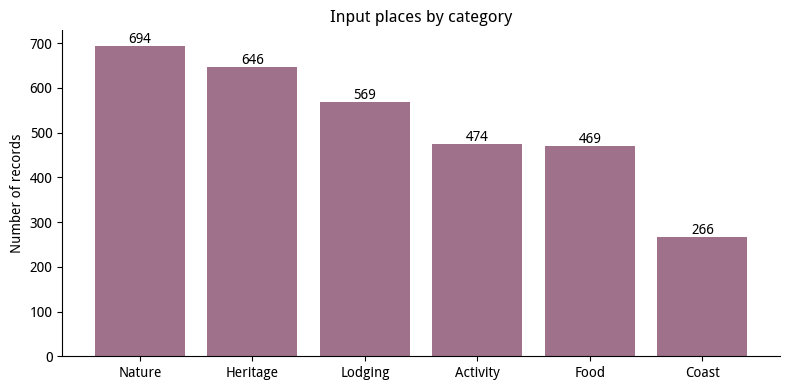

In [3]:
places, place_model, place_features, place_preprocess = None, None, None, None
if places_raw is not None:
    mapping = {"place_id":["id","place_id"], "region":["지역","region_name","region"],
               "name":["이름(한국어)","place_name","name"], "category":["카테고리","category"],
               "base_minutes":["추천 체류(분)","base_minutes"], "lat":["위도","lat"], "lon":["경도","lon"],
               "unesco_raw":["유네스코","badge_unesco"]}
    places = standard_columns(places_raw, mapping, {"place_id","region","name","category","base_minutes"})
    if places.place_id.eq("").any() or places.place_id.duplicated().any():
        save_csv(places[places.place_id.eq("") | places.place_id.duplicated(False)], "place_id_errors")
        raise ValueError("장소 ID가 비었거나 중복입니다. place_id_errors.csv를 확인하세요.")
    for col in ["base_minutes","lat","lon"]:
        places[col] = pd.to_numeric(places[col], errors="coerce").replace([np.inf,-np.inf],np.nan)
    places["unesco_mark"] = places.unesco_raw.str.upper().isin(["Y","YES","1","TRUE"]).astype(int)
    places["quality_reason"] = ""
    places.loc[places.category.eq("stay"),"quality_reason"] = "LODGING_EXCLUDED"
    places.loc[~places.category.isin(CATEGORIES+["stay"]),"quality_reason"] = "UNKNOWN_CATEGORY"
    missing_time = ~places.base_minutes.gt(0)
    places["base_time_missing_or_invalid"] = missing_time
    places.loc[missing_time & places.quality_reason.eq(""),"quality_reason"] = "BASE_TIME_MISSING_OR_NONPOSITIVE"
    places["cluster_eligible"] = places.quality_reason.eq("")
    places["coordinate_valid"] = places.lat.between(-90,90) & places.lon.between(-180,180)
    eligible_places = places.loc[places.cluster_eligible].copy()
    save_csv(places, "place_cleaned_all")
    save_csv(places[~places.cluster_eligible], "place_excluded")
    audit = pd.DataFrame({"item":["All rows","Eligible","Excluded","Invalid base time","Invalid/missing coordinates"],
                          "count":[len(places),len(eligible_places),int((~places.cluster_eligible).sum()),int(missing_time.sum()),int((~places.coordinate_valid).sum())]})
    show_table(audit); save_csv(audit,"place_quality_summary")
    if len(eligible_places) < 4: raise ValueError("유효한 비숙박 장소가 4행 이상 필요합니다.")
    scaled_stay, stay_parameters = robust_log(eligible_places.base_minutes)
    place_features = pd.DataFrame({f"cat_{c}":eligible_places.category.eq(c).astype(float)*np.sqrt(PLACE_WEIGHTS["category"]/2) for c in CATEGORIES}, index=eligible_places.index)
    place_features["log_stay_robust"] = scaled_stay*np.sqrt(PLACE_WEIGHTS["stay"])
    place_features["unesco_mark"] = eligible_places.unesco_mark*np.sqrt(PLACE_WEIGHTS["unesco_mark"])
    place_preprocess = {"weights":PLACE_WEIGHTS, "stay":stay_parameters, "unesco_rule":"marked 1; blank/unmarked 0, not verified absence", "categories":CATEGORIES}
    fig,ax=plt.subplots(figsize=(8,4))
    counts=places.category.value_counts();ax.bar([CAT_LABELS.get(c,c) for c in counts.index],counts.values,color="#9F718B")
    ax.set(title="Input places by category",ylabel="Number of records")
    for i,v in enumerate(counts.values): ax.text(i,v,str(v),ha="center",va="bottom")
    finish(fig,"01_place_categories")


## 3 PCA와 군집 수 비교 함수
PCA는 **전처리된 입력을 평균 중심화**하여 분산이 큰 축부터 계산합니다. 축 이름을 '연령'이나 '한류'로 미리 설정하지 않습니다.

$$PC_j(i)=\sum_f (X_{if}-\overline X_f)\,v_{jf}$$

`pca_axes.csv`는 $v_{jf}$ 축 계수, `pca_input_means.csv`는 중심값, `pca_variance.csv`는 설명분산을 저장합니다. 실제 군집은 누적 설명력 95% 이상의 **모든 선택 성분**에서 학습하며 PC1·PC2 그림은 투영입니다. 축 부호는 뒤집힐 수 있고 군집 번호는 분석 간 고정 ID가 아닙니다.

각 k=2~10에서 시드 3개·각 20회 초기화로 학습합니다. 원특성 공간과 PCA 공간을 모두 비교하되 **대표 모델은 PCA 후보에서** 선택합니다. 실루엣은 두 모드 모두 같은 원특성 거리와 같은 표본에서 평가합니다. 최소 군집 비율 2%·시드 간 최소 ARI 0.8을 통과한 후보 중 평균 실루엣 최대를 고릅니다. 조건을 통과하지 못하면 최선 후보를 탐색용으로 표시합니다. 실루엣·ARI는 추천 정확도 검증이 아닙니다.


In [4]:
def fit_cluster_pipeline(feature_frame, prefix, preprocess, k_max=None, min_cluster_share=None):
    k_max = K_MAX if k_max is None else k_max
    min_cluster_share = MIN_CLUSTER_SHARE if min_cluster_share is None else min_cluster_share
    constant = feature_frame.columns[feature_frame.std(ddof=0).le(1e-12)].tolist()
    F = feature_frame.drop(columns=constant)
    X = F.to_numpy(float)
    if not np.isfinite(X).all() or X.shape[1] == 0: raise ValueError(f"{prefix}: 유효한 비상수 특성이 없습니다.")
    unique_n = len(np.unique(np.round(X,12),axis=0))
    max_k = min(k_max,len(X)-1,unique_n-1)
    if max_k < 2: raise ValueError(f"{prefix}: 서로 다른 특성 조합이 최소 3개 필요합니다.")
    pca = PCA(svd_solver="full",whiten=False).fit(X)
    all_pc = pca.transform(X)
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    m = min(len(cumulative),int(np.searchsorted(cumulative,PCA_TARGET)+1))
    Z = all_pc[:,:m]
    sample = np.sort(np.random.default_rng(SEEDS[0]).choice(len(X), min(len(X),SILHOUETTE_SAMPLE), replace=False))
    with threadpool_limits(limits=2):
        distances = pairwise_distances(X[sample]); np.fill_diagonal(distances,0)
        rows=[]
        for mode,training in [("raw",X),("pca",Z)]:
            for k in range(2,max_k+1):
                labels_all=[];sils=[];min_shares=[];inertias=[]
                for seed in SEEDS:
                    model=KMeans(n_clusters=k,n_init=N_INIT,random_state=seed,algorithm="lloyd").fit(training)
                    labels=model.labels_;labels_all.append(labels)
                    sampled_labels=labels[sample]
                    sil=silhouette_score(distances,sampled_labels,metric="precomputed") if 1<len(np.unique(sampled_labels))<len(sample) else np.nan
                    sils.append(sil);min_shares.append(np.bincount(labels,minlength=k).min()/len(labels));inertias.append(model.inertia_)
                ari=min(adjusted_rand_score(a,b) for a,b in itertools.combinations(labels_all,2))
                rows.append({"mode":mode,"k":k,"components":training.shape[1],"silhouette_mean":float(np.nanmean(sils)),
                             "silhouette_sd":float(np.nanstd(sils)),"seed_ari_min":float(ari),"min_cluster_share":float(min(min_shares)),
                             "inertia_mean_in_training_space":float(np.mean(inertias))})
    comparison=pd.DataFrame(rows)
    comparison["passes_gates"]=(comparison.seed_ari_min>=MIN_SEED_ARI)&(comparison.min_cluster_share>=min_cluster_share)
    pool=comparison[comparison["mode"].eq("pca") & comparison.passes_gates]
    gates_passed=not pool.empty
    if pool.empty: pool=comparison[comparison["mode"].eq("pca")]
    selected=pool.sort_values(["silhouette_mean","k"],ascending=[False,True]).iloc[0]
    with threadpool_limits(limits=2):
        model=KMeans(n_clusters=int(selected.k),n_init=N_INIT,random_state=SEEDS[0],algorithm="lloyd").fit(Z)
    # A deterministic within-run numbering rule. Not semantic identities across datasets.
    order=sorted(range(int(selected.k)),key=lambda lab:tuple(np.mean(X[model.labels_==lab],axis=0).round(10)))
    label_map={lab:f"{prefix}{i+1:02d}" for i,lab in enumerate(order)}
    labels=np.array([label_map[lab] for lab in model.labels_])
    pcs=pd.DataFrame(all_pc,columns=[f"PC{i+1}" for i in range(all_pc.shape[1])],index=F.index)
    axes=pd.DataFrame(pca.components_.T,index=F.columns,columns=pcs.columns)
    variance=pd.DataFrame({"component":pcs.columns,"explained_variance_ratio":pca.explained_variance_ratio_,"cumulative":cumulative})
    save_csv(F.assign(source_index=F.index),f"{prefix}_features")
    save_csv(comparison,f"{prefix}_model_comparison")
    save_csv(axes.rename_axis("feature").reset_index(),f"{prefix}_pca_axes")
    save_csv(pd.DataFrame({"feature":F.columns,"mean":pca.mean_}),f"{prefix}_pca_input_means")
    save_csv(variance,f"{prefix}_pca_variance")
    save_csv(pcs.assign(source_index=pcs.index),f"{prefix}_pca_scores")
    summary={"rows":len(X),"features":F.columns.tolist(),"removed_constant_features":constant,"pca_components":m,
             "pca_retained_variance":float(cumulative[m-1]),"plot_2pc_variance":float(cumulative[min(1,len(cumulative)-1)]),
             "k":int(selected.k),"silhouette_mean":float(selected.silhouette_mean),"seed_ari_min":float(selected.seed_ari_min),
             "passes_gates":gates_passed,"silhouette_sample_size":len(sample),"numbering":"run-specific, no persona assignment"}
    bundle={"preprocess":preprocess,"features":F.columns.tolist(),"pca":pca,"components_used":m,"kmeans":model,"label_map":label_map,"summary":summary,"sklearn_version":sklearn.__version__}
    joblib.dump(bundle,MODELS/f"{prefix}_pca_kmeans.joblib")
    print(prefix,json.dumps(summary,ensure_ascii=False,indent=2))
    for axis in axes.columns[:2]:
        signed=axes[axis].sort_values()
        print(axis,"negative:",signed.head(2).round(4).to_dict(),"positive:",signed.tail(2).round(4).to_dict())
    dominant=axes.PC1.abs().idxmax()
    if abs(axes.loc[dominant,"PC1"])>=0.9:
        print(f"축 해석: PC1 계수의 절댓값이 가장 큰 변수는 {dominant}입니다. 단일 변수의 영향이 크므로 테마 성향이나 여행자 유형으로 바로 해석하지 마세요.")
    if int(selected.k)==max_k:
        print(f"군집 수 해석: k={max_k}는 이번 탐색의 상한입니다. 전역 최적 군집 수가 확정된 것은 아닙니다.")
    return {"F":F,"X":X,"Z":Z,"labels":labels,"pcs":pcs,"axes":axes,"variance":variance,"comparison":comparison,
            "model":model,"pca":pca,"summary":summary,"prefix":prefix}

def plot_diagnostics(result, start):
    prefix=result["prefix"];v=result["variance"];c=result["comparison"];s=result["summary"]
    fig,ax=plt.subplots(figsize=(8,4));axis=np.arange(1,len(v)+1)
    ax.bar(axis,v.explained_variance_ratio,color="#AD7B93",label="Individual")
    ax.plot(axis,v.cumulative,"o-",color="#6A4E85",label="Cumulative");ax.axhline(PCA_TARGET,color="#555",ls="--",label=f"Target {PCA_TARGET:.0%}")
    ax.set(xticks=axis,ylim=(0,1.06),xlabel="Principal component",ylabel="Explained variance ratio",title=f"{prefix}: PCA variance (retained {s['pca_components']} PCs)");ax.legend(frameon=False)
    finish(fig,f"{start:02d}_{prefix}_pca_variance")
    fig,axs=plt.subplots(1,2,figsize=(11,4))
    for mode,color in [("raw","#888888"),("pca","#A94B74")]:
        q=c[c["mode"].eq(mode)];axs[0].errorbar(q.k,q.silhouette_mean,yerr=q.silhouette_sd,marker="o",label=mode,color=color)
        axs[1].plot(q.k,q.seed_ari_min,"o-",label=mode,color=color)
    axs[0].set(title="Silhouette on common feature distances",xlabel="k",ylabel="Mean silhouette");axs[0].axvline(s["k"],ls=":",color="#333")
    axs[1].axhline(MIN_SEED_ARI,ls="--",color="#555");axs[1].set(title="Stability across seeds",xlabel="k",ylabel="Minimum ARI",ylim=(-.05,1.05))
    for ax in axs:ax.legend(frameon=False);ax.set_xticks(sorted(c.k.unique()))
    finish(fig,f"{start+1:02d}_{prefix}_model_comparison")
    xy=result["pcs"].iloc[:,:2].copy()
    if xy.shape[1]==1: xy["PC2"]=0.0
    xy.columns=["PC1","PC2"];xy["cluster"]=result["labels"]
    # Aggregate exactly coincident points. No artificial coordinate jitter.
    xy[["PC1","PC2"]]=xy[["PC1","PC2"]].round(8)
    grouped=xy.groupby(["PC1","PC2","cluster"]).size().reset_index(name="count")
    fig,ax=plt.subplots(figsize=(9,6))
    for i,label in enumerate(sorted(xy.cluster.unique())):
        q=grouped[grouped.cluster.eq(label)];ax.scatter(q.PC1,q.PC2,s=18+q["count"]*2,alpha=.72,color=PALETTE[i%len(PALETTE)],label=label,edgecolor="white",linewidth=.35)
    vr=result["pca"].explained_variance_ratio_
    ax.set(xlabel=f"PC1 ({vr[0]:.1%})",ylabel=f"PC2 ({vr[1] if len(vr)>1 else 0:.1%})",
           title=f"{prefix}: PCA projection, k={s['k']} (model uses {s['pca_components']} PCs)")
    ax.legend(bbox_to_anchor=(1.02,1),loc="upper left",frameon=False,title="Cluster");ax.text(0,-.15,"Marker area = 18 + 2 × coincident records; no jitter",transform=ax.transAxes,fontsize=9,color="#555")
    finish(fig,f"{start+2:02d}_{prefix}_pca_clusters")
    axes=result["axes"].iloc[:,:min(5,len(result["axes"].columns))]
    fig,ax=plt.subplots(figsize=(8,5));im=ax.imshow(axes,cmap="RdBu_r",vmin=-1,vmax=1,aspect="auto")
    ax.set(xticks=np.arange(axes.shape[1]),xticklabels=axes.columns,yticks=np.arange(len(axes)),yticklabels=axes.index,title=f"{prefix}: PCA axis coefficients")
    for i in range(len(axes)):
        for j in range(axes.shape[1]):ax.text(j,i,f"{axes.iloc[i,j]:.2f}",ha="center",va="center",color="white" if abs(axes.iloc[i,j])>.6 else "black",fontsize=9)
    fig.colorbar(im,ax=ax,label="Axis coefficient");finish(fig,f"{start+3:02d}_{prefix}_pca_axes")


## 4 장소 군집 실행과 장소별 결과
`G_place_assignments_all.csv`에 원본 17개 열과 군집·PC좌표·제외 사유를 함께 저장합니다. 원본 칼럼은 덮어쓰지 않습니다. 군집별 분류 비중과 기본 체류시간을 보고 특성을 설명하며, 임의의 페르소나명을 부여하지 않습니다.


G {
  "rows": 2549,
  "features": [
    "cat_herit",
    "cat_heal",
    "cat_activity",
    "cat_food",
    "cat_sea",
    "log_stay_robust",
    "unesco_mark"
  ],
  "removed_constant_features": [],
  "pca_components": 5,
  "pca_retained_variance": 0.9938328397309512,
  "plot_2pc_variance": 0.6410566545500307,
  "k": 10,
  "silhouette_mean": 0.7189323946808236,
  "seed_ari_min": 0.8659235807860657,
  "passes_gates": true,
  "silhouette_sample_size": 1200,
  "numbering": "run-specific, no persona assignment"
}
PC1 negative: {'cat_food': -0.1543, 'cat_sea': -0.1075} positive: {'cat_activity': 0.2512, 'log_stay_robust': 0.9395}
PC2 negative: {'cat_herit': -0.6076, 'cat_activity': -0.1902} positive: {'cat_food': 0.0177, 'cat_heal': 0.7653}
축 해석: PC1 계수의 절댓값이 가장 큰 변수는 log_stay_robust입니다. 단일 변수의 영향이 크므로 테마 성향이나 여행자 유형으로 바로 해석하지 마세요.
군집 수 해석: k=10는 이번 탐색의 상한입니다. 전역 최적 군집 수가 확정된 것은 아닙니다.


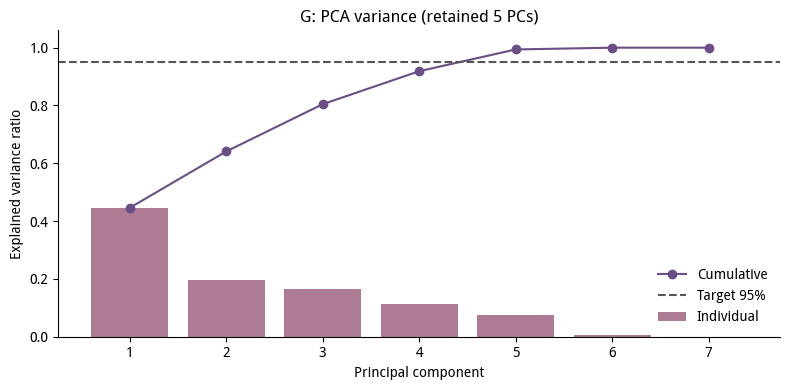

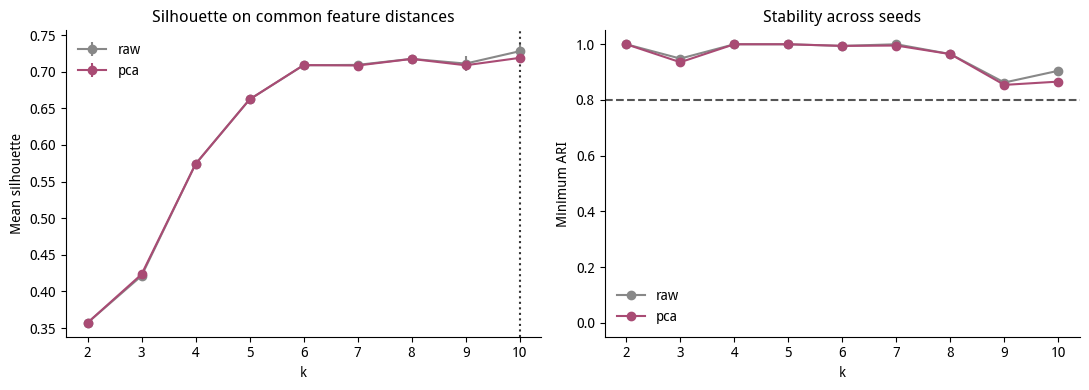

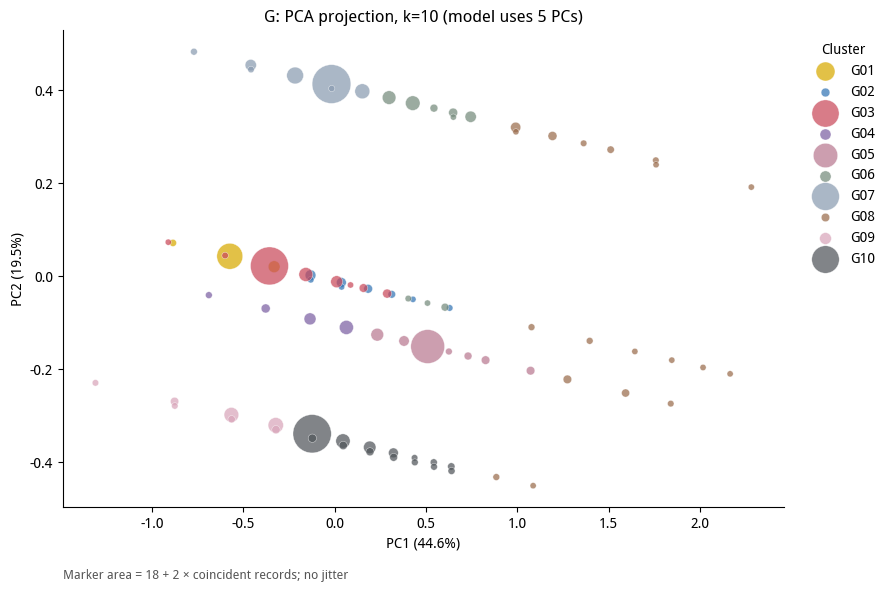

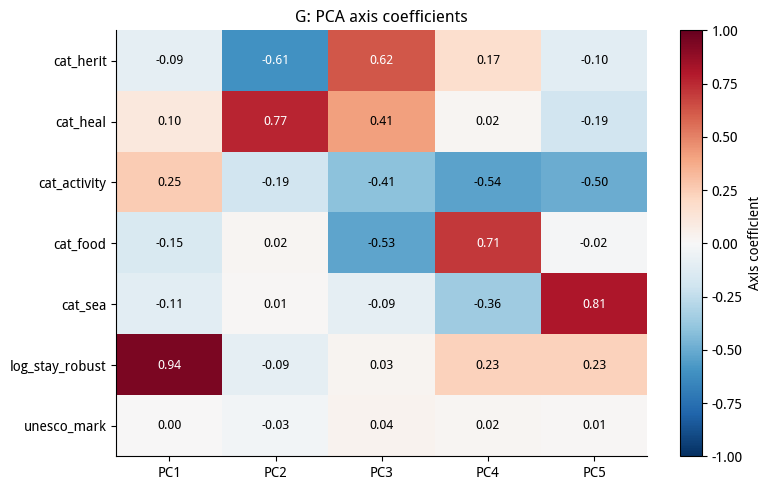

G_cluster,n,base_minutes_median,base_minutes_mean,unesco_mark_rate
G01,196,40.0,41.173469,0.000000
G02,60,70.0,72.166667,0.050000
G03,459,50.0,53.779956,0.000000
G04,85,50.0,52.823529,0.000000
G05,369,90.0,90.596206,0.000000
G06,139,90.0,96.546763,0.007194
G07,523,60.0,58.546845,0.005736
G08,76,180.0,207.631579,0.039474
G09,126,40.0,43.650794,0.126984
G10,516,60.0,65.988372,0.083333


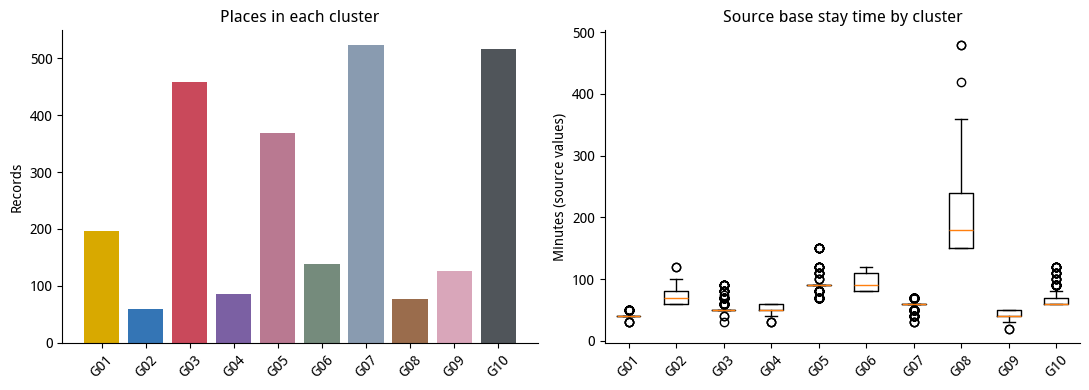

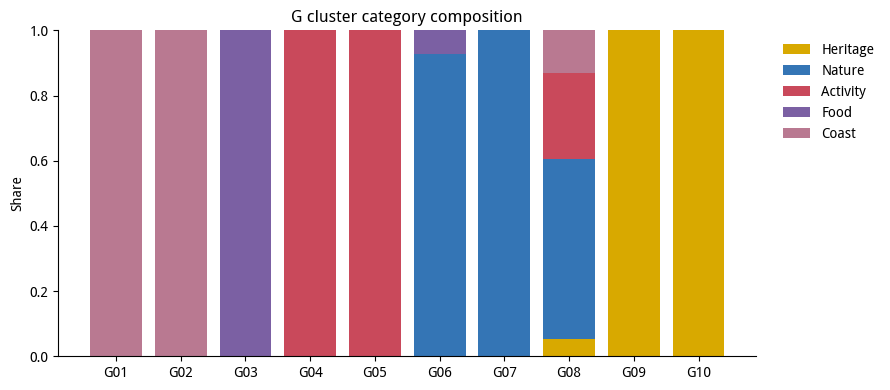

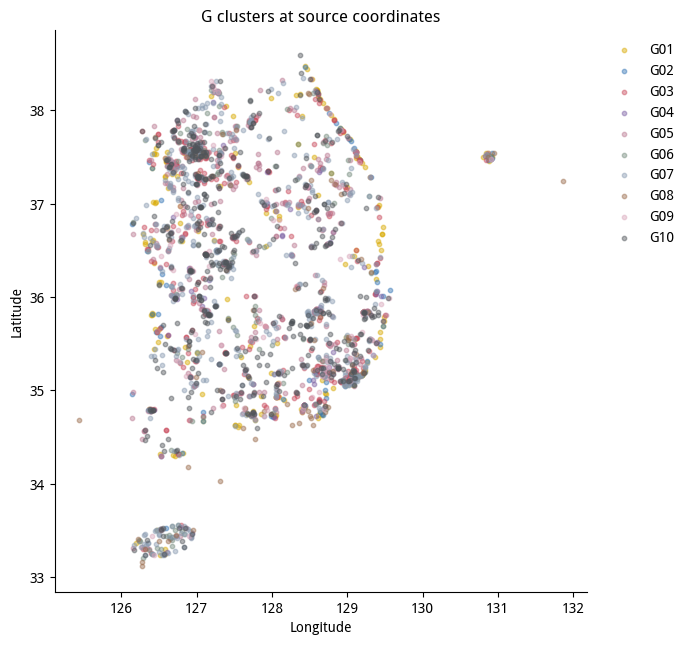

In [5]:
if places is not None:
    place_model=fit_cluster_pipeline(place_features,"G",place_preprocess)
    RUN_SUMMARY["places"]=place_model["summary"]
    eligible_places["G_cluster"]=place_model["labels"]
    eligible_places=eligible_places.join(place_model["pcs"])
    places=places.join(eligible_places[["G_cluster","PC1","PC2"]] if "PC2" in eligible_places else eligible_places[["G_cluster","PC1"]])
    appended=places.add_prefix("analysis_")
    save_csv(pd.concat([places_raw,appended],axis=1),"G_place_assignments_all")
    plot_diagnostics(place_model,2)
    groups=eligible_places.groupby("G_cluster")
    profile=groups.agg(n=("place_id","size"),base_minutes_median=("base_minutes","median"),base_minutes_mean=("base_minutes","mean"),unesco_mark_rate=("unesco_mark","mean"))
    shares=pd.crosstab(eligible_places.G_cluster,eligible_places.category,normalize="index").reindex(columns=CATEGORIES,fill_value=0)
    save_csv(profile.join(shares).reset_index(),"G_cluster_profiles");show_table(profile.reset_index())
    fig,axs=plt.subplots(1,2,figsize=(11,4));colors=[PALETTE[i%len(PALETTE)] for i in range(len(profile))]
    axs[0].bar(profile.index,profile.n,color=colors);axs[0].set(title="Places in each cluster",ylabel="Records")
    axs[1].boxplot([groups.get_group(g).base_minutes.to_numpy() for g in profile.index],showfliers=True)
    axs[1].set_xticks(np.arange(1,len(profile)+1),profile.index)
    axs[1].set(title="Source base stay time by cluster",ylabel="Minutes (source values)")
    for ax in axs:ax.tick_params(axis="x",rotation=45)
    finish(fig,"06_G_sizes_and_stay")
    fig,ax=plt.subplots(figsize=(9,4));bottom=np.zeros(len(shares))
    for i,c in enumerate(CATEGORIES):ax.bar(shares.index,shares[c],bottom=bottom,label=CAT_LABELS[c],color=PALETTE[i]);bottom+=shares[c].to_numpy()
    ax.set(title="G cluster category composition",ylabel="Share",ylim=(0,1));ax.legend(bbox_to_anchor=(1.02,1),loc="upper left",frameon=False);finish(fig,"07_G_category_profiles")
    valid=eligible_places[eligible_places.coordinate_valid]
    fig,ax=plt.subplots(figsize=(7,8))
    for i,g in enumerate(sorted(eligible_places.G_cluster.unique())):
        q=valid[valid.G_cluster.eq(g)];ax.scatter(q.lon,q.lat,s=10,alpha=.45,color=PALETTE[i%len(PALETTE)],label=g)
    if len(valid):ax.set_aspect(1/max(.1,np.cos(np.deg2rad(valid.lat.mean()))))
    ax.set(title="G clusters at source coordinates",xlabel="Longitude",ylabel="Latitude")
    ax.legend(bbox_to_anchor=(1.02,1),loc="upper left",frameon=False);finish(fig,"08_G_coordinate_scatter")


## 5 시티투어 경유지 표준화와 장소 연결
`→`, `⇒`, `↔`, `->`, `>`, `+`, `_`는 괄호 밖에서만 분리합니다. `01 장소 02 장소` 번호열은 연속 번호일 때 처리하고 ① 같은 접두 번호는 지웁니다. 쉼표 목록은 순서가 확정되지 않은 목록으로 표시합니다. `K-POP`, 괄호 설명의 쉼표·가운뎃점은 무조건 잘라내지 않습니다.

자유·맞춤·미정·홈페이지 참조, 여러 선택 노선, 계절별 대체 지점은 보류합니다. 명시된 출발·도착·승차·차창·통과 지점은 관광 방문과 구분합니다. 유일하게 일치하는 **지역+정규화 명칭**만 잠정 장소 후보로 연결하며 검증 완료라고 표시하지 않습니다. 괄호 제거 별칭은 약한 후보이고 부분문자열·전국 단일명 매칭은 사용하지 않습니다.

장소 분류 연결이 없으면 공개된 키워드 사전으로 추정하되 한 경유지가 여러 분류에 걸리면 분류값 합을 1로 정규화합니다. 미분류 경유지도 분모에 남깁니다. 코스의 5개 분류 비율 합은 1 이하입니다. 이는 실제 방문 비중이나 체류 비중이 아닙니다.


In [6]:
def norm_name(text):
    text=unicodedata.normalize("NFKC",str(text)).lower()
    return re.sub(r"[^0-9a-z가-힣]","",text)

def no_parentheses(text):
    return re.sub(r"\([^()]*\)|（[^（）]*）","",str(text)).strip()

def norm_region(text):
    text=norm_name(text)
    # Keep 고성 distinct from 고성(강원); no inferred province mappings.
    return re.sub(r"(특별자치시|광역시|특별시|시|군)$","",text)

def split_outside(text, separators):
    parts=[];buffer=[];depth=0;i=0
    separators=sorted(separators,key=len,reverse=True)
    while i<len(text):
        char=text[i]
        if char in "(（[":depth+=1
        if char in ")）]":depth=max(0,depth-1)
        sep=next((s for s in separators if depth==0 and text.startswith(s,i)),None)
        if sep:
            parts.append("".join(buffer).strip());buffer=[];i+=len(sep)
        else:buffer.append(char);i+=1
    parts.append("".join(buffer).strip())
    return [p for p in parts if p]

def parse_route(text):
    text=str(text).strip()
    if not text:return [],"EMPTY"
    if re.search(r"자유코스|자율코스|맞춤|홈페이지.*참조|리플릿.*참조|운행 요청|원하는 일정|자유선택|요구반영|일대$",text):return [text],"FLEXIBLE_OR_UNSPECIFIED"
    numbered=list(re.finditer(r"(?:^|\s)(\d{1,2})\s+(?=\S)",text))
    if len(numbered)>=2 and [int(m.group(1)) for m in numbered]==list(range(1,len(numbered)+1)):
        parts=[text[m.end():numbered[j+1].start() if j+1<len(numbered) else len(text)].strip() for j,m in enumerate(numbered)]
        return parts,"NUMBERED_ORDER"
    parts=split_outside(text,["->","→","⇒","↔",">","+","_"," - "])
    if len(parts)>1:return parts,"EXPLICIT_SEPARATOR"
    comma=split_outside(text,[",","，"])
    if len(comma)>1:return comma,"UNORDERED_LIST_REVIEW"
    return [text],"UNSPLIT_REVIEW"

def strip_number(text):
    return re.sub(r"^\s*(?:[①-⑳]|\d{1,2}[.)])\s*","",text).strip()

KW={"herit":r"궁|성곽|읍성|산성|사찰|[가-힣]사$|향교|서원|박물관|유적|고분|릉|역사|문화재|한옥|민속|전통|사지|기념관",
    "heal":r"산$|숲|수목원|공원|호수|저수지|계곡|습지|정원|폭포|자연|생태|휴양림|둘레길|농원|수변",
    "activity":r"체험|테마파크|랜드|케이블카|레일|짚|루지|월드|과학관|전망대|스카이|목장|놀이",
    "food":r"시장|먹거리|맛|음식|카페|막걸리|와이너리|양조|빵|맥주|술",
    "sea":r"해수욕장|해변|[가-힣]항$|바다|섬|포구|해안|등대|해상|해양|방조제"}
full_index,base_index=defaultdict(set),defaultdict(set)
place_lookup={}
if places is not None:
    for _,p in places.iterrows():
        region=norm_region(p.region);full_index[(region,norm_name(p["name"]))].add(p.place_id)
        base_index[(region,norm_name(no_parentheses(p["name"])))].add(p.place_id)
        place_lookup[p.place_id]=p

def match_place(region,name,conditional=False):
    if conditional:return "CONDITIONAL_STOP_REVIEW",None
    if places is None:return "NO_PLACE_MASTER",None
    key=(norm_region(region),norm_name(name))
    ids=full_index.get(key,set());status="EXACT_NAME_REGION_CANDIDATE"
    if not ids:
        ids=base_index.get((norm_region(region),norm_name(no_parentheses(name))),set());status="PAREN_ALIAS_CANDIDATE"
    if len(ids)>1:return "AMBIGUOUS_NAME",None
    if len(ids)==1:return status,next(iter(ids))
    return "UNMATCHED",None

city=None;stops=None;city_features=None;city_model=None
if cities_raw is not None:
    mapping={"region":["지역","region_name"],"name":["투어명","course_name"],"type":["유형","course_type_raw"],
             "boarding":["탑승 장소","boarding_raw"],"route":["코스(경유지)","route_raw"],
             "start":["운행 시작","first_departure_raw"],"end":["운행 종료","last_departure_raw"],
             "headway":["배차 간격(분)","headway_raw"],"url":["홈페이지","url"],
             "notes":["운행 요일·비고","notes_raw"],"reference_date":["데이터 기준일","reference_date"]}
    city=standard_columns(cities_raw,mapping,{"region","name","route"})
    city["course_id"]=["ct_"+hashlib.sha256((str(i)+"|"+r.region+"|"+r["name"]+"|"+r.route).encode()).hexdigest()[:14] for i,r in city.iterrows()]
    records=[];course_records=[]
    for index,r in city.iterrows():
        parts,parser=parse_route(r.route);parsed=parser in ["EXPLICIT_SEPARATOR","NUMBERED_ORDER"]
        visit_vectors=[];known=0;matched=0;conditional_count=0;cluster_counter=Counter();visit_n=0
        for seq,raw in enumerate(parts,1):
            name=strip_number(raw);base=no_parentheses(name)
            conditional=bool(re.search(r"또는|봄|여름|가을|겨울|하계|동계|계절|선택",name) or "/" in base)
            role="VISIT_CANDIDATE"
            if re.search(r"출발|도착|승차",name):role="BOARDING_OR_RETURN"
            elif re.search(r"차창|경유|통과",name):role="PASS_BY"
            elif seq in [1,len(parts)] and (norm_name(base)==norm_name(no_parentheses(r.boarding)) or re.search(r"역$|터미널$|주차장$",base)):role="ENDPOINT_TRANSPORT"
            if not parsed:role="UNRESOLVED_ROUTE"
            status,pid=match_place(r.region,name,conditional)
            if role!="VISIT_CANDIDATE":status,pid="NON_VISIT_OR_UNRESOLVED",None
            vector=np.zeros(5);category_source="UNKNOWN";cluster=""
            if role=="VISIT_CANDIDATE":
                visit_n+=1;conditional_count+=int(conditional)
                if pid:
                    p=place_lookup[pid];matched+=1
                    if p.category in CATEGORIES:
                        vector[CATEGORIES.index(p.category)]=1;category_source="PROVISIONAL_PLACE_CATEGORY"
                    if pd.notna(p.get("G_cluster")):cluster=p.G_cluster;cluster_counter[cluster]+=1
                if not vector.any() and not conditional:
                    vector=np.array([bool(re.search(KW[c],base)) for c in CATEGORIES],float)
                    if vector.sum():vector/=vector.sum();category_source="KEYWORD_ESTIMATE"
                known+=int(vector.any());visit_vectors.append(vector)
            records.append({"course_id":r.course_id,"source_row":index+2,"region":r.region,"course_name":r["name"],"sequence":seq,
                            "stop_raw":raw,"name_candidate":base,"parser_status":parser,"role":role,"conditional":conditional,
                            "match_status":status,"place_id_candidate":pid or "","identity_verified":False,"G_cluster":cluster,
                            "category_source":category_source,**{c:float(vector[j]) for j,c in enumerate(CATEGORIES)}})
        shares=np.sum(visit_vectors,axis=0)/visit_n if visit_n else np.zeros(5)
        coverage=known/visit_n if visit_n else 0.0
        eligible=parsed and visit_n>=2 and conditional_count==0 and coverage>=MIN_CITY_CATEGORY_COVERAGE
        why="ELIGIBLE" if eligible else "ROUTE_UNRESOLVED" if not parsed else "CONDITIONAL_STOPS" if conditional_count else "TOO_FEW_VISITS" if visit_n<2 else "LOW_CATEGORY_COVERAGE"
        flags=[]
        if str(r.headway) in ["0","0000",""]:flags.append("HEADWAY_UNKNOWN_OR_NOT_APPLICABLE")
        if str(r.headway)=="1":flags.append("HEADWAY_ONE_REVIEW")
        if r.start==r.end=="00:00":flags.append("OPERATING_TIME_UNDECIDED")
        if not r.url:flags.append("URL_MISSING")
        date=pd.to_datetime(r.reference_date,errors="coerce")
        if pd.isna(date):flags.append("REFERENCE_DATE_MISSING_OR_INVALID")
        elif (pd.Timestamp.now().normalize()-date).days>365:flags.append("REFERENCE_OLDER_THAN_365_DAYS")
        course_records.append({"source_index":index,"course_id":r.course_id,"region":r.region,"name":r["name"],"parser_status":parser,
                               "parsed_stop_count":len(parts),"visit_candidate_count":visit_n,"category_known_count":known,
                               "category_coverage":coverage,"place_candidate_count":matched,"place_match_coverage":matched/visit_n if visit_n else 0,
                               "conditional_stop_count":conditional_count,"cluster_eligible":eligible,"cluster_status":why,
                               "night_flag":int(bool(re.search(r"야간|야경|나이트|밤|야시장|달빛|별빛",r["name"]+r.route))),
                               "operational_flags":"|".join(flags),**{f"share_{c}":float(shares[j]) for j,c in enumerate(CATEGORIES)},
                               "G_composition_counts":json.dumps(dict(sorted(cluster_counter.items())),ensure_ascii=False)})
    stops=pd.DataFrame(records);course_table=pd.DataFrame(course_records).set_index("source_index")
    save_csv(stops,"citytour_stop_links_review");save_csv(course_table.reset_index(),"citytour_features_and_quality")
    save_csv(stops[stops.match_status.isin(["UNMATCHED","AMBIGUOUS_NAME","CONDITIONAL_STOP_REVIEW","NON_VISIT_OR_UNRESOLVED"])],"citytour_stop_unresolved")
    print("코스 / 분석 가능:",len(course_table),"/",int(course_table.cluster_eligible.sum()))
    show_table(course_table.groupby(["parser_status","cluster_status"]).size().reset_index(name="courses"),30)
    print("잠정 장소 후보 연결 슬롯:",int(stops.place_id_candidate.ne("").sum()),"| 확인된 장소 연결: 0")


코스 / 분석 가능: 280 / 179
잠정 장소 후보 연결 슬롯: 521 | 확인된 장소 연결: 0


parser_status,cluster_status,courses
EXPLICIT_SEPARATOR,CONDITIONAL_STOPS,41
EXPLICIT_SEPARATOR,ELIGIBLE,178
EXPLICIT_SEPARATOR,LOW_CATEGORY_COVERAGE,38
EXPLICIT_SEPARATOR,TOO_FEW_VISITS,3
FLEXIBLE_OR_UNSPECIFIED,ROUTE_UNRESOLVED,10
NUMBERED_ORDER,ELIGIBLE,1
UNORDERED_LIST_REVIEW,ROUTE_UNRESOLVED,3
UNSPLIT_REVIEW,ROUTE_UNRESOLVED,6


## 6 코스 PCA와 군집 실행
T모델의 입력은 5개 경유지 분류 비율·방문 후보 수의 로그 변환·야경 플래그입니다. 분류 비율은 **방문 후보 전체 수**로 나누고 미분류 장소도 분모에 포함합니다. 비숙박 장소 연결이 없어도 키워드로 분류할 수 있으므로 `citytour.csv` 하나로 실행할 수 있습니다.

$$X_T=[\sqrt{0.75/2}\,p_1,\ldots,\sqrt{0.75/2}\,p_5,\sqrt{0.15}\,R(\log(1+n)),\sqrt{0.10}\,N]$$

경유지 분류율 50% 미만, 방문 후보 2개 미만, 조건부 경유지, 경로 미확정 코스는 T학습에서 제외하고 결과표에 남깁니다. 운행시각·배차·요금은 군집 특성에 넣지 않으며 운영 가능성을 확인한 것으로 해석하지 않습니다. **T 군집 번호를 추천점수에 더하거나 지역에 강제 배정하지 않습니다.**

**축 해석:** 가중치 0.75·0.15·0.10은 입력 거리의 조절값이며, PCA 설명분산의 비율을 뜻하지 않습니다. 데이터 분산과 공분산에 따라 경유지 수가 PC1을 지배할 수 있습니다. `T_pca_axes.csv`와 군집별 평균 경유지 수를 함께 읽으세요. 장소 CSV를 생략하면 키워드 추정만 사용하므로 연결·분류율·군집 결과가 달라질 수 있습니다.


T {
  "rows": 179,
  "features": [
    "share_herit",
    "share_heal",
    "share_activity",
    "share_food",
    "share_sea",
    "log_visit_count_robust",
    "night_flag"
  ],
  "removed_constant_features": [],
  "pca_components": 5,
  "pca_retained_variance": 0.9672826279557725,
  "plot_2pc_variance": 0.8223107696071333,
  "k": 2,
  "silhouette_mean": 0.3796307930887635,
  "seed_ari_min": 1.0,
  "passes_gates": true,
  "silhouette_sample_size": 179,
  "numbering": "run-specific, no persona assignment"
}
PC1 negative: {'share_heal': -0.0399, 'share_herit': -0.03} positive: {'share_sea': 0.021, 'log_visit_count_robust': 0.9984}
PC2 negative: {'share_heal': -0.4006, 'share_sea': -0.1712} positive: {'log_visit_count_robust': 0.0147, 'share_herit': 0.8764}
축 해석: PC1 계수의 절댓값이 가장 큰 변수는 log_visit_count_robust입니다. 단일 변수의 영향이 크므로 테마 성향이나 여행자 유형으로 바로 해석하지 마세요.


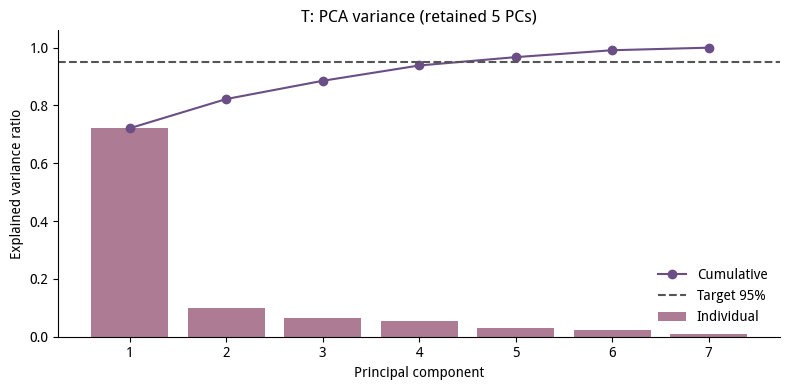

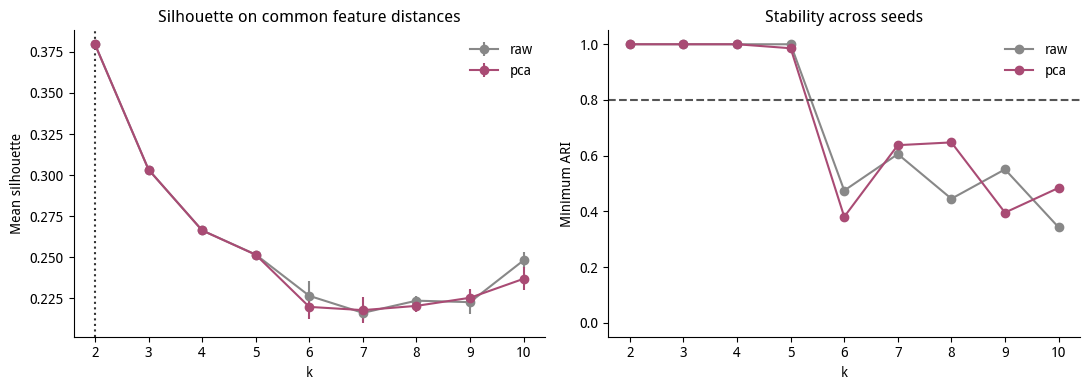

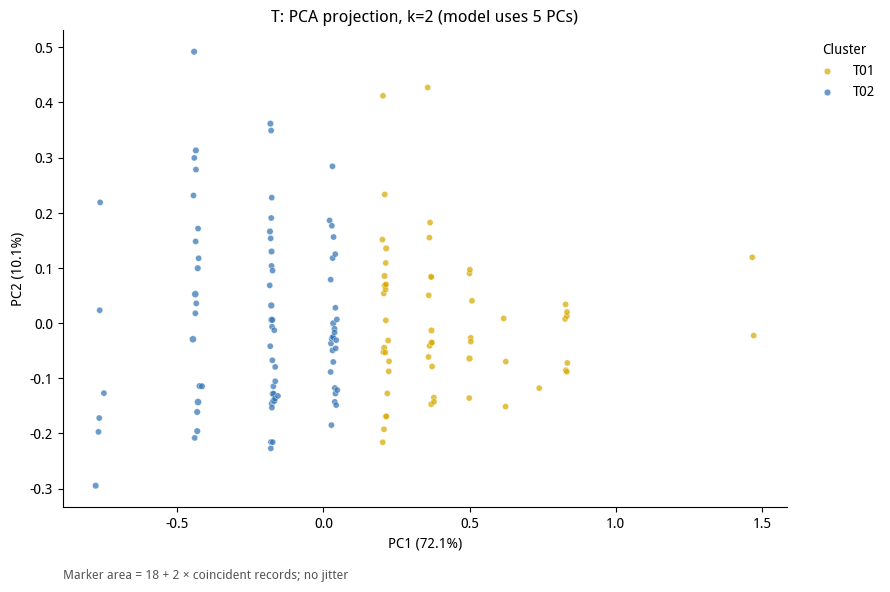

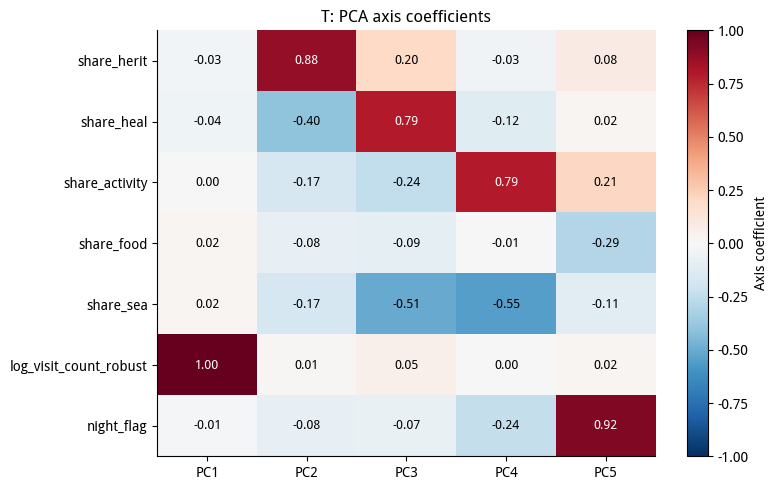

T_cluster,n,share_herit,share_heal,share_activity,share_food,share_sea,visit_candidate_count,night_flag,category_coverage,place_match_coverage
T01,64,0.204267,0.196511,0.121062,0.079574,0.088413,7.718750,0.062500,0.689827,0.422235
T02,115,0.234710,0.238841,0.122681,0.071594,0.078986,3.826087,0.078261,0.746812,0.448261


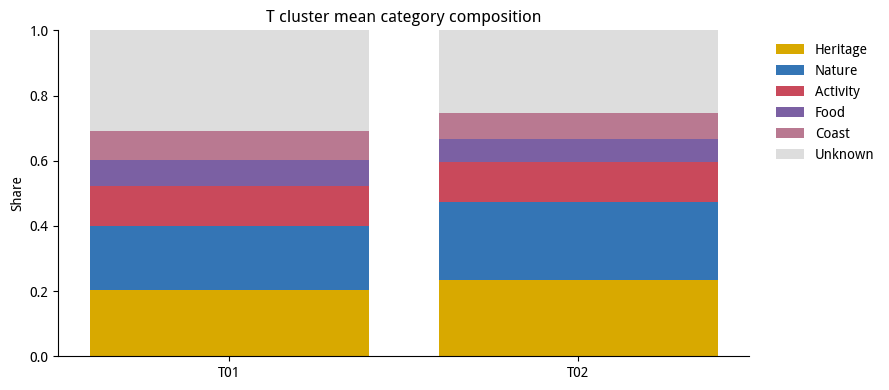

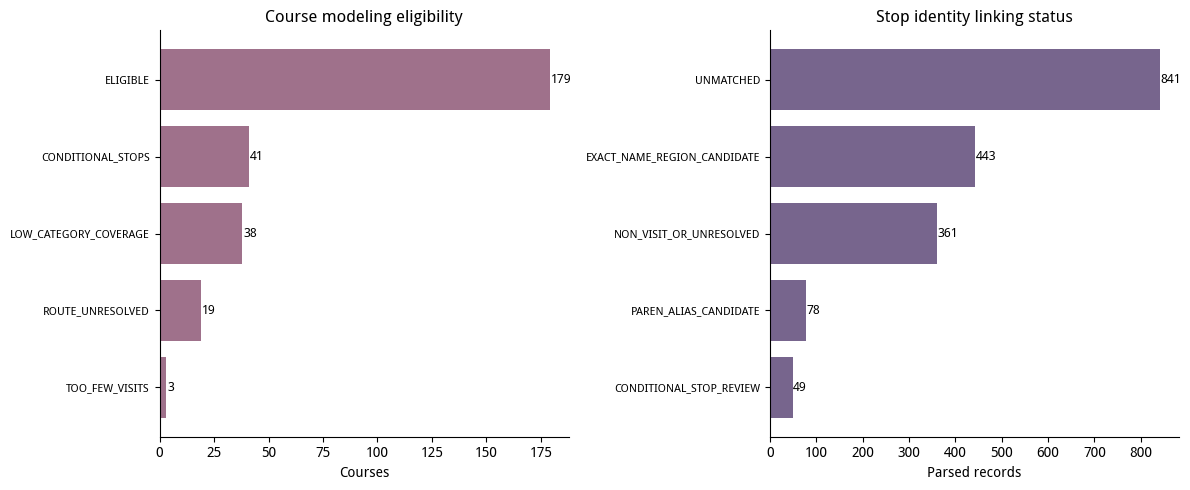

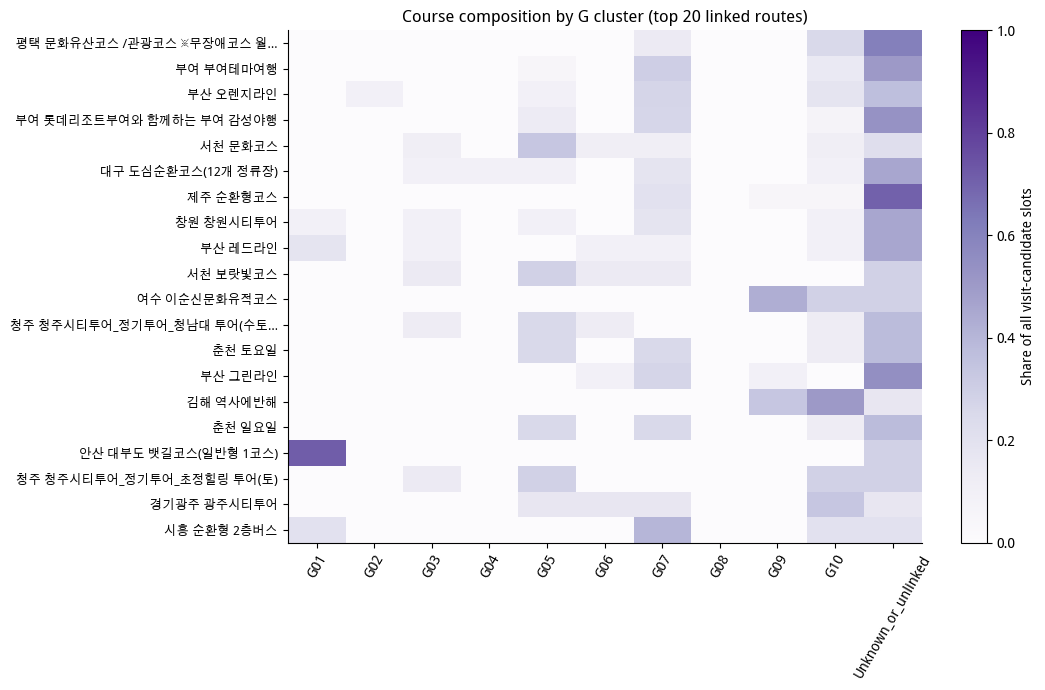

In [7]:
if city is not None:
    city_eligible=course_table.loc[course_table.cluster_eligible].copy()
    if len(city_eligible)>=4:
        city_features=city_eligible[[f"share_{c}" for c in CATEGORIES]]*np.sqrt(CITY_WEIGHTS["category"]/2)
        scaled_count,count_params=robust_log(city_eligible.visit_candidate_count)
        city_features["log_visit_count_robust"]=scaled_count*np.sqrt(CITY_WEIGHTS["stop_count"])
        city_features["night_flag"]=city_eligible.night_flag*np.sqrt(CITY_WEIGHTS["night"])
        if len(np.unique(np.round(city_features.to_numpy(),12),axis=0))>=3:
            city_model=fit_cluster_pipeline(city_features,"T",{"weights":CITY_WEIGHTS,"visit_count":count_params,"keywords":KW,"minimum_category_coverage":MIN_CITY_CATEGORY_COVERAGE})
            RUN_SUMMARY["citytour"]=city_model["summary"]
            city_eligible["T_cluster"]=city_model["labels"]
            city_eligible=city_eligible.join(city_model["pcs"])
            course_table=course_table.join(city_eligible[["T_cluster"]+[c for c in ["PC1","PC2"] if c in city_eligible]])
            plot_diagnostics(city_model,9)
            profile=city_eligible.groupby("T_cluster")[[f"share_{c}" for c in CATEGORIES]+["visit_candidate_count","night_flag","category_coverage","place_match_coverage"]].mean()
            profile.insert(0,"n",city_eligible.groupby("T_cluster").size())
            save_csv(profile.reset_index(),"T_cluster_profiles");show_table(profile.reset_index(),20)
            fig,ax=plt.subplots(figsize=(9,4));bottom=np.zeros(len(profile))
            for i,c in enumerate(CATEGORIES):
                values=profile[f"share_{c}"];ax.bar(profile.index,values,bottom=bottom,label=CAT_LABELS[c],color=PALETTE[i]);bottom+=values.to_numpy()
            ax.bar(profile.index,1-bottom,bottom=bottom,label="Unknown",color="#DDDDDD")
            ax.set(title="T cluster mean category composition",ylabel="Share",ylim=(0,1));ax.legend(bbox_to_anchor=(1.02,1),loc="upper left",frameon=False)
            finish(fig,"13_T_category_profiles")
        else:print("코스의 서로 다른 특성 조합이 3개 미만이어서 T PCA·군집은 생략합니다.")
    else:print("유효 코스가 4개 미만이어서 T PCA·군집은 생략합니다. 품질표는 저장합니다.")
    save_csv(pd.concat([cities_raw,course_table.add_prefix("analysis_")],axis=1),"T_citytour_assignments_all")
    fig,axs=plt.subplots(1,2,figsize=(12,5))
    count=course_table.cluster_status.value_counts();axs[0].barh(count.index,count.values,color="#9F718B");axs[0].invert_yaxis();axs[0].set(title="Course modeling eligibility",xlabel="Courses")
    count=stops.match_status.value_counts();axs[1].barh(count.index,count.values,color="#77658D");axs[1].invert_yaxis();axs[1].set(title="Stop identity linking status",xlabel="Parsed records")
    for ax in axs:
        ax.tick_params(axis="y",labelsize=8)
        for bar in ax.patches:ax.text(bar.get_width()+.5,bar.get_y()+bar.get_height()/2,str(int(bar.get_width())),va="center",fontsize=9)
    finish(fig,"14_citytour_quality_and_linking")
    if places is not None and stops.G_cluster.ne("").any():
        matched=stops[stops.G_cluster.ne("")]
        by_course=pd.crosstab(matched.course_id,matched.G_cluster)
        denominator=course_table.set_index("course_id").visit_candidate_count
        shares=by_course.div(denominator.reindex(by_course.index),axis=0)
        shares["Unknown_or_unlinked"]=1-shares.sum(axis=1)
        save_csv(shares.reset_index(),"citytour_G_composition_shares")
        # Display the 20 most linked routes; the CSV preserves every linked route.
        selected=by_course.sum(axis=1).sort_values(ascending=False).head(20).index
        display_shares=shares.loc[selected].copy()
        names=course_table.set_index("course_id").apply(lambda r:r["region"]+" "+r["name"],axis=1)
        labels=[(name[:24]+"…") if len(name)>25 else name for name in names.loc[selected]] if font!="DejaVu Sans" else [f"Route {i+1}" for i in range(len(selected))]
        fig,ax=plt.subplots(figsize=(11,7));im=ax.imshow(display_shares,cmap="Purples",vmin=0,vmax=1,aspect="auto")
        ax.set(yticks=np.arange(len(selected)),yticklabels=labels,xticks=np.arange(len(shares.columns)),xticklabels=shares.columns,title="Course composition by G cluster (top 20 linked routes)")
        ax.tick_params(axis="x",rotation=60);ax.tick_params(axis="y",labelsize=9);fig.colorbar(im,ax=ax,label="Share of all visit-candidate slots")
        finish(fig,"15_citytour_G_composition")


## 지역 소비와 해양 자료
지역 수준 관측을 설명 맥락으로 연결합니다. 개인 선호 가산과 체류 배율을 추정하지 않습니다.


## 지역 지출 비율 입력
지역 CSV만 읽습니다. 광역 비율과 광역 내 기초 비율의 합계를 검사하고 계층 비중을 계산합니다. 기간과 대상 집단은 원본에서 별도로 확인해야 합니다. 원화 지출액을 추정하지 않습니다.


In [8]:
import zipfile
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
SPEND={};SPEND_INFO={};spend_model_data=None;spend_regression=None
REGION_HEADERS={'광역지자체 명','기초지자체 명','광역지자체 지출액 비율(%)','기초지자체 지출액 비율(%)'}
def numeric_checked(series,name):
    v=pd.to_numeric(series.astype(str).str.replace(',','',regex=False),errors='coerce')
    if v.isna().any() or (~np.isfinite(v)).any() or v.lt(0).any():raise ValueError(f'{name}: 누락·음수·비수치')
    return v.astype(float)
def load_region_input(source):
    if source is None or not Path(source).exists():
        print('지역 지출 자료 없음: 지역 설명 모델을 건너뜁니다.');return {}
    p=Path(source)
    if p.is_dir():blobs=[(str(x),x.read_bytes()) for x in sorted(p.glob('*.csv'))]
    elif p.suffix.lower()=='.zip':
        with zipfile.ZipFile(p) as z:blobs=[(n,z.read(n)) for n in z.namelist() if n.lower().endswith('.csv')]
    elif p.suffix.lower()=='.csv':blobs=[(str(p),p.read_bytes())]
    else:raise ValueError('지역 지출 입력은 CSV, 폴더 또는 ZIP이어야 합니다.')
    found={}
    for name,b in blobs:
        for enc in ['utf-8-sig','cp949','utf-16']:
            try:df=pd.read_csv(io.BytesIO(b),encoding=enc,dtype=str,keep_default_na=False);break
            except UnicodeError:continue
        else:raise ValueError(f'CSV 인코딩 확인 필요: {name}')
        df.columns=[str(c).strip().lstrip('\ufeff') for c in df.columns]
        if not REGION_HEADERS.issubset(df.columns):continue
        if found:raise ValueError('지역 지출 CSV가 여러 개입니다.')
        found['region']=df
        INPUT_META['spend_region']={'file':name,'sha256':hashlib.sha256(b).hexdigest(),'rows':len(df),'encoding':enc,'columns':df.columns.tolist()}
    if not found:raise ValueError('지역 지출 필수 칼럼을 갖춘 CSV가 없습니다.')
    return found
SPEND=load_region_input(SPENDING_INPUT)
if SPEND:
    sp_reg=SPEND['region'].rename(columns={'광역지자체 명':'province','기초지자체 명':'municipality','광역지자체 지출액 비율(%)':'province_pct','기초지자체 지출액 비율(%)':'within_province_pct'}).copy()
    for col in ['province','municipality']:
        sp_reg[col]=sp_reg[col].str.strip()
        if sp_reg[col].eq('').any():raise ValueError('지역명 누락')
    for col in ['province_pct','within_province_pct']:sp_reg[col]=numeric_checked(sp_reg[col],col)
    if sp_reg.duplicated(['province','municipality']).any():raise ValueError('지역 키 중복')
    if sp_reg.groupby('province').province_pct.nunique().gt(1).any():raise ValueError('광역 비율 불일치')
    if sp_reg[['province_pct','within_province_pct']].gt(100).any().any():raise ValueError('100% 초과')
    sp_province=sp_reg.groupby('province').agg(province_pct=('province_pct','first'),child_sum_pct=('within_province_pct','sum'),rows=('municipality','size')).reset_index()
    if not sp_province.child_sum_pct.between(99,101).all() or not 99<=sp_province.province_pct.sum()<=101:raise ValueError('지역 계층 비율 합계 확인 필요')
    sp_reg['region_id']=sp_reg.province+'|'+sp_reg.municipality
    sp_reg['national_share_pct_raw']=sp_reg.province_pct*sp_reg.within_province_pct/100
    sp_reg['national_share_pct_normalized']=100*(sp_reg.province_pct/sp_province.province_pct.sum())*(sp_reg.within_province_pct/sp_reg.province.map(sp_province.set_index('province').child_sum_pct))
    sp_reg['zero_share_review']=sp_reg.within_province_pct.eq(0)
    sp_reg['boundary_review']=sp_reg.province.str.contains('통합')|sp_reg.province.eq('인천광역시')
    sp_reg['boundary_note']=np.where(sp_reg.province.eq('인천광역시'),'원본 하위 명칭의 경계와 기간 확인 필요',np.where(sp_reg.province.str.contains('통합'),'원본 광역 명칭 보존; 경계 환산 안 함',''))
    pos=sp_reg.national_share_pct_normalized.gt(0);sp_reg['economic_context_score']=np.nan
    sp_reg.loc[pos,'economic_context_score']=100*(sp_reg.loc[pos,'national_share_pct_normalized'].rank(method='average')-1)/max(1,pos.sum()-1)
    SPEND_INFO={'region_rows':len(sp_reg),'province_labels':len(sp_province),'regional_amount_estimation_enabled':False,
      'population_label':'내국인 지출로 제공됨; CSV에 대상집단 확인 열 없음',
      'period_status':'지역 CSV에 기간 열 없음; 다른 파일의 기간을 자동 적용하지 않음',
      'region_share_denominator':'hierarchical denominator inferred from sums; not verified from UI metadata'}
    save_csv(sp_reg,'spend_region_context');save_csv(sp_province,'spend_province_quality')
    print(json.dumps(SPEND_INFO,ensure_ascii=False,indent=2))


{
  "region_rows": 233,
  "province_labels": 16,
  "regional_amount_estimation_enabled": false,
  "population_label": "내국인 지출로 제공됨; CSV에 대상집단 확인 열 없음",
  "period_status": "지역 CSV에 기간 열 없음; 다른 파일의 기간을 자동 적용하지 않음",
  "region_share_denominator": "hierarchical denominator inferred from sums; not verified from UI metadata"
}


## 7 지역 연결과 장소 및 코스의 경제 맥락
광역 비율 $P_p$와 광역 안 기초 비율 $C_{r|p}$를 각각 합계로 나눈 뒤 곱하여 지역 전국비중 $w_r$을 만듭니다. 원본 비율과 정규화값을 모두 저장합니다.

$$w_r=\frac{P_p}{\sum_pP_p}\frac{C_{r|p}}{\sum_{r\in p}C_{r|p}},\qquad E_r=100\frac{rank(w_r)-1}{N-1}$$

$E_r$은 제공된 양수 지역 비중의 상대 순위입니다. 장소 매출·개인 지출·추천 확률이 아닙니다. 지역값을 장소마다 연결해도 합산하지 않습니다. 광역 이름과 기초 지역 이름을 분리하며 동명 지역은 자동 연결하지 않습니다. `경기광주`, `고성(강원)`처럼 상위 지역이 명시된 별칭만 명시 규칙으로 연결합니다. CSV에 함께 존재하는 인천의 신구 명칭과 통합 광역명은 원문을 보존하고 확인 상태를 기록합니다.


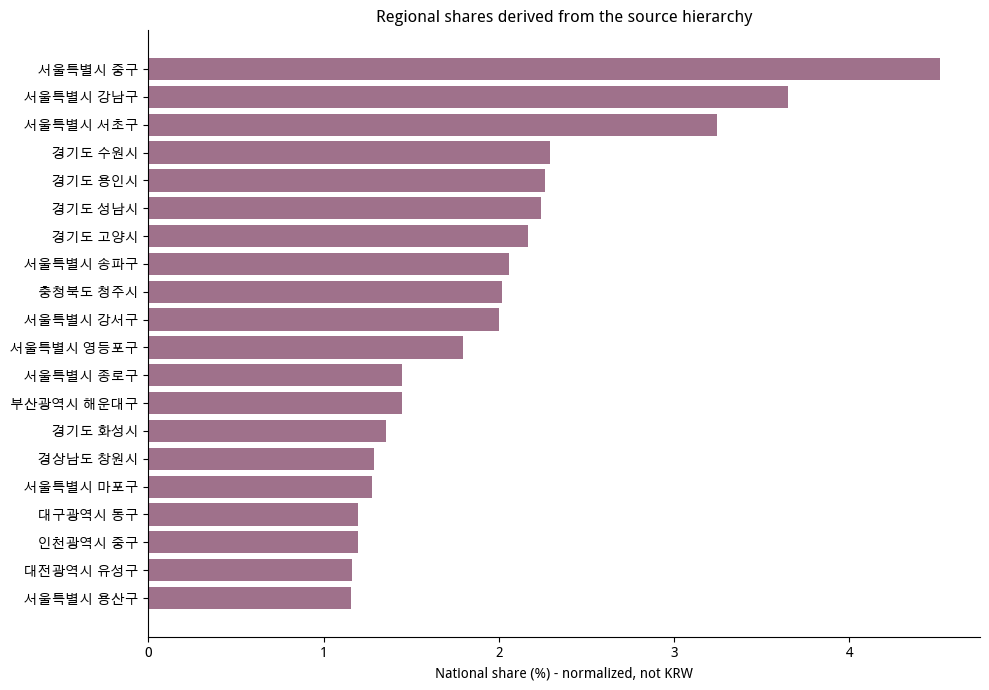

spend_level,join_status,source_regions
municipality,EXPLICIT_PARENT_ALIAS,2
municipality,UNIQUE_MUNICIPALITY_ALIAS,113
province,PROVINCE_CONTEXT_ONLY,8
unresolved,AMBIGUOUS_METRO_VS_CITY,1
unresolved,AMBIGUOUS_NAME,1


In [9]:
if SPEND:
    sp_parent_alias={'서울':'서울특별시','부산':'부산광역시','대구':'대구광역시','대전':'대전광역시','인천':'인천광역시','울산':'울산광역시','세종':'세종특별자치시','제주':'제주특별자치도'}
    sp_explicit_alias={'경기광주':('경기도','광주시'),'고성(강원)':('강원특별자치도','고성군')}
    def spend_join_region(name):
        name=str(name).strip()
        if name in sp_parent_alias:
            p=sp_parent_alias[name];hit=sp_province[sp_province.province.eq(p)]
            return {'region':name,'spend_region_id':p,'spend_province':p,'spend_level':'province','join_status':'PROVINCE_CONTEXT_ONLY','national_share_pct':float(hit.iloc[0].province_pct/sp_province.province_pct.sum()*100) if len(hit) else np.nan,'economic_context_score':np.nan,'boundary_review':p=='인천광역시'}
        if name=='광주':hit=sp_reg.iloc[:0];status='AMBIGUOUS_METRO_VS_CITY'
        elif name in sp_explicit_alias:
            p,m=sp_explicit_alias[name];hit=sp_reg[sp_reg.province.eq(p)&sp_reg.municipality.eq(m)];status='EXPLICIT_PARENT_ALIAS'
        else:
            hit=sp_reg[sp_reg.municipality.map(lambda x:re.sub(r'[시군구]$','',str(x))).eq(name)];status='UNIQUE_MUNICIPALITY_ALIAS'
        if len(hit)==1:
            a=hit.iloc[0]
            return {'region':name,'spend_region_id':a.region_id,'spend_province':a.province,'spend_level':'municipality','join_status':status,'national_share_pct':float(a.national_share_pct_normalized),'economic_context_score':float(a.economic_context_score),'boundary_review':bool(a.boundary_review)}
        return {'region':name,'spend_region_id':'','spend_province':'','spend_level':'unresolved','join_status':status if name=='광주' else 'AMBIGUOUS_NAME' if len(hit)>1 else 'UNMATCHED','national_share_pct':np.nan,'economic_context_score':np.nan,'boundary_review':False}
    sp_names=set()
    if places is not None:sp_names.update(places.region.unique())
    if city is not None:sp_names.update(city.region.unique())
    sp_mapping=pd.DataFrame([spend_join_region(x) for x in sorted(sp_names)])
    if len(sp_mapping):save_csv(sp_mapping,'spend_region_mapping_review')
    if places is not None:
        sp_place_links=places[['place_id','region','name','category','base_minutes','G_cluster']].reset_index().merge(sp_mapping,on='region',how='left',validate='many_to_one')
        sp_place_links['recommendation_spend_bonus']=0.0
        sp_place_links['score_status']='CONTEXT_ONLY_NOT_CALIBRATED'
        save_csv(sp_place_links,'G_places_with_spending_context')
        sp_gcontext=sp_place_links[sp_place_links.G_cluster.notna()].groupby('G_cluster').agg(places=('place_id','size'),linked_municipality_places=('spend_level',lambda x:int(x.eq('municipality').sum())),unique_source_regions=('region','nunique'),context_score_median=('economic_context_score','median'))
        save_csv(sp_gcontext.reset_index(),'G_spending_context_profiles')
    if city is not None:
        sp_course_links=course_table.reset_index().merge(sp_mapping,on='region',how='left',validate='many_to_one')
        sp_course_links['recommendation_spend_bonus']=0.0;sp_course_links['score_status']='CONTEXT_ONLY_NOT_CALIBRATED'
        save_csv(sp_course_links,'T_citytours_with_spending_context')
    sp_top=sp_reg.nlargest(20,'national_share_pct_normalized').sort_values('national_share_pct_normalized')
    fig,ax=plt.subplots(figsize=(10,7));ax.barh(sp_top.province+' '+sp_top.municipality,sp_top.national_share_pct_normalized,color='#9F718B')
    ax.set(title='Regional shares derived from the source hierarchy',xlabel='National share (%) - normalized, not KRW');finish(fig,'24_spend_region_shares')
    if len(sp_mapping):show_table(sp_mapping.groupby(['spend_level','join_status']).size().reset_index(name='source_regions'),20)


## 8 지역 소비 비중 설명 모델과 광역 단위 외부 검증
**목표:** 등록 관광지의 구성과 코스 공급 지표가 지역 소비 비중과 어떤 관계를 보이는지 평가합니다. 표본은 전국 모든 지역이 아니라 장소 CSV와 기초 지역명이 연결되고 관광지 3개 이상이 등록된 지역입니다.

$$y_r=\log(100w_r),\quad\widehat y_r=\beta_0+\sum_f\beta_f z_{rf},\quad\min_\beta\sum_r(y_r-\widehat y_r)^2+\alpha\sum_f\beta_f^2$$

M0는 학습 지역 로그비중 평균, M1은 등록 관광지 수만 사용하는 Ridge, M2는 장소 분류 구성·기본시간·숙박 등록 수·시티투어 수·유네스코 표시율을 추가한 Ridge입니다. 광역별 GroupKFold 외부 5분할, 내부 3분할로 alpha를 고릅니다. 표준화도 학습 폴드 안에서만 계산합니다. 지역별 목표 비중·경제맥락점수·광역 지출비율은 설명변수에 넣지 않습니다.

카탈로그 등록 수는 실제 관광 공급 전수량이 아닙니다. G는 전체 장소로 학습했으므로 회귀 성능 평가에 G번호를 직접 넣지 않습니다. 회귀에는 사전에 정의한 원특성만 사용하고, G와의 관계는 별도 기술통계로 보여줍니다. 계수는 연관성을 설명하며 인과 효과나 미래 예측력이 아닙니다.


지역 설명 모델 OOF 결과


model,n_regions,mae_log,rmse_log,r2_log,mae_share_pp
M0_mean,111,1.004190,1.231170,-0.139786,0.256789
M1_catalog_count,111,0.861742,1.079218,0.124198,0.231812
M2_composition,111,0.839696,1.071844,0.136126,0.232700


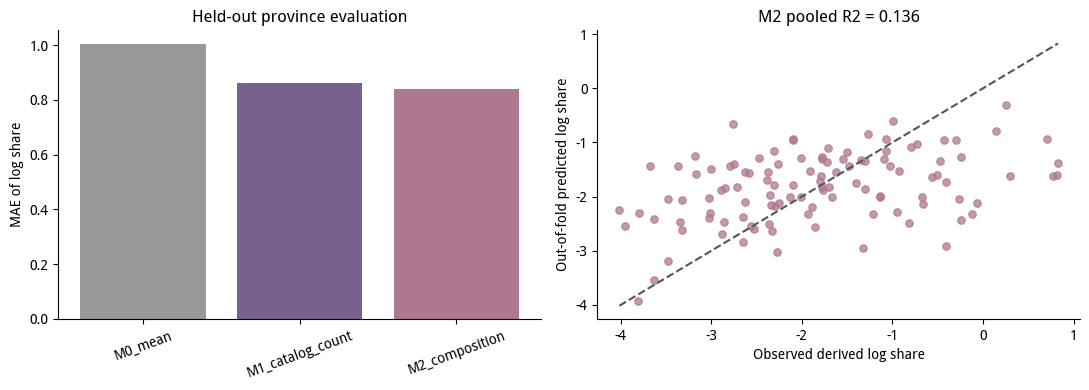

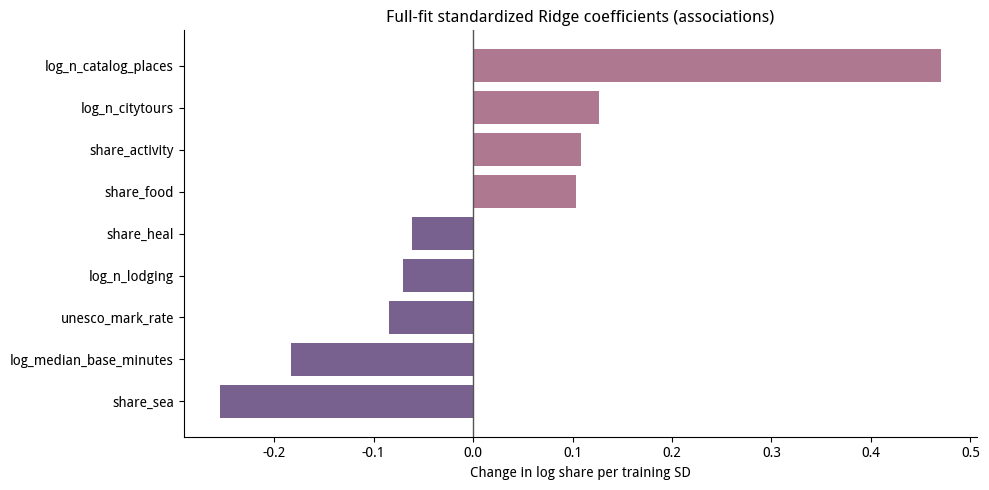

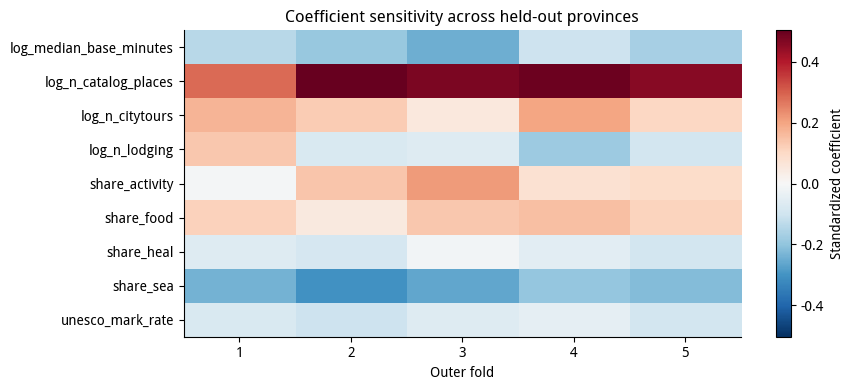

In [10]:
if SPEND and places is not None:
    sp_rows=[]
    for region,group in places.groupby('region'):
        gp=group[group.cluster_eligible];gmap=sp_mapping[sp_mapping.region.eq(region)].iloc[0]
        row=gmap.to_dict();row.update({'n_catalog_places':len(gp),'n_lodging':int(group.category.eq('stay').sum()),'n_citytours':int(city.region.eq(region).sum()) if city is not None else 0,
                                    'median_base_minutes':float(gp.base_minutes.median()) if len(gp) else np.nan,'unesco_mark_rate':float(gp.unesco_mark.mean()) if len(gp) else np.nan})
        row.update({f'share_{c}':float(gp.category.eq(c).mean()) if len(gp) else np.nan for c in CATEGORIES})
        row['model_eligible']=bool(gmap.spend_level=='municipality' and len(gp)>=MIN_CATALOG_PLACES and pd.notna(gmap.national_share_pct) and gmap.national_share_pct>0)
        row['model_reason']='ELIGIBLE' if row['model_eligible'] else 'MIXED_OR_UNRESOLVED_GEOGRAPHY' if gmap.spend_level!='municipality' else 'CATALOG_TOO_SMALL_OR_SHARE_NOT_POSITIVE'
        sp_rows.append(row)
    sp_region_catalog=pd.DataFrame(sp_rows)
    save_csv(sp_region_catalog,'spend_region_catalog_features_all')
    spend_model_data=sp_region_catalog[sp_region_catalog.model_eligible].copy().reset_index(drop=True)
    # Keep the mixed-boundary source label visible; grouping uses that label as provided.
    if len(spend_model_data)>=20 and spend_model_data.spend_province.nunique()>=5:
        for col in ['n_catalog_places','n_lodging','n_citytours','median_base_minutes']:
            spend_model_data['log_'+col]=np.log1p(spend_model_data[col])
        sp_feats=['log_n_catalog_places','log_n_lodging','log_n_citytours','log_median_base_minutes','share_heal','share_activity','share_food','share_sea','unesco_mark_rate']
        sp_x=spend_model_data[sp_feats].copy();sp_y=np.log(spend_model_data.national_share_pct.to_numpy());sp_groups=spend_model_data.spend_province.to_numpy()
        sp_oof={k:np.full(len(sp_y),np.nan) for k in ['M0_mean','M1_catalog_count','M2_composition']}
        sp_foldid=np.zeros(len(sp_y),int);sp_foldrows=[];sp_coefrows=[]
        sp_outer=GroupKFold(n_splits=5)
        for fold,(train,test) in enumerate(sp_outer.split(sp_x,sp_y,sp_groups),1):
            assert not set(sp_groups[train])&set(sp_groups[test]);sp_foldid[test]=fold
            sp_oof['M0_mean'][test]=sp_y[train].mean()
            for name,features in [('M1_catalog_count',sp_feats[:1]),('M2_composition',sp_feats)]:
                pipe=Pipeline([('scale',StandardScaler()),('ridge',Ridge())])
                inner=GroupKFold(n_splits=min(3,len(set(sp_groups[train]))))
                search=GridSearchCV(pipe,{'ridge__alpha':REGRESSION_ALPHAS},cv=inner,scoring='neg_mean_squared_error',n_jobs=1,error_score='raise')
                search.fit(sp_x.iloc[train][features],sp_y[train],groups=sp_groups[train])
                pred=search.predict(sp_x.iloc[test][features]);sp_oof[name][test]=pred
                sp_foldrows.append({'fold':fold,'model':name,'test_provinces':'|'.join(sorted(set(sp_groups[test]))),'n_train':len(train),'n_test':len(test),'alpha':float(search.best_params_['ridge__alpha']),'mae_log':float(mean_absolute_error(sp_y[test],pred)),'rmse_log':float(np.sqrt(mean_squared_error(sp_y[test],pred))),'r2_log':float(r2_score(sp_y[test],pred))})
                if name=='M2_composition':
                    sp_coefrows.extend({'fold':fold,'feature':f,'standardized_beta':float(b)} for f,b in zip(features,search.best_estimator_.named_steps['ridge'].coef_))
        sp_metrics=[]
        for name,pred in sp_oof.items():
            assert np.isfinite(pred).all()
            sp_metrics.append({'model':name,'n_regions':len(sp_y),'mae_log':float(mean_absolute_error(sp_y,pred)),'rmse_log':float(np.sqrt(mean_squared_error(sp_y,pred))),'r2_log':float(r2_score(sp_y,pred)),'mae_share_pp':float(mean_absolute_error(np.exp(sp_y),np.exp(pred)))})
        sp_metrics=pd.DataFrame(sp_metrics);sp_folds=pd.DataFrame(sp_foldrows);sp_coefs=pd.DataFrame(sp_coefrows)
        sp_predictions=spend_model_data[['region','spend_region_id','spend_province','national_share_pct','boundary_review']].copy();sp_predictions['fold']=sp_foldid;sp_predictions['target_log_share']=sp_y
        for name,pred in sp_oof.items():sp_predictions[name+'_oof_log']=pred;sp_predictions[name+'_oof_share_pct']=np.exp(pred)
        sp_finalsearch=GridSearchCV(Pipeline([('scale',StandardScaler()),('ridge',Ridge())]),{'ridge__alpha':REGRESSION_ALPHAS},cv=GroupKFold(n_splits=5),scoring='neg_mean_squared_error',error_score='raise')
        sp_finalsearch.fit(sp_x,sp_y,groups=sp_groups)
        spend_regression=sp_finalsearch.best_estimator_
        sp_finalcoef=pd.DataFrame({'feature':sp_feats,'standardized_beta':spend_regression.named_steps['ridge'].coef_})
        sp_z=spend_regression.named_steps['scale'].transform(sp_x)
        sp_explain=pd.DataFrame(sp_z*spend_regression.named_steps['ridge'].coef_,columns=sp_feats)
        sp_explain.insert(0,'region',spend_model_data.region);sp_explain['intercept']=float(spend_regression.named_steps['ridge'].intercept_)
        sp_explain['fitted_log_share']=sp_explain[sp_feats].sum(axis=1)+sp_explain.intercept
        assert np.allclose(sp_explain.fitted_log_share,spend_regression.predict(sp_x))
        for frame,name in [(spend_model_data,'spend_regression_input'),(sp_predictions,'spend_regression_oof'),(sp_metrics,'spend_regression_metrics'),(sp_folds,'spend_regression_folds'),(sp_coefs,'spend_regression_fold_coefficients'),(sp_finalcoef,'spend_regression_coefficients'),(sp_explain,'spend_regression_additive_explanations')]:save_csv(frame,name)
        sp_buffer=io.BytesIO();joblib.dump({'pipeline':spend_regression,'features':sp_feats,'target':'log normalized national regional share percent','alpha':float(sp_finalsearch.best_params_['ridge__alpha']),'sklearn':sklearn.__version__},sp_buffer);(MODELS/'spend_region_ridge.joblib').write_bytes(sp_buffer.getvalue())
        SPEND_INFO['regression']={'n_regions':len(sp_y),'n_province_groups':len(set(sp_groups)),'outer_folds':5,'inner_folds':3,'features':sp_feats,'metrics':sp_metrics.to_dict('records'),'final_alpha':float(sp_finalsearch.best_params_['ridge__alpha']),
                                  'added_features_improve_mae':bool(sp_metrics.set_index('model').loc['M2_composition','mae_log']<sp_metrics.set_index('model').loc['M1_catalog_count','mae_log']),
                                  'all_target_region_values_are_derived_shares':True,'future_forecast_validated':False}
        print('지역 설명 모델 OOF 결과');show_table(sp_metrics,10)
        fig,axs=plt.subplots(1,2,figsize=(11,4))
        axs[0].bar(sp_metrics.model,sp_metrics.mae_log,color=['#999999','#78618E','#AF7891']);axs[0].set(title='Held-out province evaluation',ylabel='MAE of log share');axs[0].tick_params(axis='x',rotation=20)
        axs[1].scatter(sp_y,sp_oof['M2_composition'],color='#AF7891',s=28,alpha=.75);lo=min(sp_y.min(),sp_oof['M2_composition'].min());hi=max(sp_y.max(),sp_oof['M2_composition'].max());axs[1].plot([lo,hi],[lo,hi],'--',color='#555')
        axs[1].set(xlabel='Observed derived log share',ylabel='Out-of-fold predicted log share',title=f'M2 pooled R2 = {sp_metrics.set_index("model").loc["M2_composition","r2_log"]:.3f}')
        finish(fig,'25_spend_regression_oof')
        sp_c=sp_finalcoef.sort_values('standardized_beta');fig,ax=plt.subplots(figsize=(10,5));ax.barh(sp_c.feature,sp_c.standardized_beta,color=np.where(sp_c.standardized_beta>=0,'#AF7891','#78618E'));ax.axvline(0,color='#555',lw=1)
        ax.set(title='Full-fit standardized Ridge coefficients (associations)',xlabel='Change in log share per training SD');finish(fig,'26_spend_regression_coefficients')
        fig,ax=plt.subplots(figsize=(9,4));sp_cp=sp_coefs.pivot(index='feature',columns='fold',values='standardized_beta');lim=max(.01,float(np.abs(sp_cp.to_numpy()).max()));im=ax.imshow(sp_cp,aspect='auto',cmap='RdBu_r',vmin=-lim,vmax=lim)
        ax.set(xticks=np.arange(len(sp_cp.columns)),xticklabels=sp_cp.columns,yticks=np.arange(len(sp_cp)),yticklabels=sp_cp.index,title='Coefficient sensitivity across held-out provinces',xlabel='Outer fold');fig.colorbar(im,ax=ax,label='Standardized coefficient');finish(fig,'27_spend_coefficient_stability')
    else:print('지역 설명 회귀는 연결 지역 20개 및 광역 집단 5개 이상일 때 실행합니다. 연결표와 기술통계는 저장합니다.')


## 지역 설명 모델의 사용 범위
지역 소비 비중은 관광지·코스에 설명 근거로 연결합니다. 경제 추천 가산은 0입니다. 회귀 성능은 광역을 분리한 교차검증으로 평가하며 인과 효과나 미래 예측 성능을 뜻하지 않습니다.


In [11]:
if SPEND:
    assert np.isclose(sp_reg.national_share_pct_normalized.sum(),100)
    assert SPEND_INFO['regional_amount_estimation_enabled'] is False
    if places is not None:
        assert len(sp_place_links)==len(places)
        assert sp_place_links.recommendation_spend_bonus.eq(0).all()
    if city is not None:
        assert len(sp_course_links)==len(course_table)
        assert sp_course_links.recommendation_spend_bonus.eq(0).all()
    (RUN_DIR/'spending_summary.json').write_text(json.dumps(SPEND_INFO,ensure_ascii=False,indent=2),encoding='utf-8')
    RUN_SUMMARY['spending']=SPEND_INFO
    print('지출 확장 완료:',json.dumps(SPEND_INFO.get('regression',{}),ensure_ascii=False,indent=2))


지출 확장 완료: {
  "n_regions": 111,
  "n_province_groups": 8,
  "outer_folds": 5,
  "inner_folds": 3,
  "features": [
    "log_n_catalog_places",
    "log_n_lodging",
    "log_n_citytours",
    "log_median_base_minutes",
    "share_heal",
    "share_activity",
    "share_food",
    "share_sea",
    "unesco_mark_rate"
  ],
  "metrics": [
    {
      "model": "M0_mean",
      "n_regions": 111,
      "mae_log": 1.0041903937305299,
      "rmse_log": 1.231169778772649,
      "r2_log": -0.13978556614299142,
      "mae_share_pp": 0.25678852211857417
    },
    {
      "model": "M1_catalog_count",
      "n_regions": 111,
      "mae_log": 0.8617415547470375,
      "rmse_log": 1.0792184944838519,
      "r2_log": 0.1241978269228935,
      "mae_share_pp": 0.2318124422257654
    },
    {
      "model": "M2_composition",
      "n_regions": 111,
      "mae_log": 0.8396957244624829,
      "rmse_log": 1.0718437553423688,
      "r2_log": 0.13612635622739788,
      "mae_share_pp": 0.2327004216806318
    }
  

## 9 전국 해양 입력과 품질 검사
`MARINE_INPUT`에는 기본 3종(히트맵·월별 추이·증가율 Top5)과 선택 입력 `marine_search_rank.csv`를 둡니다. CSV는 파일명이 아닌 칼럼 집합으로 판별하며 같은 종류가 두 개면 중단합니다.

이번 입력은 전국 히트맵 3,564행, 외지인방문자 월별 추이 60행, 연안 전체 증가율 Top5 5행, 연안 전체 검색순위 100행입니다. 월별 추이와 Top5는 이전 입력과 바이트가 같습니다. `source_registry.json`은 원본 파일명과 SHA-256을 보존하며 해시가 맞을 때만 범위·대상 표기를 재사용합니다. 새 CSV로 교체하면 오래된 출처 설명을 적용하지 않습니다.

히트맵 방문값 공란 1건은 NaN으로 보존합니다. 외지인방문자 표기는 파일명에서 확인한 것으로 외국인 지표로 쓰지 않습니다. 검색 건수는 방문자 수와 별도 단위입니다. 스냅샷 CSV에 기간 열이 없으므로 월별 파일의 기간을 자동으로 적용하지 않습니다.


In [12]:
MARINE_HEADERS = {
    'heatmap': {'지역명','방문자수','구분'},
    'monthly': {'기준년월','구분','지자체건수','방문자수(평균)'},
    'top5': {'순위','읍면동','방문자 수','전년동기 방문자 수','비율'},
    'search_rank': {'순위','관광지명','도로명','분류','검색 건수'}
}
MARINE_GROUPS = ['전국','연안 도시','연안 어촌','연안 전체','비연안']
MARINE_PRIMARY = ['연안 도시','연안 어촌','비연안']
MARINE_LABELS = {'전국':'National','연안 도시':'Coastal urban','연안 어촌':'Coastal rural','연안 전체':'All coastal','비연안':'Non-coastal'}
MARINE_COLORS = {'전국':'#555555','연안 도시':'#A25F86','연안 어촌':'#78618E','연안 전체':'#3475B5','비연안':'#909090'}
marine_info = {}; marine_flags = []; marine_places = None; marine_courses = None; marine_stop_links = None

def load_marine_input(source):
    if source is None or not Path(source).exists():
        print('해양 입력 없음: 해양 확장을 건너뜁니다.'); return {}
    source=Path(source)
    if source.is_dir(): blobs=[(str(p),p.read_bytes()) for p in sorted(source.glob('*.csv'))]
    elif source.suffix.lower()=='.zip':
        with zipfile.ZipFile(source) as z: blobs=[(n,z.read(n)) for n in z.namelist() if n.lower().endswith('.csv')]
    else: raise ValueError('MARINE_INPUT은 해양 CSV 폴더 또는 ZIP입니다.')
    registry={}
    if source.is_dir() and (source/'source_registry.json').is_file():
        registry=json.loads((source/'source_registry.json').read_text(encoding='utf-8'))
    elif source.suffix.lower()=='.zip':
        with zipfile.ZipFile(source) as z:
            registry_names=[name for name in z.namelist() if Path(name).name=='source_registry.json']
            if len(registry_names)>1:raise ValueError('source_registry.json이 여러 개 있습니다.')
            if registry_names:registry=json.loads(z.read(registry_names[0]).decode('utf-8'))
    result={}
    for name,b in blobs:
        for enc in ['utf-8-sig','cp949','utf-16']:
            try: d=pd.read_csv(io.BytesIO(b),encoding=enc,dtype=str,keep_default_na=False);break
            except UnicodeError:continue
        else:raise ValueError('해양 CSV 인코딩 확인 필요: '+name)
        d.columns=[str(c).strip().lstrip('\ufeff') for c in d.columns]
        types=[k for k,h in MARINE_HEADERS.items() if h.issubset(d.columns)]
        if not types:continue
        if len(types)!=1 or types[0] in result:raise ValueError('중복·불명확한 해양 CSV: '+name)
        k=types[0];result[k]=d
        INPUT_META['marine_'+k]={'file':name,'rows':len(d),'columns':d.columns.tolist(),'sha256':hashlib.sha256(b).hexdigest(),'encoding':enc}
        record=registry.get(k,{})
        valid_record=record.get('sha256')==INPUT_META['marine_'+k]['sha256']
        meta=INPUT_META['marine_'+k]
        meta['source_registry_status']='hash_matched' if valid_record else 'hash_mismatch_ignored' if record else 'not_provided'
        meta['original_filename']=record['original_filename'] if valid_record else Path(name).name
        for field in ['declared_scope','declared_population','declaration_evidence']:
            meta[field]=record.get(field,'not_recorded') if valid_record else 'not_recorded'
        if not valid_record:
            if '외지인방문자' in Path(name).name:
                meta['declared_population']='외지인방문자';meta['declaration_evidence']='current_filename_hint'
            if '연안 전체' in Path(name).name:
                meta['declared_scope']='연안 전체 선택 목록';meta['declaration_evidence']='current_filename_hint'
    if not {'heatmap','monthly','top5'}.issubset(result):raise ValueError('해양 기본 CSV 3종 필요: 확인된 종류 '+str(list(result)))
    inventory=pd.DataFrame([{'input_kind':k,**INPUT_META['marine_'+k]} for k in result])
    inventory['columns']=inventory['columns'].map(lambda a:' | '.join(a))
    save_csv(inventory,'marine_input_source_inventory')
    return result

def marine_admin_parts(text):
    tokens=str(text).strip().split()
    if len(tokens)<3 or not re.search(r'[읍면동]$',tokens[-1]):
        raise ValueError('광역·시군구·읍면동 이름 확인 필요: '+str(text))
    return tokens[0],' '.join(tokens[1:-1]),tokens[-1]

MARINE=load_marine_input(MARINE_INPUT)
if MARINE:
    mh=MARINE['heatmap'].rename(columns={'지역명':'admin_name','방문자수':'area_visitors','구분':'marine_class'}).copy()
    mt=MARINE['monthly'].rename(columns={'기준년월':'month','구분':'group','지자체건수':'area_count','방문자수(평균)':'mean_visitors'}).copy()
    mg=MARINE['top5'].rename(columns={'순위':'source_rank','읍면동':'admin_name','방문자 수':'current_visitors','전년동기 방문자 수':'previous_visitors','비율':'source_ratio_pct'}).copy()
    # Blank heatmap visitor counts are unknown, not zero; keep area metadata.
    heat_raw=mh.area_visitors.astype(str).str.strip().str.replace(',','',regex=False)
    mh['visitor_value_missing']=heat_raw.eq('')
    mh['area_visitors']=pd.to_numeric(heat_raw.mask(mh.visitor_value_missing),errors='coerce')
    invalid=(~mh.visitor_value_missing & ~np.isfinite(mh.area_visitors)) | mh.area_visitors.lt(0)
    if invalid.any():raise ValueError('히트맵 방문자 수의 비수치·무한대·음수는 허용하지 않습니다.')
    mh['visitor_value_status']=np.where(mh.visitor_value_missing,'MISSING_NOT_IMPUTED','OBSERVED')
    mh['heatmap_source_present']=True
    for d,cs in [(mt,['area_count','mean_visitors']),(mg,['source_rank','current_visitors','previous_visitors'])]:
        for c in cs:d[c]=numeric_checked(d[c],'marine '+c)
    mg['source_ratio_pct']=pd.to_numeric(mg.source_ratio_pct.astype(str).str.replace(',','',regex=False),errors='coerce')
    if not np.isfinite(mg.source_ratio_pct).all():raise ValueError('Top5 비율에 비수치가 있습니다.')
    mt['month']=mt.month.astype(str).str.strip();mt['group']=mt.group.astype(str).str.strip()
    if not mt.month.str.fullmatch(r'\d{6}').all():raise ValueError('해양 월은 YYYYMM이어야 합니다.')
    periods=pd.to_datetime(mt.month,format='%Y%m',errors='raise').dt.to_period('M')
    expected=pd.period_range(periods.min(),periods.max(),freq='M').strftime('%Y%m').tolist()
    if mt.duplicated(['month','group']).any():raise ValueError('해양 월×구분 중복 행')
    if set(mt.group)!=set(MARINE_GROUPS):raise ValueError('해양 월별 구분 5종 확인 필요')
    if any(set(g.month)!=set(expected) for _,g in mt.groupby('group')):raise ValueError('해양 월×구분 누락')
    if mt.area_count.le(0).any() or (mt.area_count%1!=0).any():raise ValueError('지자체건수는 양의 정수여야 합니다.')
    mt['area_count']=mt.area_count.astype(int)
    mt=mt.sort_values(['month','group']).reset_index(drop=True)
    for d in [mh,mg]:
        d['admin_name']=d.admin_name.astype(str).str.strip()
        if d.admin_name.duplicated().any():raise ValueError('해양 읍면동 중복')
        parts=d.admin_name.map(marine_admin_parts)
        d[['province','municipality','township']]=pd.DataFrame(parts.tolist(),index=d.index)
    if not mh.marine_class.isin(['연안 도시','연안 어촌','비연안']).all():raise ValueError('히트맵 구분 확인 필요')
    if mg.source_rank.duplicated().any() or (mg.source_rank%1!=0).any():raise ValueError('Top5 순위 확인 필요')
    mg['source_rank']=mg.source_rank.astype(int)
    mg['standard_yoy_pct']=np.where(mg.previous_visitors.gt(0),100*(mg.current_visitors/mg.previous_visitors-1),np.nan)
    mg['current_denominator_pct']=np.where(mg.current_visitors.gt(0),100*(mg.current_visitors-mg.previous_visitors)/mg.current_visitors,np.nan)
    mg['source_matches_current_denominator']=np.isclose(mg.source_ratio_pct,mg.current_denominator_pct,atol=MARINE_RATIO_TOLERANCE_PP,rtol=0)
    mg['source_matches_previous_denominator']=np.isclose(mg.source_ratio_pct,mg.standard_yoy_pct,atol=MARINE_RATIO_TOLERANCE_PP,rtol=0)
    mg['source_minus_standard_pp']=mg.source_ratio_pct-mg.standard_yoy_pct
    mg['marine_class']=mg.admin_name.map(mh.set_index('admin_name').marine_class)
    mg['class_evidence']=np.where(mg.marine_class.notna(),'matched_heatmap_source_label','not_in_heatmap_no_class_inference')
    mg['selection_bias']='top5_only_not_a_national_training_sample'
    mvalue=mt.pivot(index='month',columns='group',values='mean_visitors').reindex(expected)
    mcount=mt.pivot(index='month',columns='group',values='area_count').reindex(expected)
    checks=[]
    for month in expected:
        for parent,children in [('연안 전체',['연안 도시','연안 어촌']),('전국',['연안 전체','비연안'])]:
            counts=mcount.loc[month,children];reconstructed=np.average(mvalue.loc[month,children],weights=counts)
            actual=float(mvalue.loc[month,parent]); count_ok=int(counts.sum())==int(mcount.loc[month,parent])
            checks.append({'month':month,'parent':parent,'reconstructed_weighted_mean':reconstructed,'source_mean':actual,'difference_visitors':actual-reconstructed,'count_sum_matches':count_ok,'within_rounding_tolerance':abs(actual-reconstructed)<=MARINE_MEAN_TOLERANCE})
    marine_checks=pd.DataFrame(checks)
    if not marine_checks.count_sum_matches.all():raise ValueError('해양 계층별 지자체건수 합계 불일치')
    if not marine_checks.within_rounding_tolerance.all():marine_flags.append({'check':'mean_reconciliation','status':'review','detail':'지자체건수 가중 평균과 원본 평균의 차이가 허용범위를 넘습니다.'})
    marine_info={'method_version':'marine-input-context-2.1','period_start':expected[0],'period_end':expected[-1],'months':len(expected),'heatmap_rows':len(mh),'heatmap_municipalities':sorted(mh.municipality.unique().tolist()),'monthly_rows':len(mt),'top5_rows':len(mg),'all_source_ratios_match_current_denominator':bool(mg.source_matches_current_denominator.all()),'max_weighted_mean_abs_difference':float(marine_checks.difference_visitors.abs().max()),'recommendation_bonus':0.0,'stay_multiplier':1.0,'new_marine_clustering_fitted':False,'forecast_validated':False,'spend_per_visitor_computed':False,'admin_boundary_verified_links':0,'snapshot_csv_has_period_column':False,'source_scope':'national heatmap snapshot as supplied; separate monthly group means; selected top5; not a township time panel'}
    marine_info.update({'heatmap_scope':'national_query_as_supplied',
        'heatmap_valid_visitor_rows':int(mh.area_visitors.notna().sum()),
        'heatmap_missing_visitor_rows':int(mh.visitor_value_missing.sum()),
        'heatmap_province_labels':int(mh.province.nunique()),
        'heatmap_class_counts':{k:int(v) for k,v in mh.marine_class.value_counts().items()},
        'heatmap_missing_area_names':mh.loc[mh.visitor_value_missing,'admin_name'].tolist(),
        'admin_labels_preserved_without_unverified_crosswalk':True,
        'monthly_population_label':INPUT_META['marine_monthly']['declared_population'],
        'monthly_population_evidence':INPUT_META['marine_monthly']['declaration_evidence']})
    for d,n in [(mh,'marine_township_heatmap'),(mt,'marine_monthly_clean'),(mg,'marine_top5_growth_audit'),(marine_checks,'marine_monthly_reconciliation')]:save_csv(d,n)
    show_table(mg[['admin_name','source_ratio_pct','standard_yoy_pct','source_matches_current_denominator']],10)
    print('해양 입력과 검증',json.dumps(marine_info,ensure_ascii=False,indent=2))



해양 입력과 검증 {
  "method_version": "marine-input-context-2.1",
  "period_start": "202509",
  "period_end": "202608",
  "months": 12,
  "heatmap_rows": 3564,
  "heatmap_municipalities": [
    "가평군",
    "강남구",
    "강동구",
    "강릉시",
    "강북구",
    "강서구",
    "강진군",
    "강화군",
    "거제시",
    "거창군",
    "검단구",
    "경산시",
    "경주시",
    "계룡시",
    "계양구",
    "고령군",
    "고성군",
    "고양시 덕양구",
    "고양시 일산동구",
    "고양시 일산서구",
    "고창군",
    "고흥군",
    "곡성군",
    "공주시",
    "과천시",
    "관악구",
    "광명시",
    "광산구",
    "광양시",
    "광주시",
    "광진구",
    "괴산군",
    "구례군",
    "구로구",
    "구리시",
    "구미시",
    "군산시",
    "군위군",
    "군포시",
    "금산군",
    "금정구",
    "금천구",
    "기장군",
    "김제시",
    "김천시",
    "김포시",
    "김해시",
    "나주시",
    "남구",
    "남동구",
    "남양주시",
    "남원시",
    "남해군",
    "노원구",
    "논산시",
    "단양군",
    "달서구",
    "달성군",
    "담양군",
    "당진시",
    "대덕구",
    "도봉구",
    "동구",
    "동대문구",
    "동두천시",
    "동래구",
    "동작구",
    "동해시",
    "마포구",
    "목포시",
    "무안군",
    "무주군",
    "문경시"

admin_name,source_ratio_pct,standard_yoy_pct,source_matches_current_denominator
부산광역시 강서구 신호동,40.85,69.070079,True
인천광역시 옹진군 북도면,39.36,64.903755,True
경기도 평택시 현덕면,35.52,55.082243,True
강원특별자치도 속초시 동명동,32.52,48.190561,True
제주특별자치도 서귀포시 송산동,30.40,43.667956,True


## 10 월별 해양 수요 맥락 지수와 그래프
- 기간 평균 지수: $I_{g,t}=100\,\bar V_{g,t}/\operatorname{mean}_{s}(\bar V_{g,s})$. 100은 해당 집계군의 관측기간 평균입니다.
- 비연안 대비 지수: $R_{g,t}=100\,\bar V_{g,t}/\bar V_{비연안,t}$. 크기 100은 같은 달 평균이 같음을 뜻합니다.
- 전월 변화와 함께 집계구역 수 변경 월을 표시합니다. 12개월 한 해의 패턴을 반복 계절성이나 미래 예측으로 확정하지 않습니다.

월별 지출 입력과 방문자 대비 지출 환산은 사용하지 않습니다. 원본 히트맵에 좌표·경계가 없어 지리 지도를 만들지 않고 지역명 막대로 표시합니다.
전국 히트맵은 전체 행 CSV, 유효 방문값 상위 20개 막대그림, 구분별 행 수와 누적분포, 광역 표기×연안 구분의 중앙값 히트맵으로 출력합니다. 방문값 결측은 수치 통계에서 제외하고 행 수·결측 수를 따로 표시합니다. 전국 행별 방문 추정값을 합쳐 중복 제거한 전국 방문자 수로 표시하지 않습니다.


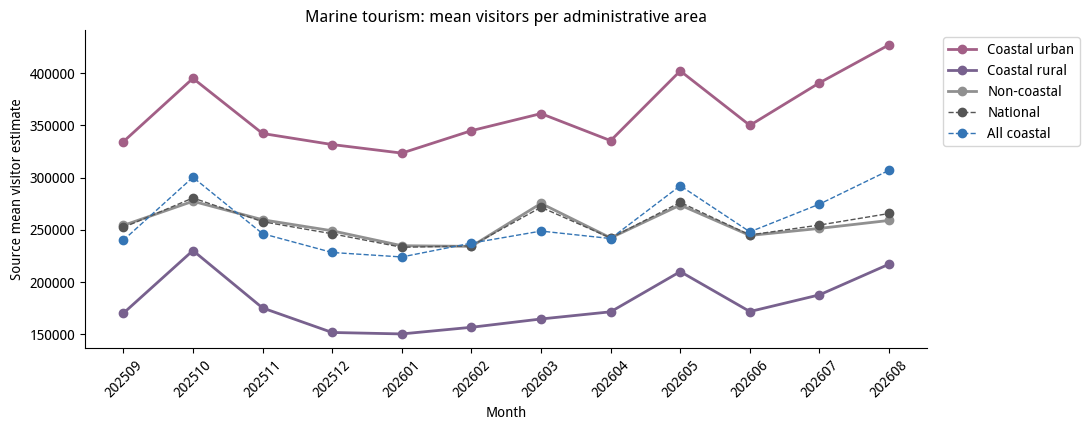

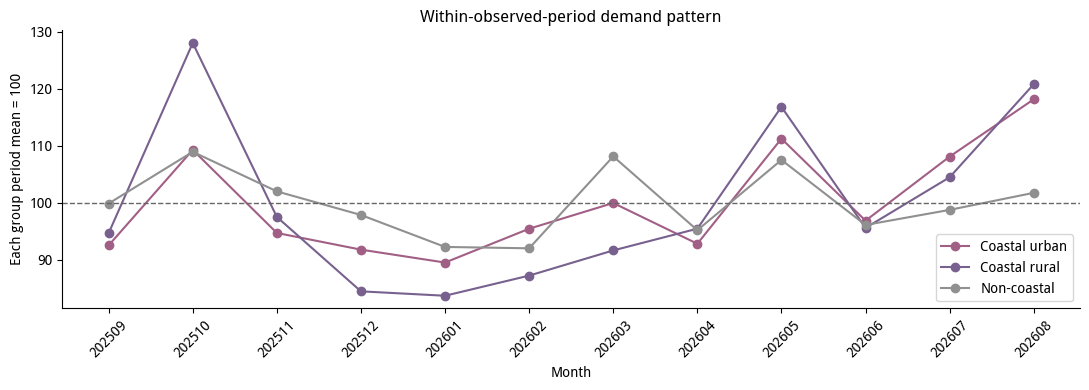

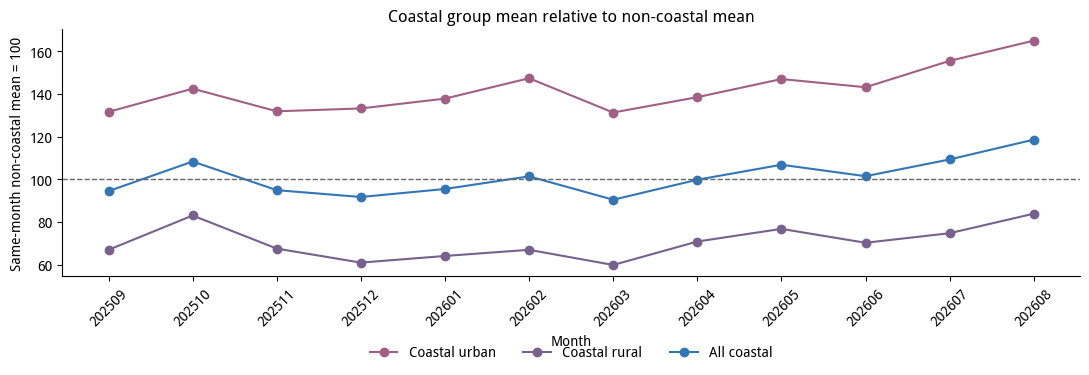

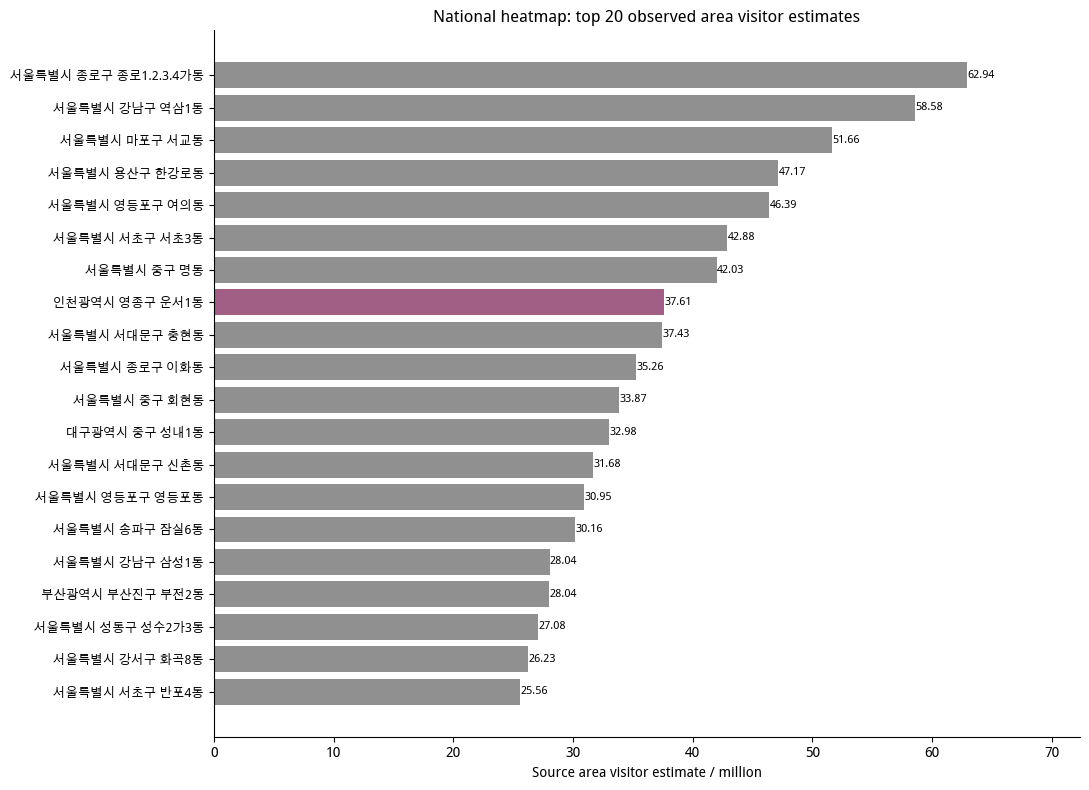

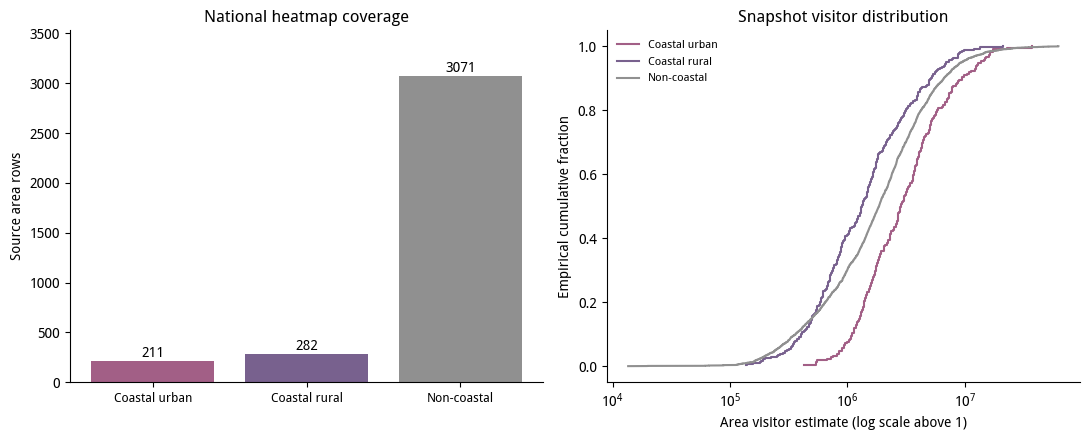

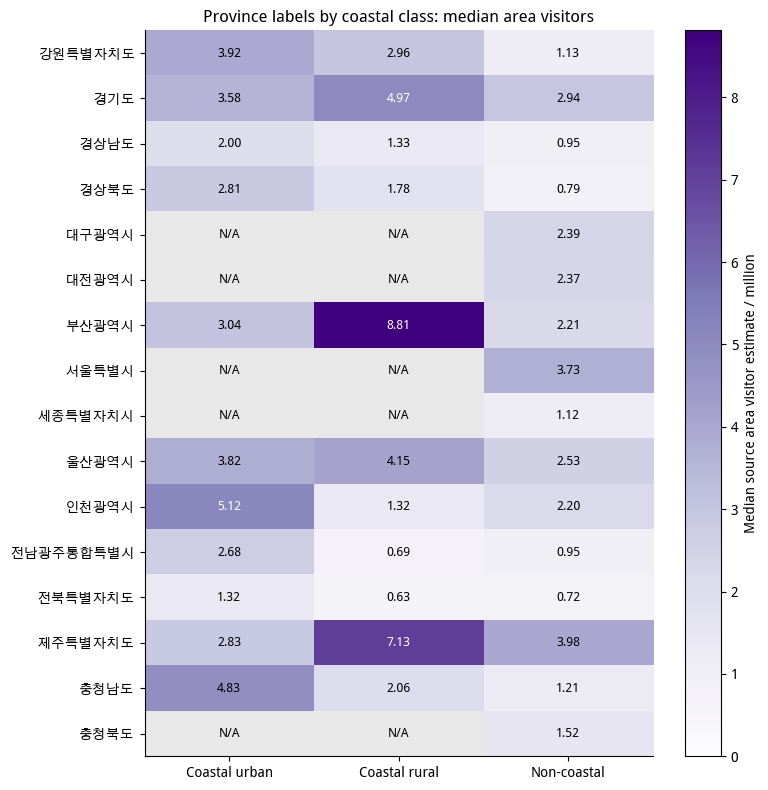

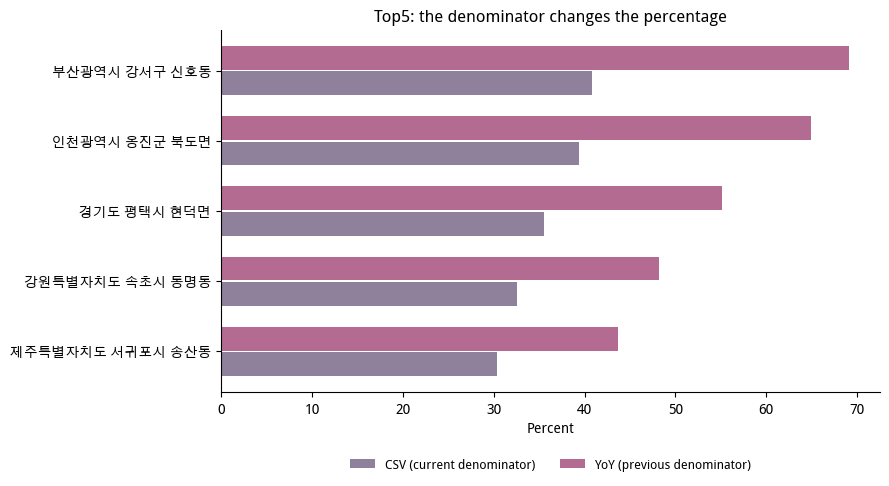

In [13]:
if MARINE:
    mi=mt.copy()
    period_means=mt.groupby('group').mean_visitors.mean()
    mi['period_mean_index']=100*mi.mean_visitors/mi.group.map(period_means).replace(0,np.nan)
    national=mvalue['전국'].to_dict();noncoastal=mvalue['비연안'].to_dict()
    mi['relative_to_national_index']=100*mi.mean_visitors/mi.month.map(national).replace(0,np.nan)
    mi['relative_to_noncoastal_index']=100*mi.mean_visitors/mi.month.map(noncoastal).replace(0,np.nan)
    mi['mom_pct']=mi.groupby('group').mean_visitors.pct_change(fill_method=None)*100
    changed=mi.groupby('group').area_count.diff().fillna(0).ne(0);mi['area_count_changed_from_previous']=changed
    profile=[]
    for group,d in mi.groupby('group'):
        peak=d.loc[d.mean_visitors.idxmax()];low=d.loc[d.mean_visitors.idxmin()]
        profile.append({'group':group,'mean_of_monthly_means':float(d.mean_visitors.mean()),'peak_month':peak.month,'peak_mean_visitors':float(peak.mean_visitors),'low_month':low.month,'peak_to_low_ratio':float(peak.mean_visitors/low.mean_visitors) if low.mean_visitors>0 else np.nan,'months':len(d),'min_area_count':int(d.area_count.min()),'max_area_count':int(d.area_count.max())})
    mprofile=pd.DataFrame(profile)
    save_csv(mi,'marine_monthly_indices');save_csv(mprofile,'marine_monthly_group_summary')
    fig,ax=plt.subplots(figsize=(11,4.4))
    for g in MARINE_PRIMARY+['전국','연안 전체']:
        ax.plot(expected,mvalue[g],marker='o',label=MARINE_LABELS[g],color=MARINE_COLORS[g],lw=2 if g in MARINE_PRIMARY else 1,ls='-' if g in MARINE_PRIMARY else '--')
    ax.set(title='Marine tourism: mean visitors per administrative area',ylabel='Source mean visitor estimate',xlabel='Month');ax.tick_params(axis='x',rotation=45);ax.legend(bbox_to_anchor=(1.01,1));finish(fig,'28_marine_monthly_means')
    fig,ax=plt.subplots(figsize=(11,4))
    for g in MARINE_PRIMARY:
        a=mi[mi.group.eq(g)];ax.plot(a.month,a.period_mean_index,'o-',color=MARINE_COLORS[g],label=MARINE_LABELS[g])
    ax.axhline(100,color='#666',lw=1,ls='--');ax.set(title='Within-observed-period demand pattern',ylabel='Each group period mean = 100',xlabel='Month');ax.tick_params(axis='x',rotation=45);ax.legend();finish(fig,'29_marine_period_indices')
    fig,ax=plt.subplots(figsize=(11,4))
    for g in ['연안 도시','연안 어촌','연안 전체']:
        a=mi[mi.group.eq(g)];ax.plot(a.month,a.relative_to_noncoastal_index,'o-',color=MARINE_COLORS[g],label=MARINE_LABELS[g])
    ax.axhline(100,color='#666',ls='--',lw=1);ax.set(title='Coastal group mean relative to non-coastal mean',ylabel='Same-month non-coastal mean = 100',xlabel='Month');ax.tick_params(axis='x',rotation=45);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.23),ncol=3,frameon=False);finish(fig,'30_marine_relative_demand')
    a=mh.dropna(subset=['area_visitors']).nlargest(min(20,len(mh)),'area_visitors').sort_values('area_visitors')
    if len(a):
        fig,ax=plt.subplots(figsize=(11,8))
        ax.barh(a.admin_name,a.area_visitors/1e6,color=a.marine_class.map(MARINE_COLORS))
        ax.set(title='National heatmap: top 20 observed area visitor estimates',xlabel='Source area visitor estimate / million')
        ax.tick_params(axis='y',labelsize=9)
        for j,v in enumerate(a.area_visitors):ax.text(v/1e6+.04,j,f'{v/1e6:.2f}',va='center',fontsize=8)
        ax.set_xlim(0,a.area_visitors.max()/1e6*1.15);finish(fig,'31_marine_national_heatmap_top20')
    # National snapshot summaries retain every source row, including missing values.
    mh_quality=mh[['admin_name','province','municipality','township','marine_class','area_visitors','visitor_value_missing','visitor_value_status']].copy()
    save_csv(mh_quality,'marine_heatmap_quality')
    national_group=mh.groupby('marine_class').agg(
        source_rows=('admin_name','size'),valid_visitor_rows=('area_visitors','count'),
        missing_visitor_rows=('visitor_value_missing','sum'),median_visitors=('area_visitors','median'),
        mean_visitors=('area_visitors','mean'),p75_visitors=('area_visitors',lambda x:x.quantile(.75))).reset_index()
    province_group=mh.groupby(['province','marine_class']).agg(
        source_rows=('admin_name','size'),valid_visitor_rows=('area_visitors','count'),
        missing_visitor_rows=('visitor_value_missing','sum'),median_visitors=('area_visitors','median'),
        mean_visitors=('area_visitors','mean')).reset_index()
    save_csv(national_group,'marine_heatmap_class_summary')
    save_csv(province_group,'marine_heatmap_province_class_summary')
    fig,axs=plt.subplots(1,2,figsize=(11,4.5))
    for i,g in enumerate(MARINE_PRIMARY):
        rows=national_group[national_group.marine_class.eq(g)]
        count=int(rows.source_rows.iloc[0]) if len(rows) else 0
        axs[0].bar(i,count,color=MARINE_COLORS[g]);axs[0].text(i,count+40,str(count),ha='center')
        vals=np.sort(mh.loc[mh.marine_class.eq(g),'area_visitors'].dropna().to_numpy())
        if len(vals):axs[1].step(vals,np.arange(1,len(vals)+1)/len(vals),where='post',label=MARINE_LABELS[g],color=MARINE_COLORS[g])
    axs[0].set(xticks=range(3),xticklabels=[MARINE_LABELS[g] for g in MARINE_PRIMARY],ylabel='Source area rows',title='National heatmap coverage')
    axs[0].tick_params(axis='x',labelsize=9);axs[0].set_ylim(0,national_group.source_rows.max()*1.15)
    axs[1].set_xscale('symlog',linthresh=1)
    axs[1].set(title='Snapshot visitor distribution',xlabel='Area visitor estimate (log scale above 1)',ylabel='Empirical cumulative fraction')
    axs[1].legend(frameon=False,fontsize=8)
    finish(fig,'35_marine_national_coverage_distribution')
    pivot=province_group.pivot(index='province',columns='marine_class',values='median_visitors').reindex(columns=MARINE_PRIMARY)/1e6
    fig,ax=plt.subplots(figsize=(8,8));arr=pivot.to_numpy(float)
    cmap=plt.get_cmap('Purples').copy();cmap.set_bad('#E8E8E8')
    im=ax.imshow(np.ma.masked_invalid(arr),aspect='auto',cmap=cmap,vmin=0)
    ax.set(yticks=np.arange(len(pivot)),yticklabels=pivot.index,xticks=range(3),
           xticklabels=[MARINE_LABELS[g] for g in MARINE_PRIMARY],title='Province labels by coastal class: median area visitors')
    for i in range(len(pivot)):
        for j in range(3):
            v=arr[i,j];ax.text(j,i,f'{v:.2f}' if np.isfinite(v) else 'N/A',ha='center',va='center',fontsize=9,
                             color='white' if np.isfinite(v) and v>np.nanmax(arr)*.55 else 'black')
    fig.colorbar(im,ax=ax,label='Median source area visitor estimate / million')
    finish(fig,'36_marine_province_class_heatmap')
    fig,ax=plt.subplots(figsize=(9,5));a=mg.sort_values('source_rank',ascending=False);y=np.arange(len(a))
    ax.barh(y-.18,a.source_ratio_pct,height=.34,label='CSV (current denominator)',color='#8F809B')
    ax.barh(y+.18,a.standard_yoy_pct,height=.34,label='YoY (previous denominator)',color='#B46B91')
    ax.set(yticks=y,yticklabels=a.admin_name,title='Top5: the denominator changes the percentage',xlabel='Percent');ax.legend(loc='upper center',bbox_to_anchor=(.5,-.15),ncol=2,frameon=False,fontsize=9);finish(fig,'32_marine_growth_denominator_audit')
    marine_monthly_spend=None
    marine_flags.extend([
        {'check':'heatmap_scope','status':'national_snapshot','detail':f'전국 조회 원본 {len(mh)}행, 방문값 유효 {mh.area_visitors.notna().sum()}행; CSV에 기간·방문자 조건·행정코드 열 없음'},
        {'check':'top5_selection','status':'limited','detail':'상위 5곳의 선택 표본; 미등재 지역의 성장률을 0으로 채우지 않음'},
        {'check':'ratio_denominator','status':'review','detail':'원본 비율을 보존하고 전년 분모 증가율을 별도 계산'},
        {'check':'area_count_changes','status':'review','detail':'집계구역 수 변화가 있는 월을 표시; 고정 경계 전년비로 해석하지 않음'},
        {'check':'visit_count_interpretation','status':'limited','detail':'읍면동/월 방문 추정값; 지역·기간을 더한 고유 방문자 총수 아님'},
        {'check':'spend_link','status':'limited','detail':'소비와 방문자의 대상·공간 단위 불일치; 1인당 지출 계산 안 함'},
        {'check':'pca_sample','status':'not_fitted','detail':'단일 시점 방문값과 연안 구분으로 신규 다변량 군집을 학습하지 않음; 월별 파일은 중복 집계군 평균'}])



## 11 전국 장소와 시티투어에 연결
장소 원본 `출처`에서 시군구의 모든 구성 토큰과 읍면동 토큰이 정확히 일치하는 후보를 찾습니다. 광역 이름이 명시되어 있으면 광역도 일치해야 합니다. 인덱스를 사용해 전국 행 전체를 반복 순회하지 않습니다. 여러 후보, 광역 충돌, 동·리·도로명만 있어 연결 불가인 경우를 `marine_place_link_audit.csv`에 기록합니다.

지역별 장소·코스 연결 범위를 별도 CSV에 출력합니다. 주소 후보 연결은 행정 코드·경계 검증 전 상태이며, 시티투어 연결은 경유지의 잠정 장소 후보를 한 번 더 거칩니다. 구분은 비연안을 포함하므로 후보 연결 수 전체가 해양 테마 관광지 수는 아닙니다. 군집 GC/TC 및 개인 적합도와 체류 가산에는 방문자 수를 자동 반영하지 않습니다.


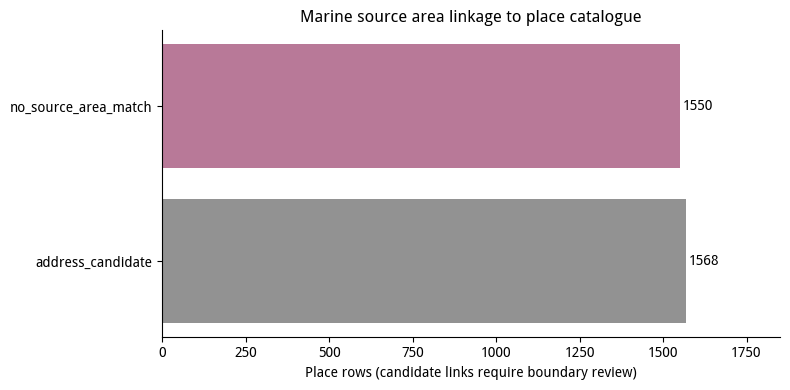

place_id,place_name,catalog_category,source_admin_candidate,admin_match_status,admin_link_verified,marine_class,is_place_visit_count,township_snapshot_period,monthly_reference_scope,recommendation_bonus,stay_multiplier,township_heatmap_visitors,month,monthly_reference_status,national_group_period_mean_index,national_group_vs_noncoastal_index,selected_top5_standard_yoy_pct
ro7,낙산해수욕장,sea,강원특별자치도 양양군 강현면,address_candidate,False,연안 어촌,False,not_encoded_in_csv; check original download period,"national group for requested observed month, not township time series",0.0,1.0,6097304.0,202608,available_observed_national_group,120.803562,83.842190,NaN
nax623,죽도해변,sea,강원특별자치도 양양군 현남면,address_candidate,False,연안 어촌,False,not_encoded_in_csv; check original download period,"national group for requested observed month, not township time series",0.0,1.0,3186040.0,202608,available_observed_national_group,120.803562,83.842190,NaN
ctt142,심복사,herit,경기도 평택시 현덕면,address_candidate,False,연안 어촌,False,not_encoded_in_csv; check original download period,"national group for requested observed month, not township time series",0.0,1.0,4966850.0,202608,available_observed_national_group,120.803562,83.842190,55.082243
ro9,동명항,sea,강원특별자치도 속초시 동명동,address_candidate,False,연안 도시,False,not_encoded_in_csv; check original download period,"national group for requested observed month, not township time series",0.0,1.0,3625202.0,202608,available_observed_national_group,118.151480,164.928487,48.190561
gj1,효우당,stay,None,no_source_area_match,False,None,False,not_encoded_in_csv; check original download period,"national group for requested observed month, not township time series",0.0,1.0,NaN,202608,unavailable_no_forecast,NaN,NaN,NaN
gjx9,문무대왕릉,sea,경상북도 경주시 문무대왕면,address_candidate,False,연안 어촌,False,not_encoded_in_csv; check original download period,"national group for requested observed month, not township time series",0.0,1.0,2069700.0,202608,available_observed_national_group,120.803562,83.842190,NaN
gz1,덕포해수욕장,sea,None,no_source_area_match,False,None,False,not_encoded_in_csv; check original download period,"national group for requested observed month, not township time series",0.0,1.0,NaN,202608,unavailable_no_forecast,NaN,NaN,NaN
gz11,원조거제굴구이,food,None,no_source_area_match,False,None,False,not_encoded_in_csv; check original download period,"national group for requested observed month, not township time series",0.0,1.0,NaN,202608,unavailable_no_forecast,NaN,NaN,NaN


In [14]:
if MARINE:
    # One row per source administrative unit. Heatmap and selected growth evidence stay distinct.
    mh_obs=mh.rename(columns={'marine_class':'heatmap_class'}).copy()
    mg_obs=mg[['admin_name','province','municipality','township','current_visitors','previous_visitors','source_ratio_pct','standard_yoy_pct','source_rank','marine_class']].rename(columns={'marine_class':'top5_class'})
    mobs=mh_obs.merge(mg_obs,on=['admin_name','province','municipality','township'],how='outer',validate='one_to_one')
    mobs['marine_class']=mobs.heatmap_class.combine_first(mobs.top5_class)
    mobs['class_conflict']=mobs.heatmap_class.notna() & mobs.top5_class.notna() & mobs.heatmap_class.ne(mobs.top5_class)
    mobs['evidence_kind']=np.select([
        mobs.heatmap_source_present.eq(True) & mobs.current_visitors.notna(),
        mobs.heatmap_source_present.eq(True) & mobs.area_visitors.notna(),
        mobs.heatmap_source_present.eq(True)],
        ['heatmap_and_selected_top5','heatmap','heatmap_metadata_only'],default='selected_top5')
    if mobs.class_conflict.any():raise ValueError('동일 읍면동의 해양 구분 충돌')
    save_csv(mobs,'marine_township_observations')
    # Candidate indexing avoids scanning all 3,564 areas for every place.
    # Aliases only standardize abbreviated spellings. Administrative mergers or
    # renamed districts are not inferred from similarity of names.
    province_aliases={
        '서울특별시':['서울특별시','서울'], '부산광역시':['부산광역시','부산'],
        '대구광역시':['대구광역시','대구'], '인천광역시':['인천광역시','인천'],
        '광주광역시':['광주광역시','광주'], '대전광역시':['대전광역시','대전'],
        '울산광역시':['울산광역시','울산'], '세종특별자치시':['세종특별자치시','세종'],
        '경기도':['경기도','경기'], '강원특별자치도':['강원특별자치도','강원도','강원'],
        '충청북도':['충청북도','충북'], '충청남도':['충청남도','충남'],
        '전북특별자치도':['전북특별자치도','전라북도','전북'],
        '전라남도':['전라남도','전남'], '경상북도':['경상북도','경북'],
        '경상남도':['경상남도','경남'], '제주특별자치도':['제주특별자치도','제주도','제주']}
    for p in mobs.province.unique():province_aliases.setdefault(p,[p])
    alias_to_province={a:p for p,aliases in province_aliases.items() for a in aliases}
    marine_town_index=defaultdict(list)
    for a in mobs.to_dict('records'):marine_town_index[a['township']].append(a)
    def marine_address_diagnosis(address):
        # Exact alphanumeric Korean tokens: 동/리/도로명 or renamed areas are not inferred.
        tokens=set(re.findall(r'[가-힣0-9]+',str(address)))
        explicit={alias_to_province[t] for t in tokens if t in alias_to_province}
        before=[]; found=[]; rejected=[]
        for town in tokens.intersection(marine_town_index):
            for a in marine_town_index[town]:
                if not set(a['municipality'].split()).issubset(tokens):continue
                before.append(a['admin_name'])
                if explicit and a['province'] not in explicit:
                    rejected.append(a['admin_name']);continue
                found.append(a['admin_name'])
        found=sorted(set(found))
        return {'candidates':found,'pre_province_candidate_count':len(set(before)),
                'province_rejected_count':len(set(rejected)),
                'province_rejected_candidates':' | '.join(sorted(set(rejected))),
                'address_province_labels':' | '.join(sorted(explicit)),
                'reason':'MATCH_CANDIDATE' if len(found)==1 else 'MULTIPLE_AREA_CANDIDATES' if len(found)>1
                         else 'PROVINCE_LABEL_CONFLICT' if rejected else 'NO_EXACT_MUNICIPALITY_TOWNSHIP_TOKENS'}
    def match_marine_address(address):return marine_address_diagnosis(address)['candidates']
    if places is not None:
        raw_key=next(c for c in ['id','ID','place_id'] if c in places_raw.columns)
        raw_address=places_raw.set_index(raw_key)['출처'].to_dict() if '출처' in places_raw else {}
        marine_places=places[['place_id','region','name','category','base_minutes','cluster_eligible']].copy()
        marine_places['address_source']=marine_places.place_id.map(raw_address).fillna('')
        address_diagnoses=marine_places.address_source.map(marine_address_diagnosis)
        candidates=address_diagnoses.map(lambda d:d['candidates'])
        audit=marine_places[['place_id','region','name','address_source']].copy()
        for col in ['pre_province_candidate_count','province_rejected_count','province_rejected_candidates','address_province_labels','reason']:
            audit[col]=address_diagnoses.map(lambda d:d[col])
        audit['candidate_count']=candidates.map(len)
        audit['candidate_admin_names']=candidates.map(lambda x:' | '.join(x))
        save_csv(audit,'marine_place_link_audit')
        marine_places['marine_match_status']=candidates.map(lambda a:'address_candidate' if len(a)==1 else 'ambiguous_address' if len(a)>1 else 'no_source_area_match')
        marine_places['marine_admin_name']=candidates.map(lambda a:a[0] if len(a)==1 else '')
        marine_places=marine_places.merge(mobs.add_prefix('marine_').rename(columns={'marine_marine_class':'marine_class'}),on='marine_admin_name',how='left',validate='many_to_one')
        marine_places['marine_admin_verified']=False
        marine_places['sea_theme_in_catalog']=marine_places.category.eq('sea')
        marine_places['marine_recommendation_bonus']=0.0
        marine_places['marine_stay_multiplier']=1.0
        marine_places['visitor_unit']='township_estimate_not_individual_place_visits'
        marine_places['monthly_context_scope']='national_group_reference_not_local_monthly_observation'
        save_csv(marine_places,'marine_place_evidence_all')
        save_csv(marine_places[marine_places.marine_match_status.eq('address_candidate')],'marine_place_candidates')
        marine_info['place_rows']=len(marine_places)
        marine_info['place_match_counts']={k:int(v) for k,v in marine_places.marine_match_status.value_counts().items()}
        marine_info['place_evidence_by_kind']={k:int(v) for k,v in marine_places.marine_evidence_kind.value_counts().items()}
        marine_info['catalog_sea_places']=int(marine_places.sea_theme_in_catalog.sum())
        coverage_by_region=marine_places.groupby('region').agg(
            place_rows=('place_id','size'),candidate_places=('marine_match_status',lambda x:int(x.eq('address_candidate').sum())),
            visitor_value_linked_places=('marine_area_visitors','count'))
        coverage_by_region['candidate_share']=coverage_by_region.candidate_places/coverage_by_region.place_rows
        save_csv(coverage_by_region.reset_index(),'marine_place_coverage_by_region')
        marine_info['place_regions_with_candidates']=int(coverage_by_region.candidate_places.gt(0).sum())
        marine_info['place_value_linked_rows']=int(marine_places.marine_area_visitors.notna().sum())
        marine_info['place_missing_value_linked_rows']=int((marine_places.marine_match_status.eq('address_candidate') & marine_places.marine_evidence_kind.eq('heatmap_metadata_only')).sum())
        marine_info['place_province_conflict_rows']=int(audit.reason.eq('PROVINCE_LABEL_CONFLICT').sum())
        marine_info['place_any_province_rejection_rows']=int(audit.province_rejected_count.gt(0).sum())

        fig,ax=plt.subplots(figsize=(8,4));counts=marine_places.marine_match_status.value_counts()
        ax.barh(counts.index,counts.values,color=['#929292','#B87998','#78618E'][:len(counts)])
        for j,v in enumerate(counts):ax.text(v+10,j,str(v),va='center')
        ax.set(title='Marine source area linkage to place catalogue',xlabel='Place rows (candidate links require boundary review)');ax.set_xlim(0,counts.max()*1.18);finish(fig,'33_marine_place_coverage')
        if city is not None:
            marine_stop_links=stops.merge(marine_places[['place_id','marine_admin_name','marine_match_status','marine_class','marine_evidence_kind']],left_on='place_id_candidate',right_on='place_id',how='left',validate='many_to_one')
            marine_stop_links=marine_stop_links[marine_stop_links.marine_match_status.eq('address_candidate')].copy()
            marine_stop_links['marine_link_verified']=False
            marine_stop_links['link_chain']='unverified_stop_candidate + address_token_candidate'
            save_csv(marine_stop_links,'marine_course_stop_candidates')
            marine_courses=course_table[['course_id','region','name','parsed_stop_count','cluster_eligible']].copy()
            gr=marine_stop_links.groupby('course_id')
            marine_courses['marine_candidate_slots']=marine_courses.course_id.map(gr.size()).fillna(0).astype(int)
            marine_courses['marine_candidate_unique_places']=marine_courses.course_id.map(gr.place_id.nunique()).fillna(0).astype(int)
            marine_courses['marine_observed_area_candidates']=marine_courses.course_id.map(gr.marine_admin_name.agg(lambda a:' | '.join(sorted(set(a))))).fillna('')
            marine_courses['marine_link_verified']=False
            marine_courses['marine_recommendation_bonus']=0.0;marine_courses['marine_stay_multiplier']=1.0
            save_csv(marine_courses,'marine_course_evidence_all')
            marine_info['course_rows']=len(marine_courses);marine_info['course_candidate_count']=int(marine_courses.marine_candidate_slots.gt(0).sum());marine_info['course_candidate_slots']=len(marine_stop_links)
            regional_courses=marine_courses.groupby('region').agg(course_rows=('course_id','size'),
                candidate_courses=('marine_candidate_slots',lambda x:int(x.gt(0).sum())),candidate_slots=('marine_candidate_slots','sum'))
            save_csv(regional_courses.reset_index(),'marine_course_coverage_by_region')

    def explain_marine_place(place_id,month):
        if marine_places is None:raise ValueError('장소 CSV가 필요합니다.')
        rows=marine_places[marine_places.place_id.eq(str(place_id))]
        if len(rows)!=1:raise ValueError('장소 ID를 확인하세요: '+str(place_id))
        a=rows.iloc[0]
        result={'place_id':a.place_id,'place_name':a['name'],'catalog_category':a.category,'source_admin_candidate':a.marine_admin_name or None,'admin_match_status':a.marine_match_status,'admin_link_verified':False,'marine_class':a.marine_class if pd.notna(a.marine_class) else None,'is_place_visit_count':False,'township_snapshot_period':'not_encoded_in_csv; check original download period','monthly_reference_scope':'national group for requested observed month, not township time series','recommendation_bonus':0.0,'stay_multiplier':1.0}
        if pd.notna(a.marine_area_visitors):result['township_heatmap_visitors']=float(a.marine_area_visitors)
        if pd.notna(a.marine_standard_yoy_pct):result['selected_top5_standard_yoy_pct']=float(a.marine_standard_yoy_pct)
        ref=mi[mi.month.eq(str(month)) & mi.group.eq(result['marine_class'])]
        result['month']=str(month);result['monthly_reference_status']='available_observed_national_group' if len(ref) else 'unavailable_no_forecast'
        if len(ref):
            b=ref.iloc[0];result['national_group_period_mean_index']=float(b.period_mean_index);result['national_group_vs_noncoastal_index']=float(b.relative_to_noncoastal_index)
        return result
    marine_examples=[]
    if marine_places is not None:
        for pid in ['ro7','nax623','ctt142','ro9','gj1','gjx9','gz1','gz11']:
            if marine_places.place_id.eq(pid).any():marine_examples.append(explain_marine_place(pid,expected[-1]))
        (RUN_DIR/'marine_explanation_examples.json').write_text(json.dumps(marine_examples,ensure_ascii=False,indent=2),encoding='utf-8')
        show_table(pd.DataFrame(marine_examples),10)



## 12 연안 관광지 검색순위와 장소 및 코스 연결
검색 목록의 원본 순위·명칭·도로명·분류·검색 건수를 그대로 보존합니다. 명칭은 공백과 구두점을 정규화하여 정확히 비교하고 지역 근거를 함께 검사합니다. 광역 또는 시군구가 충돌하면 같은 이름이어도 연결하지 않습니다. 개편 전후 구 이름의 대응을 임의로 적용하지 않습니다.

미등재·연결 실패는 검색량 0 또는 순위 101이 아닙니다. 관광지와 코스 전체 표에는 검색 건수·순위를 결측으로 남깁니다. 코스에는 연결 경유지 수와 목록 내 최상위 원본 순위만 붙이며 검색 건수를 코스 방문자 수로 합산하지 않습니다. 신규 개인 점수 가산은 0, 체류 배율은 1입니다.


검색순위 적용 {
  "status": "loaded",
  "score_bonus": 0.0,
  "stay_multiplier": 1.0,
  "rows": 100,
  "source_categories": 16,
  "source_rank_min": 1,
  "source_rank_max": 100,
  "listed_search_count": 20536923,
  "scope": "연안 전체 선택 검색순위",
  "period_in_csv": false,
  "is_visit_count": false,
  "nonlisted_values_imputed": false,
  "matched_catalogue_places": 53,
  "rank_status_counts": {
    "NAME_REGION_CANDIDATE": 53,
    "NO_EXACT_NAME": 44,
    "NAME_FOUND_REGION_REJECTED": 3
  },
  "unlinked_catalogue_rows": 3065,
  "course_candidates": 20,
  "course_stop_candidate_rows": 23
}


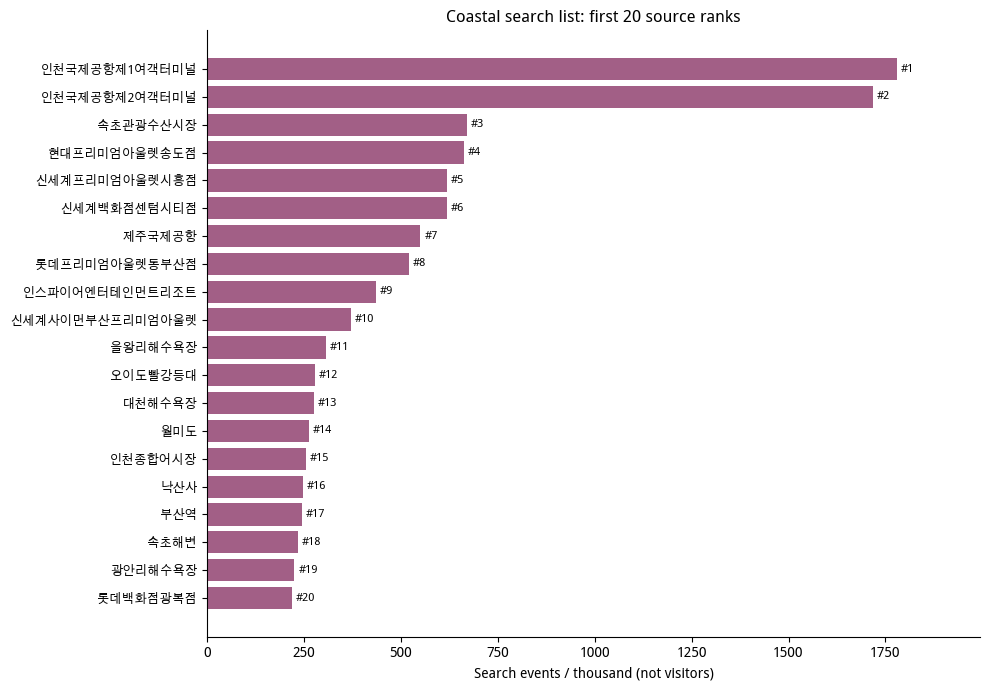

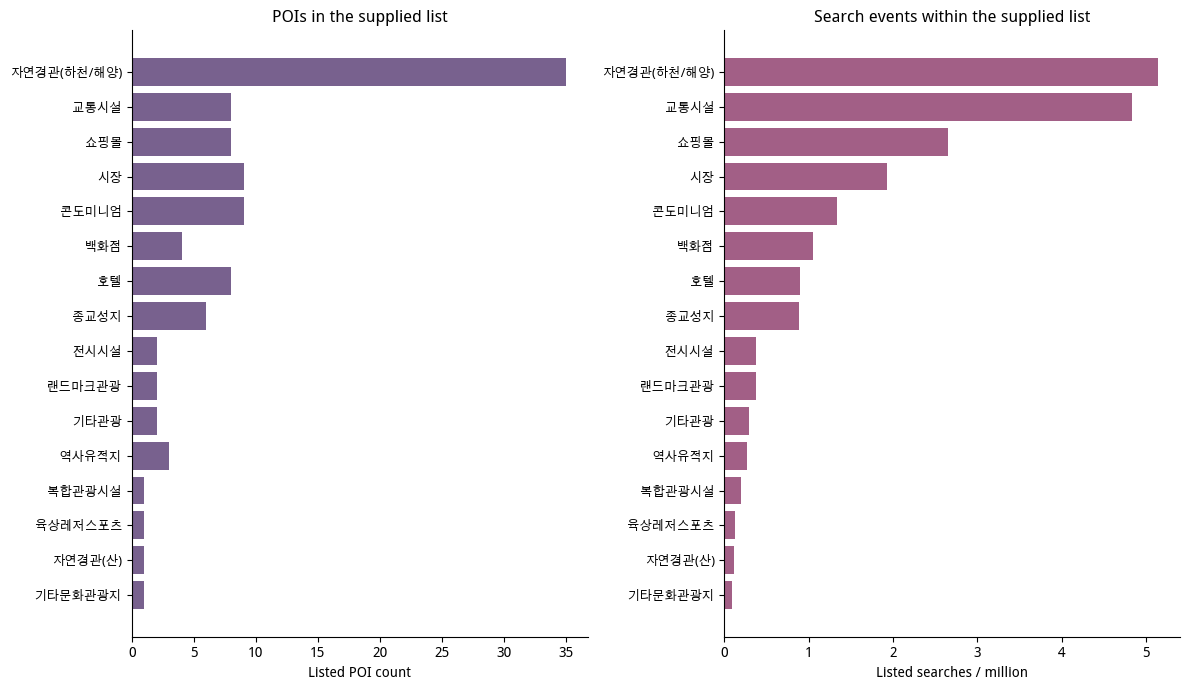

source_rank,source_name,source_category,search_count
1,인천국제공항제1여객터미널,교통시설,1780352
2,인천국제공항제2여객터미널,교통시설,1718341
3,속초관광수산시장,시장,670006
4,현대프리미엄아울렛송도점,쇼핑몰,662169
5,신세계프리미엄아울렛시흥점,쇼핑몰,617797
6,신세계백화점센텀시티점,백화점,617731
7,제주국제공항,교통시설,549967
8,롯데프리미엄아울렛동부산점,쇼핑몰,521496
9,인스파이어엔터테인먼트리조트,콘도미니엄,435699
10,신세계사이먼부산프리미엄아울렛,쇼핑몰,371165


In [15]:
# Search counts describe the supplied ranked list, not visits or unlisted zeros.
marine_search_info={'status':'not_supplied','score_bonus':0.0,'stay_multiplier':1.0}
if MARINE and 'search_rank' in MARINE:
    ms=MARINE['search_rank'].rename(columns={'순위':'source_rank','관광지명':'source_name','도로명':'source_address','분류':'source_category','검색 건수':'search_count'}).copy()
    for col in ['source_rank','search_count']:
        ms[col]=numeric_checked(ms[col],'marine search '+col)
        if (ms[col]%1!=0).any():raise ValueError('검색 순위와 건수는 정수여야 합니다.')
        ms[col]=ms[col].astype(int)
    if ms.source_rank.le(0).any() or ms.source_rank.duplicated().any():raise ValueError('검색 순위는 고유한 양의 정수여야 합니다.')
    for col in ['source_name','source_address','source_category']:
        ms[col]=ms[col].astype(str).str.strip()
        if ms[col].eq('').any():raise ValueError('검색 목록 필수 텍스트 공란: '+col)
    if ms.duplicated(['source_name','source_address']).any():raise ValueError('검색 관광지명과 주소 중복')
    ms=ms.sort_values('source_rank').reset_index(drop=True)
    ms['search_id']=ms.source_rank.map(lambda x:f'MSR{x:04d}')
    ms['name_key']=ms.source_name.map(norm_name)
    ms['scope']=INPUT_META['marine_search_rank'].get('declared_scope','not_encoded_in_csv')
    ms['period_status']='not_encoded_in_csv'
    ms['is_visit_count']=False
    if not ms.search_count.is_monotonic_decreasing:
        marine_flags.append({'check':'search_rank_order','status':'review','detail':'원본 순위와 검색 건수 내림차순이 다름; 원본 순위 유지'})
    search_alias=dict(alias_to_province)
    # This is only a spelling alias seen in the supplied source, not an old/new boundary crosswalk.
    search_alias.update({'전남광주':'전남광주통합특별시','전남광주통합특별시':'전남광주통합특별시'})
    def search_address_parts(address):
        words=re.findall(r'[가-힣A-Za-z0-9]+',str(address))
        province=search_alias.get(words[0],words[0]) if words else ''
        local=[]
        for w in words[1:]:
            if re.fullmatch(r'[가-힣]+[시군구]',w):local.append(w)
            else:break
        return province,local
    source_parts=ms.source_address.map(search_address_parts)
    ms['source_province']=source_parts.map(lambda x:x[0])
    ms['source_municipality']=source_parts.map(lambda x:' '.join(x[1]))
    ms['road_address_detail_present']=ms.source_address.map(lambda s:bool(re.search(r'[가-힣A-Za-z0-9]+(?:대로|로|길)(?:\s|$)',s)))
    save_csv(ms,'marine_search_rank_clean')
    search_class_summary=ms.groupby('source_category').agg(listed_poi_count=('search_id','size'),listed_search_count=('search_count','sum'),best_source_rank=('source_rank','min')).reset_index()
    total_search=ms.search_count.sum()
    search_class_summary['share_of_listed_searches_pct']=100*search_class_summary.listed_search_count/total_search if total_search>0 else np.nan
    search_class_summary=search_class_summary.sort_values('listed_search_count',ascending=False)
    save_csv(search_class_summary,'marine_search_class_summary')
    marine_search_info.update({'status':'loaded','rows':len(ms),'source_categories':int(ms.source_category.nunique()),'source_rank_min':int(ms.source_rank.min()),'source_rank_max':int(ms.source_rank.max()),'listed_search_count':int(total_search),'scope':ms.scope.iloc[0] if len(ms) else 'empty','period_in_csv':False,'is_visit_count':False,'nonlisted_values_imputed':False})

    fig,ax=plt.subplots(figsize=(10,7))
    top=ms.head(20).iloc[::-1]
    ax.barh(top.source_name,top.search_count/1e3,color='#A25F86')
    ax.set(title='Coastal search list: first 20 source ranks',xlabel='Search events / thousand (not visitors)')
    ax.tick_params(axis='y',labelsize=9)
    for i,row in enumerate(top.itertuples()):ax.text(row.search_count/1e3+10,i,f'#{row.source_rank}',va='center',fontsize=8)
    ax.set_xlim(0,max(1,top.search_count.max()/1e3)*1.12)
    finish(fig,'37_marine_search_top20')
    fig,axs=plt.subplots(1,2,figsize=(12,7))
    cat=search_class_summary.iloc[::-1]
    axs[0].barh(cat.source_category,cat.listed_poi_count,color='#78618E')
    axs[0].set(title='POIs in the supplied list',xlabel='Listed POI count')
    axs[1].barh(cat.source_category,cat.listed_search_count/1e6,color='#A25F86')
    axs[1].set(title='Search events within the supplied list',xlabel='Listed searches / million')
    for ax in axs:ax.tick_params(axis='y',labelsize=9)
    finish(fig,'38_marine_search_category_composition')

    def assess_search_region(source,place):
        tokens=set(re.findall(r'[가-힣A-Za-z0-9]+',str(place['address_source'])))
        region=str(place['region']).strip()
        explicit={search_alias[t] for t in tokens if t in search_alias}
        # Province-qualified catalogue labels, such as 고성(강원), keep their province.
        region_parts=re.findall(r'[가-힣A-Za-z0-9]+',region)
        explicit.update(search_alias[t] for t in region_parts if t in search_alias)
        if explicit and source.source_province not in explicit:return False,'PROVINCE_CONFLICT'
        src_local=source.source_municipality.split()
        for ending in ['시','군','구']:
            src={x for x in src_local if x.endswith(ending)}
            dst={x for x in tokens if re.fullmatch(r'[가-힣]+[시군구]',x) and x.endswith(ending) and x not in search_alias}
            if src and dst and not src.intersection(dst):return False,'MUNICIPALITY_CONFLICT'
        normalized_region=norm_region(region_parts[0]) if region_parts else ''
        municipality_match=any(normalized_region==norm_region(x) for x in src_local)
        metro_match=region in search_alias and search_alias[region]==source.source_province
        address_match=bool(src_local) and set(src_local).issubset(tokens)
        if not (municipality_match or metro_match or address_match):return False,'REGION_NOT_CONFIRMED'
        return True,'EXACT_NAME_REGION_CANDIDATE'

    if places is not None:
        raw_key=next(c for c in ['id','ID','place_id'] if c in places_raw.columns)
        addr=places_raw.set_index(raw_key)['출처'].to_dict() if '출처' in places_raw else {}
        catalogue=places[['place_id','region','name','category','cluster_eligible']].copy()
        catalogue['address_source']=catalogue.place_id.map(addr).fillna('')
        catalogue['name_key']=catalogue['name'].map(norm_name)
        name_index={k:g.to_dict('records') for k,g in catalogue.groupby('name_key')}
        audit=[];links=[]
        for source in ms.itertuples(index=False):
            name_matches=name_index.get(source.name_key,[]);accepted=[];rejected=[]
            for place in name_matches:
                ok,why=assess_search_region(source,place)
                if ok:accepted.append(place['place_id'])
                else:rejected.append({'place_id':place['place_id'],'reason':why})
            status='NAME_REGION_CANDIDATE' if len(accepted)==1 else 'AMBIGUOUS_CATALOGUE_MATCH' if len(accepted)>1 else 'NAME_FOUND_REGION_REJECTED' if name_matches else 'NO_EXACT_NAME'
            audit.append({'search_id':source.search_id,'source_rank':source.source_rank,'source_name':source.source_name,'source_address':source.source_address,'exact_name_candidates':len(name_matches),'eligible_region_candidates':len(accepted),'candidate_place_ids':' | '.join(accepted),'rejected_candidates':json.dumps(rejected,ensure_ascii=False),'status':status,'identity_verified':False})
            if len(accepted)==1:links.append({'search_id':source.search_id,'place_id':accepted[0],'search_match_status':status})
        search_audit=pd.DataFrame(audit)
        links=pd.DataFrame(links,columns=['search_id','place_id','search_match_status'])
        # Several listed entities mapping to one catalogue ID require review, never best-rank selection.
        repeated=links.place_id.duplicated(keep=False)
        if repeated.any():
            search_audit.loc[search_audit.search_id.isin(links.loc[repeated,'search_id']),'status']='MULTIPLE_SOURCE_ENTITIES_FOR_PLACE'
            links=links[~repeated].copy()
        save_csv(search_audit,'marine_search_rank_match_audit')
        evidence=links.merge(ms,on='search_id',how='left',validate='one_to_one').merge(catalogue.drop(columns='name_key'),on='place_id',how='left',validate='one_to_one')
        evidence['search_identity_verified']=False
        save_csv(evidence,'marine_search_place_candidates')
        selected=links.merge(ms[['search_id','source_rank','search_count','source_name','source_address','source_category']],on='search_id',how='left',validate='one_to_one')
        search_places=catalogue.merge(selected,on='place_id',how='left',validate='one_to_one')
        search_places['search_match_status']=search_places.search_match_status.fillna('NOT_LISTED_OR_UNRESOLVED')
        search_places['search_identity_verified']=False
        search_places['search_score_bonus']=0.0
        search_places['search_stay_multiplier']=1.0
        save_csv(search_places,'marine_search_place_evidence_all')
        marine_search_info.update({'matched_catalogue_places':len(links),'rank_status_counts':{k:int(v) for k,v in search_audit.status.value_counts().items()},'unlinked_catalogue_rows':int(search_places.source_rank.isna().sum())})
        if city is not None:
            search_stops=stops.merge(selected,left_on='place_id_candidate',right_on='place_id',how='inner',validate='many_to_one')
            search_stops['search_identity_verified']=False
            search_stops['link_chain']='unverified_route_place_candidate + unverified_name_region_candidate'
            save_csv(search_stops,'marine_search_course_stop_candidates')
            course_search=course_table[['course_id','region','name','parsed_stop_count','cluster_eligible']].copy()
            agg=search_stops.groupby('course_id').agg(search_candidate_slots=('search_id','size'),search_unique_listed_pois=('search_id','nunique'),best_listed_source_rank=('source_rank','min'),listed_poi_names=('source_name',lambda s:' | '.join(sorted(set(s))))).reset_index()
            course_search=course_search.merge(agg,on='course_id',how='left',validate='one_to_one')
            for col in ['search_candidate_slots','search_unique_listed_pois']:course_search[col]=course_search[col].fillna(0).astype(int)
            course_search['listed_poi_names']=course_search.listed_poi_names.fillna('')
            course_search['search_link_verified']=False
            course_search['search_score_bonus']=0.0;course_search['search_stay_multiplier']=1.0
            save_csv(course_search,'marine_search_course_evidence_all')
            marine_search_info.update({'course_candidates':int(course_search.search_candidate_slots.gt(0).sum()),'course_stop_candidate_rows':len(search_stops)})
        assert len(search_places)==len(places_raw)
        assert search_places.loc[search_places.search_match_status.eq('NOT_LISTED_OR_UNRESOLVED'),['source_rank','search_count']].isna().all().all()
        assert not evidence.search_identity_verified.any()
    marine_flags.append({'check':'search_scope','status':'selected_list_context_only','detail':f'선택 검색순위 {len(ms)}행; 검색 건수는 방문자 수 아님; 미등재는 0으로 대체하지 않음'})
    show_table(ms[['source_rank','source_name','source_category','search_count']],10)
RUN_SUMMARY['marine_search']=marine_search_info
print('검색순위 적용',json.dumps(marine_search_info,ensure_ascii=False,indent=2))


## 13 전국 해양 적용 범위와 검증
전국 조회 히트맵의 모든 행을 반영하고 빈 방문값을 보존합니다. 입력은 방문 규모 한 변수와 연안 범주를 가진 단면 자료이므로 새로운 다변량 해양 군집을 학습하지 않습니다. 월별 파일의 전국·연안 전체는 하위 집계군과 중복되는 평균 자료입니다.

전국 장소와 코스에 지역 관측 근거를 다시 연결하고, 기존 구면 코사인 군집 및 설문 점수는 같은 입력으로 다시 실행합니다. 지역 방문 규모를 개인 선호나 실측 체류시간으로 변환하지 않습니다. 원본 광역 표기·기간·행정 코드의 확인 상태는 실행 요약과 품질표에 남깁니다.

추가 검색순위는 원본 분류·명칭·도로명·건수를 보존하고 이름과 지역의 정확 일치 후보만 연결합니다. Top5의 연안 구분은 히트맵에서 확인하며 읍면동 접미사로 추정하지 않습니다.


In [16]:
if MARINE:
    assert not mt.duplicated(['month','group']).any()
    assert len(mh)==len(MARINE['heatmap']) and not mh.admin_name.duplicated().any()
    assert mh.loc[mh.visitor_value_missing,'area_visitors'].isna().all()
    assert mh.loc[~mh.visitor_value_missing,'area_visitors'].ge(0).all()
    assert int(national_group.source_rows.sum())==len(mh)
    assert int(national_group.valid_visitor_rows.sum())==int(mh.area_visitors.notna().sum())
    assert len(mi)==len(mt)
    assert np.allclose(mi.groupby('group').period_mean_index.mean(),100)
    assert marine_info['new_marine_clustering_fitted'] is False
    if marine_places is not None:
        assert len(marine_places)==len(places_raw)
        assert not marine_places.marine_admin_verified.any()
        assert marine_places.marine_recommendation_bonus.eq(0).all()
        assert marine_places.marine_stay_multiplier.eq(1).all()
    if marine_courses is not None:assert len(marine_courses)==len(cities_raw)
    marine_flags.append({'check':'heatmap_missing_visitors','status':'preserved',
                         'detail':f'결측 {mh.visitor_value_missing.sum()}행 보존; 방문자 수 0 대체 없음'})
    marine_flags.append({'check':'admin_labels','status':'review',
                         'detail':'원본 광역·시군구 표기를 보존하고 미검증 개편 명칭은 자동 치환하지 않음; 충돌 후보는 audit에 기록'})
    marine_flags.append({'check':'admin_link' ,'status':'candidate_only','detail':'출처 주소의 시군구·읍면동 토큰 후보 연결; 행정동 코드·경계 검증 미완료'})
    save_csv(pd.DataFrame(marine_flags),'marine_quality_flags')
    fields=[
        ['period_mean_index','100 × 해당 월 평균 / 관측 기간 월평균의 평균','지수','반복 계절성·미래값 아님'],
        ['relative_to_noncoastal_index','100 × 해당 집계군 월평균 / 같은 월 비연안 평균','지수','지역 총량이나 1인당 소비 아님'],
        ['standard_yoy_pct','100 × (현재−전년) / 전년','%','전년 값 0이면 결측'],
        ['current_denominator_pct','100 × (현재−전년) / 현재','%','원본 비율의 분모 검증용'],
        ['marine_admin_name','출처 주소에서 찾은 시군구+읍면동 후보','이름','행정 경계 확인 전 잠정'],
        ['marine_area_visitors','히트맵 원본 읍면동 방문 추정값','방문 추정값','장소 자체 방문자 수 아님'],
        ['search_count','검색순위 CSV의 검색 건수','검색 건수','방문자 수·미등재 0점으로 해석하지 않음'],
        ['best_listed_source_rank','연결된 검색 목록 경유지 중 원본 순위 최솟값','순위','코스 인기 순위가 아니며 미연결은 결측'],
        ['marine_recommendation_bonus','0','점','검증 전 개인 적합도에 미반영'],
        ['marine_stay_multiplier','1','배','체류시간 관측값 없음']]
    save_csv(pd.DataFrame(fields,columns=['field','formula_or_source','unit','interpretation']),'marine_field_dictionary')
    (RUN_DIR/'marine_summary.json').write_text(json.dumps(marine_info,ensure_ascii=False,indent=2),encoding='utf-8')
    RUN_SUMMARY['marine']=marine_info
    print('해양 확장 완료',json.dumps(marine_info,ensure_ascii=False,indent=2))


해양 확장 완료 {
  "method_version": "marine-input-context-2.1",
  "period_start": "202509",
  "period_end": "202608",
  "months": 12,
  "heatmap_rows": 3564,
  "heatmap_municipalities": [
    "가평군",
    "강남구",
    "강동구",
    "강릉시",
    "강북구",
    "강서구",
    "강진군",
    "강화군",
    "거제시",
    "거창군",
    "검단구",
    "경산시",
    "경주시",
    "계룡시",
    "계양구",
    "고령군",
    "고성군",
    "고양시 덕양구",
    "고양시 일산동구",
    "고양시 일산서구",
    "고창군",
    "고흥군",
    "곡성군",
    "공주시",
    "과천시",
    "관악구",
    "광명시",
    "광산구",
    "광양시",
    "광주시",
    "광진구",
    "괴산군",
    "구례군",
    "구로구",
    "구리시",
    "구미시",
    "군산시",
    "군위군",
    "군포시",
    "금산군",
    "금정구",
    "금천구",
    "기장군",
    "김제시",
    "김천시",
    "김포시",
    "김해시",
    "나주시",
    "남구",
    "남동구",
    "남양주시",
    "남원시",
    "남해군",
    "노원구",
    "논산시",
    "단양군",
    "달서구",
    "달성군",
    "담양군",
    "당진시",
    "대덕구",
    "도봉구",
    "동구",
    "동대문구",
    "동두천시",
    "동래구",
    "동작구",
    "동해시",
    "마포구",
    "목포시",
    "무안군",
    "무주군",
    "문경시",

## 14 코사인 군집화의 산식과 비교 기준

전처리·가중치가 적용된 기존 특성을 $X_i$, 정규화된 행을 $u_i=X_i/\|X_i\|_2$라고 합니다. 원점은 기존 전처리가 정합니다. G/T의 로그 연속 특성은 중앙값보다 작은 값이 음수일 수 있습니다. 음수는 관심 없음이 아니라 기준보다 낮은 값입니다. 0벡터는 제외하고 기록합니다.

$$\cos(u_i,c_j)=u_i^\mathsf{T}c_j,\quad d_{cos}=1-\cos$$
$$z_i=\arg\max_j u_i^\mathsf{T}c_j,\quad c_j=\frac{\sum_{i:z_i=j}u_i}{\|\sum_{i:z_i=j}u_i\|_2}$$

입력과 중심을 모두 정규화하는 **구면 K-means**입니다. 단순히 정규화 입력에 일반 K-means를 적용하는 것과 구분합니다. 중심화한 PCA 좌표에서 코사인을 계산하지 않습니다. 전체 목적함수는 배정 유사도의 합이며 감소 여부와 고정점 수렴을 검사합니다.

각 k에서 3개 seed × 20회 초기화를 실행합니다. 최소 ARI 0.8, 군집 최소 비중 2%를 통과한 구면 후보 중 코사인 실루엣 평균이 가장 높은 k를 선택합니다.  통과 후보가 없으면 탐색 결과로 표시합니다. 최종 배정은 seed 42입니다.

실루엣은 같은 표본의 같은 원래 특성에서 코사인 거리와 유클리드 거리로 각각 계산합니다. **서로 다른 거리의 실루엣 숫자를 직접 비교하여 향상을 주장하지 않습니다.** 기존 선택 모델과 새 모델의 비교 외에 같은 k의 PCA K-means도 대조군으로 계산합니다. 군집 수 선택에 쓴 내부 지표이며 외부 검증 정확도가 아닙니다.


G {
  "rows": 2549,
  "excluded_zero_vectors": 0,
  "features": [
    "cat_herit",
    "cat_heal",
    "cat_activity",
    "cat_food",
    "cat_sea",
    "log_stay_robust",
    "unesco_mark"
  ],
  "k": 10,
  "search_max_k": 10,
  "at_search_upper_bound": true,
  "cosine_silhouette_mean": 0.829579482096141,
  "cosine_silhouette_final_seed": 0.8342157070246453,
  "negative_silhouette_share": 0.0,
  "seed_ari_min": 0.9781027633160397,
  "min_cluster_share_across_seeds": 0.023538642604943115,
  "passes_gates": true,
  "min_share_required": 0.02,
  "sample_n": 1200,
  "ari_vs_baseline": 0.8315432423494977,
  "mean_assigned_cosine": 0.9738419589306415,
  "mean_assignment_margin": 0.32008738794016794,
  "iterations": 3,
  "final_seed": 42,
  "fit_space": "L2-normalized baseline weighted features; no PCA centering",
  "status": "QUALIFIED_EXPLORATORY"
}
T {
  "rows": 179,
  "excluded_zero_vectors": 0,
  "features": [
    "share_herit",
    "share_heal",
    "share_activity",
    "share_food",

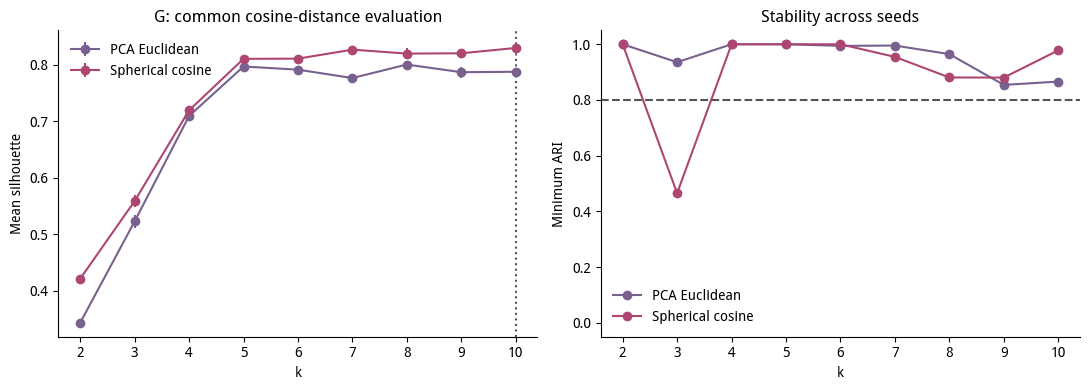

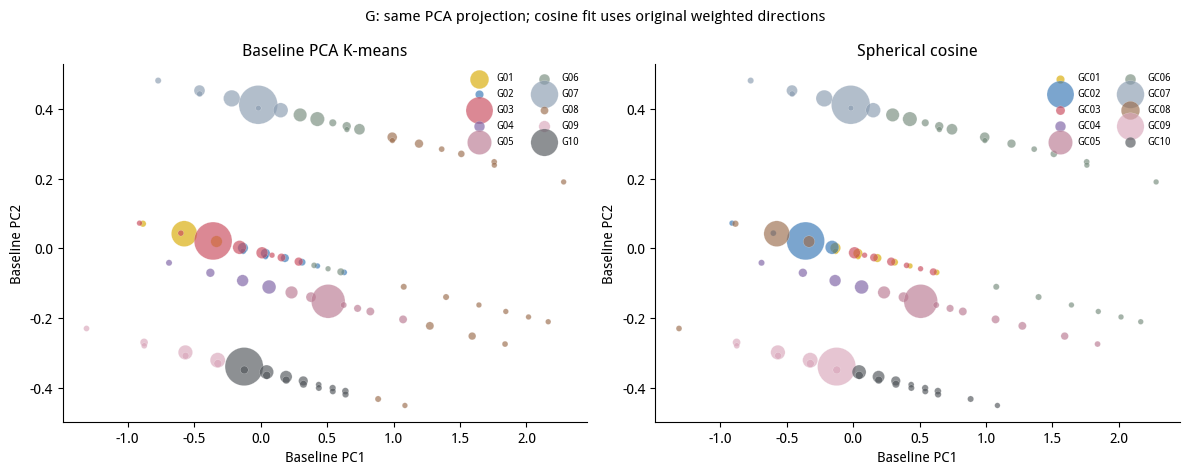

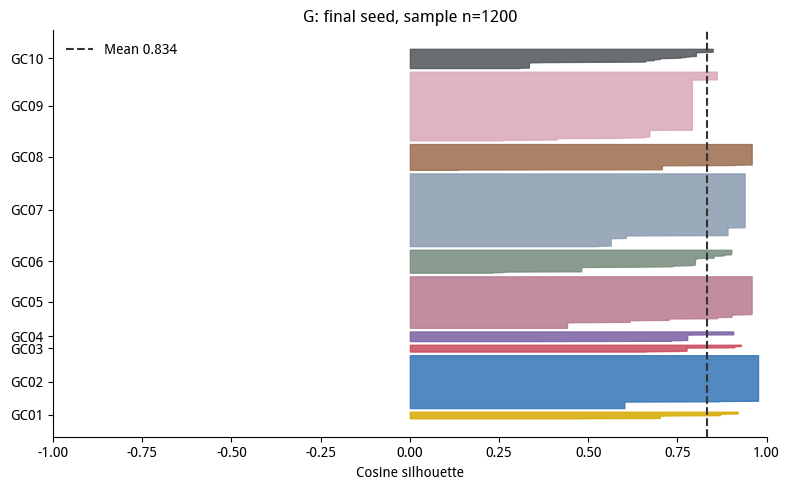

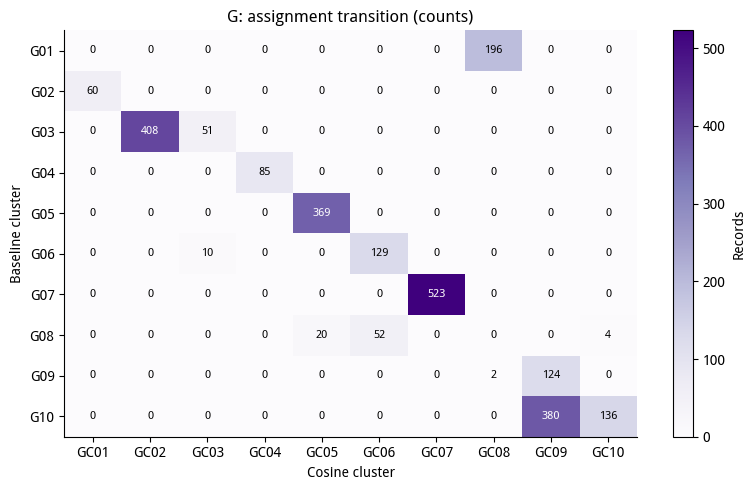

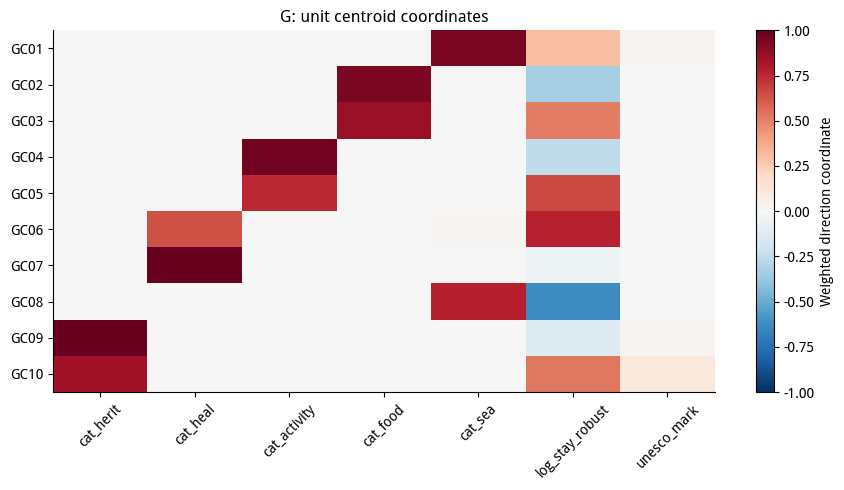

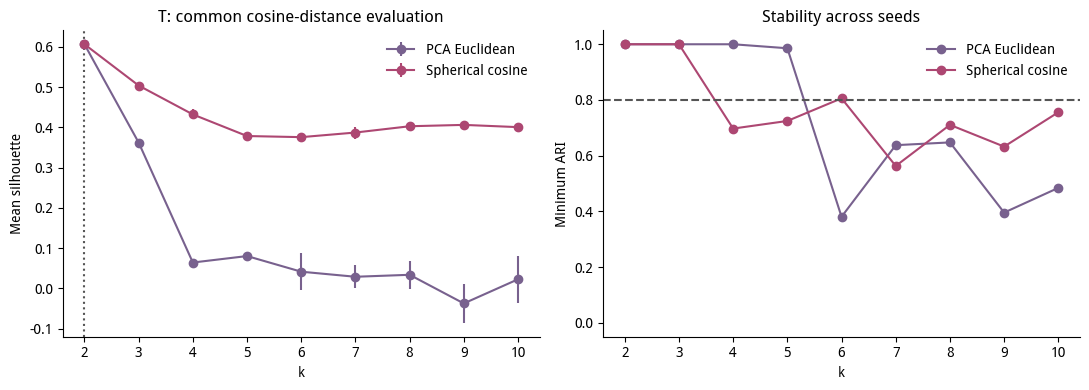

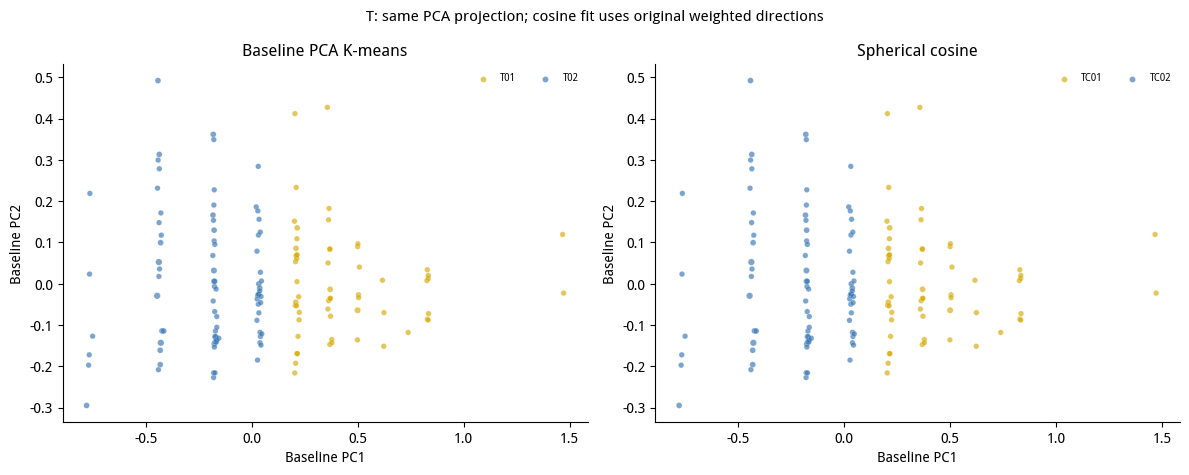

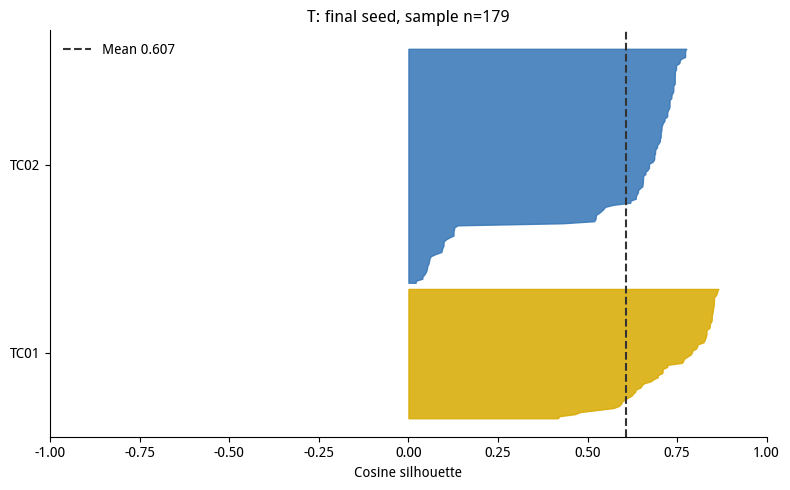

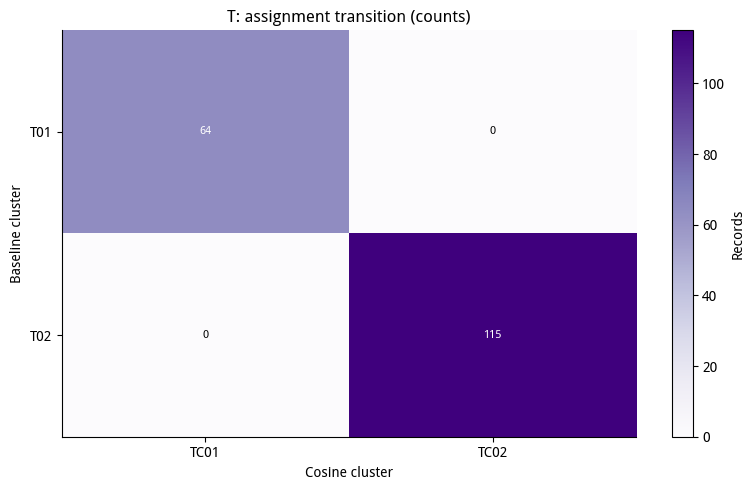

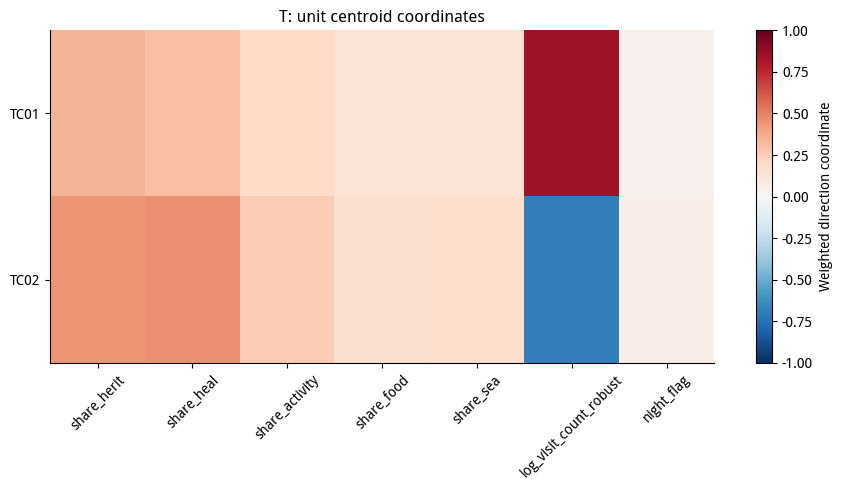

dataset,model,k,n,sample_n,cosine_silhouette,euclidean_silhouette
G,baseline_selected,10,2549,1200,0.787109,0.711017
G,cosine_selected,10,2549,1200,0.834216,0.707061
T,baseline_selected,2,179,179,0.606552,0.379631
T,cosine_selected,2,179,179,0.606552,0.379631


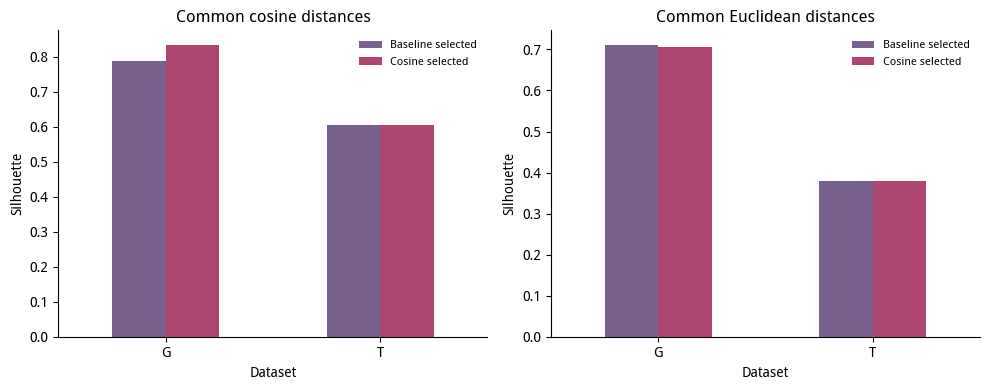

In [17]:
# This module is embedded in the delivered notebook. No external import is needed.
from sklearn.metrics import silhouette_samples
from sklearn.metrics.pairwise import cosine_similarity

COSINE_RESULTS = {}
COSINE_COMPARISONS = []

def unit_rows(X, eps=1e-12):
    X = np.asarray(X, dtype=float)
    if X.ndim != 2 or not np.isfinite(X).all():
        raise ValueError('코사인 입력은 결측이 없는 2차원 수치 배열이어야 합니다.')
    norms = np.linalg.norm(X, axis=1)
    valid = norms > eps
    return X[valid] / norms[valid, None], valid, norms

def spherical_kmeans(U, k, seed=42, n_init=20, max_iter=200):
    """Unit data AND unit centroids; maximizes sum of assigned cosine similarities.

    Reject collapsed or nonconverged starts. A successful start must reach a
    label fixed point. A plain data bundle, not a custom class, is serialized.
    """
    U = np.asarray(U, float)
    if not np.allclose(np.linalg.norm(U, axis=1), 1, atol=1e-10):
        raise ValueError('구면 K-means에는 길이 1인 행만 입력합니다.')
    if k < 2 or k > len(np.unique(U.round(12), axis=0)):
        raise ValueError('군집 수가 유효한 서로 다른 방향 수를 벗어납니다.')
    rng = np.random.default_rng(seed)
    best = None; rejected = 0
    for restart in range(n_init):
        chosen = [int(rng.integers(len(U)))]; centers = [U[chosen[0]].copy()]
        # Squared chord distance is 2 * (1 - cosine). Constant 2 cancels.
        for _ in range(1, k):
            d = np.clip(1 - (U @ np.array(centers).T).max(axis=1), 0, 2)
            d[chosen] = 0
            d[d < 1e-12] = 0
            if d.sum() <= 0: break
            j = int(rng.choice(len(U), p=d/d.sum()))
            chosen.append(j); centers.append(U[j].copy())
        if len(centers) != k:
            rejected += 1; continue
        C = np.array(centers); labels = (U @ C.T).argmax(axis=1)
        history = [float((U * C[labels]).sum())]
        converged = False
        for iteration in range(max_iter):
            counts = np.bincount(labels, minlength=k)
            if np.any(counts == 0): break
            sums = np.zeros((k, U.shape[1])); np.add.at(sums, labels, U)
            lengths = np.linalg.norm(sums, axis=1)
            if np.any(lengths <= 1e-12): break
            C = sums / lengths[:, None]
            new_labels = (U @ C.T).argmax(axis=1)
            objective = float((U * C[new_labels]).sum())
            if objective + 1e-8 < history[-1]:
                raise AssertionError('구면 목적함수가 감소했습니다.')
            history.append(objective)
            if np.array_equal(new_labels, labels):
                converged = True; labels = new_labels; break
            labels = new_labels
        if not converged:
            rejected += 1; continue
        if best is None or objective > best['objective'] + 1e-10:
            best = {'labels': labels.copy(), 'centers': C.copy(), 'objective': objective,
                    'n_iter': iteration + 1, 'history': history, 'restart': restart}
    if best is None:
        raise RuntimeError(f'k={k}, seed={seed}: 수렴한 초기화가 없습니다. 입력 방향과 k를 점검하세요.')
    best['rejected_starts'] = rejected
    return best

def fit_cosine_extension(base, prefix, k_max=10, min_share=.02):
    # Reuse exactly the baseline weighted features. No PCA centering here.
    F = base['F']; X = F.to_numpy(float)
    U, valid, norms = unit_rows(X)
    kept = np.flatnonzero(valid); index = F.index[valid]
    exclusion = pd.DataFrame({'source_index': F.index, 'norm': norms,
                              'cosine_eligible': valid,
                              'reason': np.where(valid, 'ELIGIBLE', 'ZERO_VECTOR')})
    save_csv(exclusion, prefix+'_cosine_eligibility')
    max_k = min(k_max, len(U)-1, len(np.unique(U.round(12), axis=0))-1)
    if max_k < 2:
        print(prefix, '코사인 분석 생략: 서로 다른 비영 방향이 3개 미만입니다.'); return None
    sample = np.sort(np.random.default_rng(SEEDS[0]).choice(len(U), min(len(U), SILHOUETTE_SAMPLE), replace=False))
    Dc = np.clip(1 - U[sample] @ U[sample].T, 0, 2); np.fill_diagonal(Dc, 0)
    De = pairwise_distances(X[valid][sample]); np.fill_diagonal(De, 0)
    def sil(labels, D):
        q = labels[sample]
        return float(silhouette_score(D, q, metric='precomputed')) if 1 < len(np.unique(q)) < len(q) else np.nan
    rows = []; fitted = {}
    with threadpool_limits(limits=1):
        for k in range(2, max_k+1):
            for mode in ['pca_euclidean_control', 'spherical_cosine']:
                labs = []; cos_values = []; eu_values = []; sizes = []; objectives = []; rejects = []
                for seed in SEEDS:
                    if mode == 'spherical_cosine':
                        fit = spherical_kmeans(U, k, seed, COSINE_N_INIT, COSINE_MAX_ITER)
                        labels = fit['labels']; objectives.append(fit['objective']/len(U)); rejects.append(fit['rejected_starts'])
                        fitted[(k, seed)] = fit
                    else:
                        labels = KMeans(n_clusters=k, n_init=N_INIT, random_state=seed, algorithm='lloyd').fit_predict(base['Z'][valid])
                    labs.append(labels); cos_values.append(sil(labels, Dc)); eu_values.append(sil(labels, De))
                    sizes.append(np.bincount(labels, minlength=k).min()/len(U))
                ari = min(adjusted_rand_score(a,b) for a,b in itertools.combinations(labs,2))
                rows.append({'model':mode,'k':k,'cosine_silhouette_mean':np.nanmean(cos_values),
                             'cosine_silhouette_sd':np.nanstd(cos_values),'euclidean_silhouette_mean':np.nanmean(eu_values),
                             'seed_ari_min':ari,'min_cluster_share':min(sizes),
                             'mean_assigned_cosine':np.mean(objectives) if objectives else np.nan,
                             'rejected_starts':sum(rejects),
                             'passes_gates':bool(ari>=MIN_SEED_ARI and min(sizes)>=min_share)})
    candidates = pd.DataFrame(rows)
    spherical = candidates[candidates.model.eq('spherical_cosine')]
    pool = spherical[spherical.passes_gates]; qualified = not pool.empty
    if pool.empty: pool = spherical
    selected = pool.sort_values(['cosine_silhouette_mean','k'], ascending=[False,True]).iloc[0]
    k = int(selected.k); final = fitted[(k, SEEDS[0])]
    order = sorted(range(k), key=lambda lab:tuple(X[valid][final['labels']==lab].mean(axis=0).round(10)))
    label_map = {old:f'{prefix}C{j+1:02d}' for j,old in enumerate(order)}
    names = np.array([label_map[x] for x in final['labels']]); centers = final['centers'][order]
    similarities = U @ centers.T
    top = np.sort(similarities,axis=1)
    baseline_labels = np.asarray(base['labels'])[valid]
    assignments = pd.DataFrame({'source_index':index,'baseline_cluster':baseline_labels,'cosine_cluster':names,
                                'assigned_cosine':top[:,-1], 'margin_to_second':top[:,-1]-top[:,-2]})
    ss = silhouette_samples(Dc, final['labels'][sample], metric='precomputed')
    sample_table = assignments.iloc[sample].copy(); sample_table['cosine_silhouette']=ss
    cross = pd.crosstab(assignments.baseline_cluster, assignments.cosine_cluster)
    for method, labels in [('baseline_selected',baseline_labels),('cosine_selected',final['labels'])]:
        COSINE_COMPARISONS.append({'dataset':prefix,'model':method,'k':len(np.unique(labels)),
                                  'n':len(U),'sample_n':len(sample),
                                  'cosine_silhouette':sil(labels,Dc),'euclidean_silhouette':sil(labels,De)})
    info = {'rows':len(U),'excluded_zero_vectors':int((~valid).sum()),'features':F.columns.tolist(),
            'k':k,'search_max_k':max_k,'at_search_upper_bound':k==max_k,
            'cosine_silhouette_mean':float(selected.cosine_silhouette_mean),
            'cosine_silhouette_final_seed':float(ss.mean()),'negative_silhouette_share':float((ss<0).mean()),
            'seed_ari_min':float(selected.seed_ari_min),'min_cluster_share_across_seeds':float(selected.min_cluster_share),
            'passes_gates':qualified,'min_share_required':min_share,'sample_n':len(sample),
            'ari_vs_baseline':float(adjusted_rand_score(baseline_labels,names)),
            'mean_assigned_cosine':float(top[:,-1].mean()),'mean_assignment_margin':float((top[:,-1]-top[:,-2]).mean()),
            'iterations':final['n_iter'],'final_seed':SEEDS[0],
            'fit_space':'L2-normalized baseline weighted features; no PCA centering',
            'status':'QUALIFIED_EXPLORATORY' if qualified else 'EXPLORATORY_GATES_FAILED'}
    save_csv(candidates,prefix+'_cosine_candidates')
    save_csv(assignments,prefix+'_cosine_assignments')
    save_csv(sample_table,prefix+'_cosine_silhouette_samples')
    save_csv(cross.reset_index(),prefix+'_baseline_cosine_transition')
    save_csv(pd.DataFrame(centers,columns=F.columns).assign(cosine_cluster=[label_map[j] for j in order]),prefix+'_cosine_centers')
    save_csv(pd.DataFrame(U,index=index,columns=F.columns).rename_axis('source_index').reset_index(),prefix+'_cosine_unit_features')
    save_csv(pd.DataFrame({'iteration':range(len(final['history'])),'cosine_objective':final['history']}),prefix+'_cosine_objective')
    # Portable bundle with only standard arrays, dicts, numbers and strings.
    preprocess = joblib.load(MODELS/f'{prefix}_pca_kmeans.joblib')['preprocess']
    joblib.dump({'method':'spherical-cosine-1.0','features':F.columns.tolist(),'preprocess':preprocess,
                 'centers':centers,'cluster_names':[label_map[j] for j in order],
                 'normalization':'row L2; reject norm <= 1e-12','summary':info},MODELS/f'{prefix}_spherical_cosine.joblib')
    # Same baseline PCA projection for direct visual comparison; never used to fit cosine model.
    xy = base['pcs'].loc[index].iloc[:,:2].to_numpy()
    if xy.shape[1]==1: xy=np.column_stack([xy[:,0],np.zeros(len(xy))])
    fig,axs=plt.subplots(1,2,figsize=(11,4))
    for mode,col,label in [('pca_euclidean_control','#78618E','PCA Euclidean'),('spherical_cosine','#AD4772','Spherical cosine')]:
        q=candidates[candidates.model.eq(mode)]
        axs[0].errorbar(q.k,q.cosine_silhouette_mean,yerr=q.cosine_silhouette_sd,marker='o',color=col,label=label)
        axs[1].plot(q.k,q.seed_ari_min,'o-',color=col,label=label)
    axs[0].set(title=f'{prefix}: common cosine-distance evaluation',xlabel='k',ylabel='Mean silhouette');axs[0].axvline(k,color='#555',ls=':')
    axs[1].set(title='Stability across seeds',xlabel='k',ylabel='Minimum ARI',ylim=(-.05,1.05));axs[1].axhline(MIN_SEED_ARI,color='#555',ls='--')
    for ax in axs:ax.legend(frameon=False);ax.set_xticks(range(2,max_k+1))
    finish(fig,f'C_{prefix}_01_model_comparison')
    fig,axs=plt.subplots(1,2,figsize=(12,4.8))
    for ax,lab,title in [(axs[0],baseline_labels,'Baseline PCA K-means'),(axs[1],names,'Spherical cosine')]:
        frame=pd.DataFrame({'x':xy[:,0].round(8),'y':xy[:,1].round(8),'label':lab})
        counts=frame.groupby(['x','y','label']).size().reset_index(name='n')
        for j,g in enumerate(sorted(set(lab))):
            q=counts[counts.label.eq(g)];ax.scatter(q.x,q.y,s=14+2*q.n,alpha=.65,label=g,color=PALETTE[j%len(PALETTE)],edgecolors='white',linewidth=.2)
        ax.set(title=title,xlabel='Baseline PC1',ylabel='Baseline PC2');ax.legend(fontsize=7,frameon=False,ncol=2)
    fig.suptitle(f'{prefix}: same PCA projection; cosine fit uses original weighted directions',fontsize=11)
    finish(fig,f'C_{prefix}_02_pca_projection')
    fig,ax=plt.subplots(figsize=(8,5));bottom=0;ticks=[];ticklabels=[]
    for j,g in enumerate(sorted(set(names))):
        values=np.sort(ss[names[sample]==g]); y=np.arange(bottom,bottom+len(values))
        ax.fill_betweenx(y,0,values,color=PALETTE[j%len(PALETTE)],alpha=.85)
        ticks.append(bottom+len(values)/2);ticklabels.append(g);bottom+=len(values)+max(2,len(sample)//100)
    ax.axvline(ss.mean(),color='#333',ls='--',label=f'Mean {ss.mean():.3f}')
    ax.set(yticks=ticks,yticklabels=ticklabels,xlim=(-1,1),xlabel='Cosine silhouette',title=f'{prefix}: final seed, sample n={len(sample)}');ax.legend(frameon=False)
    finish(fig,f'C_{prefix}_03_silhouette')
    fig,ax=plt.subplots(figsize=(8,5));im=ax.imshow(cross,cmap='Purples',aspect='auto')
    ax.set(xticks=np.arange(len(cross.columns)),xticklabels=cross.columns,yticks=np.arange(len(cross)),yticklabels=cross.index,
           xlabel='Cosine cluster',ylabel='Baseline cluster',title=f'{prefix}: assignment transition (counts)')
    for i in range(len(cross)):
        for j in range(len(cross.columns)):ax.text(j,i,str(cross.iloc[i,j]),ha='center',va='center',fontsize=8,color='white' if cross.iloc[i,j]>cross.to_numpy().max()*.55 else 'black')
    fig.colorbar(im,ax=ax,label='Records');finish(fig,f'C_{prefix}_04_transition')
    fig,ax=plt.subplots(figsize=(9,5));im=ax.imshow(centers,cmap='RdBu_r',vmin=-1,vmax=1,aspect='auto')
    ax.set(xticks=np.arange(len(F.columns)),xticklabels=F.columns,yticks=np.arange(k),yticklabels=[label_map[j] for j in order],title=f'{prefix}: unit centroid coordinates')
    ax.tick_params(axis='x',rotation=45);fig.colorbar(im,ax=ax,label='Weighted direction coordinate');finish(fig,f'C_{prefix}_05_centroids')
    assert np.allclose(np.linalg.norm(centers,axis=1),1)
    assert np.array_equal(np.array([label_map[j] for j in order])[similarities.argmax(axis=1)],names)
    assert np.all(np.diff(final['history']) >= -1e-8)
    print(prefix,json.dumps(info,ensure_ascii=False,indent=2))
    result={'assignments':assignments,'summary':info,'centers':centers,'U':U,'index':index,'candidates':candidates}
    COSINE_RESULTS[prefix]=result;return result

if place_model is not None:
    fit_cosine_extension(place_model,'G',K_MAX,MIN_CLUSTER_SHARE)
if city_model is not None:
    fit_cosine_extension(city_model,'T',K_MAX,MIN_CLUSTER_SHARE)

# Full original-row outputs and interpretable profiles, without overwriting G/T labels.
for prefix,base_raw,clean,name in [('G',places_raw,places,'G_places_with_cosine_all'),('T',cities_raw,globals().get('course_table'),'T_citytours_with_cosine_all')]:
    if prefix not in COSINE_RESULTS:continue
    a=COSINE_RESULTS[prefix]['assignments'].set_index('source_index')
    full=pd.concat([base_raw,clean.add_prefix('baseline_')],axis=1).join(a.add_prefix('cosine_'))
    save_csv(full,name)
    interpretation=clean.loc[a.index].join(a[['cosine_cluster','assigned_cosine','margin_to_second']])
    if prefix=='G':
        profiles=interpretation.groupby('cosine_cluster').agg(n=('place_id','size'),base_minutes_median=('base_minutes','median'),unesco_mark_rate=('unesco_mark','mean'))
        profiles=profiles.join(pd.crosstab(interpretation.cosine_cluster,interpretation.category,normalize='index').reindex(columns=CATEGORIES,fill_value=0))
    else:
        profiles=interpretation.groupby('cosine_cluster')[[f'share_{c}' for c in CATEGORIES]+['visit_candidate_count','category_coverage','night_flag']].mean()
        profiles.insert(0,'n',interpretation.groupby('cosine_cluster').size())
    save_csv(profiles.reset_index(),prefix+'_cosine_profiles')
    representative=interpretation.sort_values(['cosine_cluster','assigned_cosine'],ascending=[True,False]).groupby('cosine_cluster').head(3)
    save_csv(representative.reset_index(),prefix+'_cosine_representatives')

cosine_comparison=pd.DataFrame(COSINE_COMPARISONS)
if len(cosine_comparison):
    save_csv(cosine_comparison,'cosine_baseline_comparison');show_table(cosine_comparison,20)
    fig,axs=plt.subplots(1,2,figsize=(10,4))
    for ax,metric,title in [(axs[0],'cosine_silhouette','Common cosine distances'),(axs[1],'euclidean_silhouette','Common Euclidean distances')]:
        pivot=cosine_comparison.pivot(index='dataset',columns='model',values=metric)
        pivot.plot.bar(ax=ax,color=['#78618E','#AD4772']);ax.set(title=title,ylabel='Silhouette',xlabel='Dataset');ax.tick_params(axis='x',rotation=0);ax.legend(['Baseline selected','Cosine selected'],fontsize=8,frameon=False)
    finish(fig,'C_all_metrics_comparison')
RUN_SUMMARY['cosine']={k:v['summary'] for k,v in COSINE_RESULTS.items()}


## 15 결과 파일과 해석

`*_cosine_candidates.csv`는 k별 실루엣·ARI·최소 군집 크기, `*_cosine_assignments.csv`는 대상별 새 군집·중심 유사도·차순위와의 차이를 제공합니다. 이 차이는 신뢰확률이 아닙니다. `*_cosine_profiles.csv`와 `*_cosine_representatives.csv`로 실제 장소·코스 이름을 확인하세요. `*_with_cosine_all.csv`는 원본 전체 행과 기존·신규 군집을 함께 보존합니다.

`cosine_baseline_comparison.csv`의 같은 거리 열 안에서 비교합니다. 군집 간 이동은 transition 표와 그림에 나타납니다. PCA 투영 그림은 기존 축에 양쪽 결과를 표시하며 새 모델의 학습 공간은 아닙니다. 해양 자료는 기존 설명 지표를 유지하며 불완전한 지역 표본에 추가 전국 군집을 적합하지 않습니다.


## 16 설문에서 시티투어 점수까지

선호 항목은 역사문화·자연휴양·활동체험·미식·해양의 5개이며 각각 0~5 정수입니다. 질문, CSV 열, 응답 의미는 `cosine_survey_dictionary.csv`에 저장됩니다. `survey_responses_template.csv`의 열을 유지해 응답을 넣은 후 노트북 폴더에 `survey_responses.csv`로 저장하세요. 빈 `desired_region`은 전국, 값이 있으면 원본 `지역`과 정확히 같은 코스만 남깁니다. 모두 0이면 점수를 만들지 않습니다.

$$Q(u,t)=100\cos(q_u,p_t),\quad A(u,t)=Q(u,t)\times coverage_t$$
$$Contribution_f=100\frac{q_f p_f}{\|q\|_2\|p\|_2}\times coverage_t,\quad A=\sum_f Contribution_f$$

`cosine_fit_score`는 구성 적합도, `coverage_adjusted_score`는 분류된 경유지 비율을 반영한 후보 점수입니다. coverage 조정은 설계 규칙이며 실측 만족도로 추정한 계수가 아닙니다. **미분류 경유지가 많은 코스가 같은 방향이라는 이유만으로 만점을 받지 않게 합니다.** 최소 분류율 0.5 등 기존 분석 가능 조건을 통과한 코스만 사용합니다. 분류율은 장소 신원 확인율과 다릅니다.

GC/TC 군집 번호는 점수에 가산하지 않습니다. 군집은 설명과 후보 탐색, 개인 점수는 개별 코스의 5개 구성비를 사용합니다. 동점은 공동 순위이며 course_id는 화면 정렬에만 사용합니다. 운행일·좌석·이동시간 확인은 이 CSV만으로 검증되지 않으므로 예약 가능 여부로 표시하지 않습니다. 체류 산식, 성연령·한류 보정, 소비·해양 가산은 이번 코사인 실행에서 새로 추정하지 않습니다.


실제 설문 CSV 없음: 명시적 가상 응답 4개로 계산 구조만 시연합니다.
코사인 수학·수렴·영벡터·설문 범위·기여도 합 검증 완료


respondent_id,data_status,score_rank,display_order,course_id,region,name,cosine_cluster,cosine_similarity,cosine_fit_score,coverage_factor,coverage_adjusted_score,contribution_herit_points,contribution_heal_points,contribution_activity_points,contribution_food_points,contribution_sea_points,operational_availability_verified
DEMO_CULTURE,SYNTHETIC_DEMONSTRATION,1,1,ct_79a18eaed83932,양산,양산시 가을 시티투어 (역사문화코스),TC02,0.980196,98.019606,1.000000,98.019606,70.014004,14.002801,0.000000,14.002801,0.000000,False
DEMO_CULTURE,SYNTHETIC_DEMONSTRATION,2,2,ct_ba6ef7945423e1,공주,가을코스2,TC02,0.935601,93.560149,1.000000,93.560149,84.204134,3.742406,1.871203,3.742406,0.000000,False
DEMO_CULTURE,SYNTHETIC_DEMONSTRATION,3,3,ct_1c691124e74222,대구,도동코스,TC02,0.921954,92.195445,1.000000,92.195445,81.348922,0.000000,0.000000,10.846523,0.000000,False
DEMO_CULTURE,SYNTHETIC_DEMONSTRATION,4,4,ct_a33d720535a1e1,순천,(테마투어)산사투어,TC02,0.920358,92.035799,1.000000,92.035799,76.696499,15.339300,0.000000,0.000000,0.000000,False
DEMO_CULTURE,SYNTHETIC_DEMONSTRATION,5,5,ct_0e4d7f0c7de8e2,대구,송해코스,TC02,0.903738,90.373784,1.000000,90.373784,71.347724,19.026060,0.000000,0.000000,0.000000,False
DEMO_CULTURE,SYNTHETIC_DEMONSTRATION,6,6,ct_b53b246e98a9cd,인천,석모도투어,TC02,0.891133,89.113279,1.000000,89.113279,49.507377,19.802951,0.000000,19.802951,0.000000,False
DEMO_CULTURE,SYNTHETIC_DEMONSTRATION,7,7,ct_343d3a1d62c8a5,완주,완주힐링로드 시티투어(코레일연계 익산역),TC02,0.870864,87.086357,1.000000,87.086357,68.752387,9.166985,9.166985,0.000000,0.000000,False
DEMO_CULTURE,SYNTHETIC_DEMONSTRATION,8,8,ct_4212deac479d6b,세종,역사문화투어,TC02,0.857493,85.749293,1.000000,85.749293,85.749293,0.000000,0.000000,0.000000,0.000000,False
DEMO_CULTURE,SYNTHETIC_DEMONSTRATION,8,9,ct_73908901775f5c,익산,세계유산코스,TC02,0.857493,85.749293,1.000000,85.749293,85.749293,0.000000,0.000000,0.000000,0.000000,False
DEMO_CULTURE,SYNTHETIC_DEMONSTRATION,8,10,ct_956d44d9a821ed,양산,2025 6월 시티투어,TC02,0.857493,85.749293,1.000000,85.749293,42.874646,17.149859,8.574929,17.149859,0.000000,False


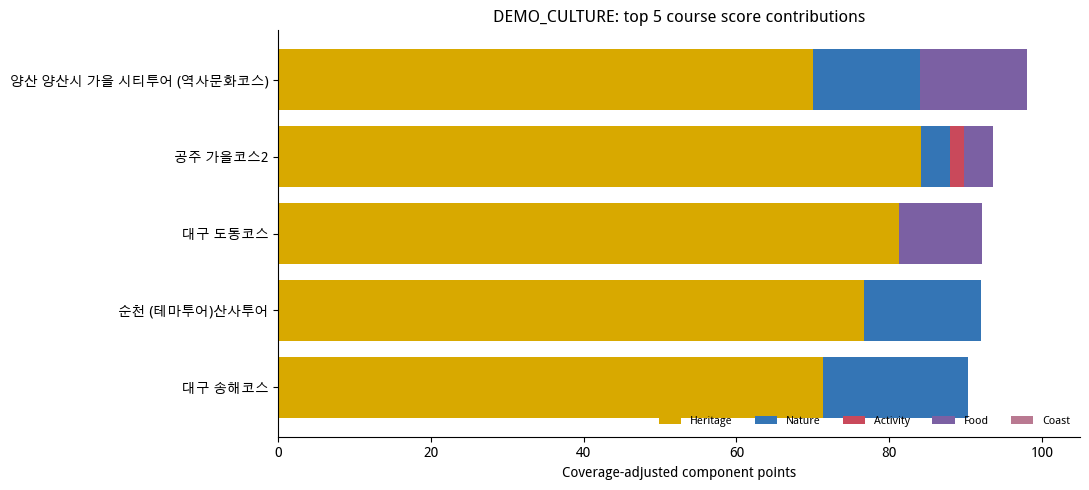

In [18]:
# Survey-to-course cosine score. This is a separate candidate-ranking component.
SURVEY_FIELDS = [f'q_{c}' for c in CATEGORIES]
SURVEY_QUESTIONS = [
    '역사 유적과 전통문화를 얼마나 즐기고 싶나요?',
    '숲과 자연경관에서 쉬는 여행을 얼마나 원하나요?',
    '체험과 활동 중심의 여행을 얼마나 원하나요?',
    '지역 음식과 미식 경험을 얼마나 원하나요?',
    '바다와 해변을 방문하고 싶은 정도는 어느 정도인가요?']
survey_dictionary=pd.DataFrame({'column':SURVEY_FIELDS,'question':SURVEY_QUESTIONS,
                               'allowed_values':'0,1,2,3,4,5','meaning':'0 관심 없음, 5 매우 관심 있음'})
save_csv(survey_dictionary,'cosine_survey_dictionary')

def rank_courses_cosine(response, courses, top_n=None):
    q=np.array([response[c] for c in SURVEY_FIELDS],float)
    if not np.isfinite(q).all() or (q<0).any() or (q>5).any() or not np.equal(q,np.floor(q)).all():
        raise ValueError('설문은 0~5의 정수 5개를 모두 입력해야 합니다.')
    if np.linalg.norm(q)<=1e-12:
        return pd.DataFrame(), 'NO_STATED_PREFERENCE'
    candidates=courses[courses.cluster_eligible].copy()
    desired=str(response.get('desired_region','')).strip()
    # Exact source region label only. No inferred proximity or ambiguous name merging.
    if desired:candidates=candidates[candidates.region.eq(desired)]
    if candidates.empty:return pd.DataFrame(),'NO_ELIGIBLE_COURSES_IN_REGION'
    shares=candidates[[f'share_{c}' for c in CATEGORIES]].to_numpy(float)
    norms=np.linalg.norm(shares,axis=1); valid=norms>1e-12
    candidates=candidates.loc[valid].copy();shares=shares[valid];norms=norms[valid]
    if candidates.empty:return pd.DataFrame(),'NO_CLASSIFIED_COURSES'
    contributions=(q/np.linalg.norm(q))[None,:]*(shares/norms[:,None])
    sim=contributions.sum(axis=1)
    coverage=shares.sum(axis=1)
    # Coverage is a conservative data-completeness adjustment, not calibrated probability.
    candidates['cosine_similarity']=np.clip(sim,0,1)
    candidates['cosine_fit_score']=100*candidates.cosine_similarity
    candidates['coverage_factor']=coverage
    candidates['coverage_adjusted_score']=100*candidates.cosine_similarity*coverage
    for j,c in enumerate(CATEGORIES):
        candidates[f'contribution_{c}_points']=100*contributions[:,j]*coverage
    if 'T' in COSINE_RESULTS:
        labels=COSINE_RESULTS['T']['assignments'].set_index('source_index').cosine_cluster
        candidates['cosine_cluster']=labels.reindex(candidates.index)
    else:candidates['cosine_cluster']=pd.NA
    candidates['respondent_id']=str(response['respondent_id'])
    candidates['data_status']=str(response.get('data_status','USER_INPUT'))
    candidates['operational_availability_verified']=False
    candidates=candidates.sort_values(['coverage_adjusted_score','cosine_similarity','category_coverage','course_id'],ascending=[False,False,False,True])
    # Equal component scores share a rank. course_id is only deterministic display order.
    candidates['score_rank']=candidates.coverage_adjusted_score.rank(method='min',ascending=False).astype(int)
    candidates['display_order']=np.arange(1,len(candidates)+1)
    keep=['respondent_id','data_status','score_rank','display_order','course_id','region','name','cosine_cluster',
          'cosine_similarity','cosine_fit_score','coverage_factor','coverage_adjusted_score',
          *[f'contribution_{c}_points' for c in CATEGORIES],'operational_availability_verified']
    result=candidates[keep]
    assert np.allclose(result[[f'contribution_{c}_points' for c in CATEGORIES]].sum(axis=1),result.coverage_adjusted_score)
    return result.head(top_n) if top_n else result, 'SCORED_CANDIDATES_NOT_BOOKING_CONFIRMATION'

survey_columns=['respondent_id',*SURVEY_FIELDS,'desired_region']
pd.DataFrame(columns=survey_columns).to_csv(RUN_DIR/'survey_responses_template.csv',index=False,encoding='utf-8-sig')
survey_results=[];survey_status=[]
if city is not None:
    if SURVEY_CSV is not None and Path(SURVEY_CSV).is_file():
        survey=read_csv_input(SURVEY_CSV,'survey')
        missing=set(survey_columns)-set(survey.columns)
        if missing:raise ValueError(f'설문 CSV 필수 열 누락: {sorted(missing)}')
        survey['data_status']='USER_INPUT'
        if survey.respondent_id.eq('').any() or survey.respondent_id.duplicated().any():raise ValueError('설문 respondent_id는 비어 있지 않은 고유값이어야 합니다.')
    else:
        survey=pd.DataFrame([
            ['DEMO_CULTURE',5,2,1,2,0,''],['DEMO_COAST',1,3,1,2,5,''],
            ['DEMO_ACTIVE',1,1,5,3,2,''],['DEMO_BALANCED',3,3,3,3,3,'']],columns=survey_columns)
        survey['data_status']='SYNTHETIC_DEMONSTRATION'
        print('실제 설문 CSV 없음: 명시적 가상 응답 4개로 계산 구조만 시연합니다.')
    save_csv(survey,'cosine_survey_inputs_used')
    for _,response in survey.iterrows():
        result,status=rank_courses_cosine(response,course_table)
        survey_status.append({'respondent_id':response.respondent_id,'data_status':response.data_status,'status':status,'n_candidates':len(result)})
        if len(result):survey_results.append(result)
    save_csv(pd.DataFrame(survey_status),'cosine_survey_status')
    if survey_results:
        rankings=pd.concat(survey_results,ignore_index=True);save_csv(rankings,'cosine_course_rankings_all')
        top_rankings=rankings[rankings.display_order.le(10)];save_csv(top_rankings,'cosine_course_rankings_top10');show_table(top_rankings,20)
        first=rankings[rankings.respondent_id.eq(rankings.respondent_id.iloc[0])].head(5).iloc[::-1]
        fig,ax=plt.subplots(figsize=(11,5));left=np.zeros(len(first))
        for j,c in enumerate(CATEGORIES):
            values=first[f'contribution_{c}_points'];ax.barh(np.arange(len(first)),values,left=left,label=CAT_LABELS[c],color=PALETTE[j]);left+=values.to_numpy()
        ax.set(yticks=np.arange(len(first)),yticklabels=[f'{r.region} {r["name"][:30]}' for _,r in first.iterrows()],
               xlabel='Coverage-adjusted component points',xlim=(0,105),title=f'{first.respondent_id.iloc[0]}: top 5 course score contributions')
        ax.legend(frameon=False,ncol=5,loc='lower right',fontsize=8);finish(fig,'C_survey_course_contributions')
        assert rankings.coverage_adjusted_score.between(0,100+1e-8).all()
    RUN_SUMMARY['cosine_survey']={'respondents':len(survey),'status_counts':{str(k):int(v) for k,v in survey.data_status.value_counts().items()},
                                'formula':'100 * cosine(q, course category shares) * category_coverage',
                                'production_score_replaced':False,'stay_formula_changed':False,
                                'operational_availability_verified':False}

# Meaningful edge-case and mathematical checks.
assert np.isclose(cosine_similarity([[10,20,10]],[[100,200,100]])[0,0],1)
u,valid,_=unit_rows([[0,0],[1,2]])
assert valid.tolist()==[False,True] and np.allclose(np.linalg.norm(u,axis=1),1)
toy=np.array([[1,.03],[1,-.02],[-1,.03],[-1,-.02]],float);toy/=np.linalg.norm(toy,axis=1)[:,None]
toyfit=spherical_kmeans(toy,2,42,5,100)
assert adjusted_rand_score([0,0,1,1],toyfit['labels'])==1
if city is not None:
    blank={'respondent_id':'ZERO',**dict.fromkeys(SURVEY_FIELDS,0),'desired_region':''}
    assert rank_courses_cosine(blank,course_table)[1]=='NO_STATED_PREFERENCE'
    invalid={**blank,'q_herit':6}
    try:rank_courses_cosine(invalid,course_table)
    except ValueError:pass
    else:raise AssertionError('잘못된 설문 값이 거부되지 않았습니다.')
print('코사인 수학·수렴·영벡터·설문 범위·기여도 합 검증 완료')


## 17 전체 출력 검사와 결과 목록
오류 없이 이 셀까지 실행되면 전체 처리가 완료됩니다. 학습에 제외된 행도 전체 결과 CSV에 남습니다. CSV를 바꾸면 매번 새로 학습하며 이전 군집 번호와 일치할 필요가 없습니다. 경유지 연결은 사람이 근거를 확인할 수 있도록 원문·후보·상태를 함께 저장합니다.

기본시간은 제공 CSV의 설계 값이며 군집화가 체류 공식의 정확도를 검증하지 않습니다. 코스 구성의 분류 규칙, 95% 기준, 가중치, 최소 군집 크기, 분류율 조건은 설정값입니다. 이를 변경한 뒤 결과의 안정성을 비교할 수 있습니다. 모델 파일은 직접 생성한 신뢰할 수 있는 파일만 불러오세요.


In [19]:
if places is not None:
    assert len(places)==len(places_raw)
    assert len(place_model["labels"])==int(places.cluster_eligible.sum())
    assert np.isfinite(place_model["pcs"].to_numpy()).all()
if city is not None:
    assert len(course_table)==len(cities_raw)
    assert course_table[[f"share_{c}" for c in CATEGORIES]].sum(axis=1).le(1+1e-10).all()
    assert stops.identity_verified.eq(False).all()
    if city_model is not None: assert len(city_model["labels"])==int(course_table.cluster_eligible.sum())
assert all(p.is_file() and p.stat().st_size>0 for p in PLOT_FILES)
summary={"method_version":"integrated-5.0", "created_at":datetime.now().isoformat(),"inputs":INPUT_META,
         "parameters":{"pca_target":PCA_TARGET,"k_max":K_MAX,"seeds":SEEDS,"n_init":N_INIT,"min_cluster_share":MIN_CLUSTER_SHARE,"min_seed_ari":MIN_SEED_ARI,"cosine_n_init":COSINE_N_INIT,"cosine_max_iter":COSINE_MAX_ITER},
         "models":RUN_SUMMARY,"versions":{"python":platform.python_version(),"numpy":np.__version__,"pandas":pd.__version__,"sklearn":sklearn.__version__,"matplotlib":matplotlib.__version__},
         "plot_count":len(PLOT_FILES),"verified_stop_links":0,
         "scope":"Baseline and spherical cosine clusters, survey-to-course candidate scoring, regional spending and marine context; no production deployment or validated satisfaction inference."}
(RUN_DIR/"run_summary.json").write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding="utf-8")
manifest=[]
for path in sorted(RUN_DIR.rglob("*")):
    if path.is_file():manifest.append({"file":str(path.relative_to(RUN_DIR)),"bytes":path.stat().st_size,"sha256":hashlib.sha256(path.read_bytes()).hexdigest()})
pd.DataFrame(manifest).to_csv(RUN_DIR/"file_manifest.csv",index=False,encoding="utf-8-sig")
print("완료:",RUN_DIR.resolve())
print("PNG",len(PLOT_FILES),"개 / CSV",len(list(TABLES.glob("*.csv"))),"개")
show_table(pd.DataFrame(manifest)[["file","bytes"]],100)


완료: /workspace/scratch/6640d64d17c6/deliverables/integrated_release/Tour_Navigator_Codebook/analysis/outputs_cosine/run_20260928_062724_468322
PNG 41 개 / CSV 92 개


file,bytes
marine_explanation_examples.json,6120
marine_summary.json,6265
models/G_pca_kmeans.joblib,13435
models/G_spherical_cosine.joblib,1964
models/T_pca_kmeans.joblib,4129
models/T_spherical_cosine.joblib,2018
models/spend_region_ridge.joblib,1943
plots/01_place_categories.png,79984
plots/02_G_pca_variance.png,106633
plots/03_G_model_comparison.png,166988


## 공식 문서와 실행 참고
- [scikit-learn PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html): 중심화된 입력에서 주성분 축과 설명분산을 계산합니다.
- [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html): 초기화 횟수와 시드를 명시했습니다.
- [Silhouette](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html): 본 노트북은 비교 모드 간 같은 원특성 거리에서 계산합니다.

CSV 구조가 다르면 2장 또는 5장 `mapping`의 허용 칼럼명을 수정하세요. 경로 오류는 `Path.cwd()`와 설정 파일 위치를 확인하세요. 한글 폰트가 없는 환경에서도 영문 축 라벨 그림은 출력됩니다. Windows는 맑은 고딕을 자동 사용합니다. 커널 시작 자체가 실패하면 Python/Jupyter 환경 문제이므로 노트북 코드를 실행하기 전에 정상 커널을 선택해야 합니다.

- [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)
- [GroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html)
- [전처리 누출 방지](https://scikit-learn.org/stable/common_pitfalls.html)
- [한국관광 데이터랩 소비 집계 변경 안내](https://datalab.visitkorea.or.kr/site/portal/ex/bbs/View.do?bcIdx=301002&cbIdx=1135): 업종별 집계 범위가 바뀔 수 있으므로 다운로드 필터를 함께 확인합니다. 이 공지가 이번 파일 간 차이의 원인이라고 단정하지 않습니다.

- [한국관광 데이터랩 해양관광 현황](https://datalab.visitkorea.or.kr/datalab/portal/theme/getMarineTourSearch.do): 연안 읍면동·연안 도시/어촌 구분, 방문자 평균과 Top5 설명. 확인일 2026-09-27.


### 코사인 확장 참고
- Hornik et al. (2012), Spherical k-Means Clustering, Journal of Statistical Software 50(10), https://doi.org/10.18637/jss.v050.i10
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

참고 논문의 구면 목적함수에 맞춘 독립적인 Python 구현입니다. 논문 패키지의 모든 알고리즘을 재현하거나 외부 패키지를 호출한 것으로 표시하지 않습니다.
